# 03_EDA：YouTube動画メタデータの探索的データ分析

このnotebookでは、前工程で作成した `data/processed/videos_labeled.csv` を使って、分類モデルを作る前にデータの特徴を確認する。

今回のEDAの目的は、単にグラフを作ることではなく、以下を確認することである。

* 学習データの件数とクラスバランス
* タイトル・概要欄・結合テキストの長さ
* 概要欄に含まれるURL・ドメインの傾向
* 概要欄に含まれるハッシュタグの傾向
* どのジャンルにも共通して出る定型的な情報
* 特定ジャンルに偏って出る分類に有用そうな情報
* チャンネル単位の偏り
* TF-IDF + ロジスティック回帰に進む前に注意すべき点

特に、URL・ドメイン・ハッシュタグは最初から単純にノイズとは決めつけない。

ジャンル分類に役立つものもあれば、どのジャンルにも共通して出る定型文のようなものもある。

そのため、このEDAでは以下のように分けて考える。

* 多くのジャンルに共通して出るハッシュタグ・ドメイン: 削除候補
* 特定ジャンルに偏って出るハッシュタグ・ドメイン: 分類に有用な特徴候補

まずはデータの傾向を確認し、その後の前処理や分類実験につなげる。


## 1. ライブラリ読み込み・パス設定

まず、EDAで使うライブラリを読み込み、プロジェクト内のファイルパスを設定する。

このnotebookでは、主に以下を使う。

* `pandas`: CSVの読み込み、集計、表形式データの確認
* `matplotlib`: 必要に応じたグラフ作成
* `pathlib.Path`: OSに依存しにくいファイルパスの扱い
* `re`: URLやハッシュタグを正規表現で抽出するために使う
* `urllib.parse`: URLからドメインを取り出すために使う

`PROJECT_ROOT` はプロジェクトのルートディレクトリを表す変数として使う。

In [1410]:
from pathlib import Path
import re
from urllib.parse import urlparse

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "videos_labeled.csv"
OUTPUTS_DIR = PROJECT_ROOT / "data" / "analysis" / "eda"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUTS_DIR:", OUTPUTS_DIR)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)

OUTPUTS_DIR: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda
PROJECT_ROOT: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc
DATA_PATH: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/processed/videos_labeled.csv


## 2. processed CSVの読み込み

前工程で作成した `data/processed/videos_labeled.csv` を読み込む。

このCSVには、学習対象となる4ジャンルの動画データが入っている。

対象ジャンルは以下である。

* music
* game
* study
* cooking

1行が1本のYouTube動画に対応している。

In [1411]:
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
display(df.head())

shape: (443, 24)


,video_id,url,genre,title,description,channel_id,channel_title,tags,category_id,duration,...,default_language,default_audio_language,fetched_at,text_base,text_title_weight_1,text_title_weight_2,text_title_weight_3,title_length,description_length,text_length
0,ktzbPzmAnnw,https://www.youtube.com/watch?v=ktzbPzmAnnw,music,「胎児の夢」 feat.初音ミク,"胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されているのは旧名です。\n\n【off ...",UCVJns279mOOd92lWVQl_HlA,水都,"[""#VOCALOID"", ""#初音ミク""]",10,PT3M33S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,"「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されてい...","「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されてい...","「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration...","「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Mo...",16,213,230
1,arlXG7TVdPk,https://www.youtube.com/watch?v=arlXG7TVdPk,music,天使じゃないよ/初音ミク,他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nbH4Oc...\n\nof...,UCF9BrkN5Z5tqAwuj_s0519g,越前,[],22,PT3M36S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nb...,天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nb...,天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize...,天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https:/...,12,171,184
2,DNltbDXaKw8,https://www.youtube.com/watch?v=DNltbDXaKw8,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https://twitter.com/@nantoka_SA)...,UCB7DcMLTrdCeCENzfZIfKLQ,まかろり,[],22,PT3M45S,...,ja,ja,2026-06-20T13:05:06.655004+00:00,きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https...,きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https...,きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaur...,きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https:/...,26,197,224
3,JqvE2fxm80U,https://www.youtube.com/watch?v=JqvE2fxm80U,music,夢憂鬱 / 初音ミク,VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\n\nVocal：₁₀...,UCwqj1NywsBPbd5QZvHf-yEg,ukaihi,[],22,PT3M28S,...,ja,en,2026-06-20T13:05:06.655004+00:00,夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\...,夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\...,夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu...,夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?...,10,309,320
4,Pmj5CGPaUQ8,https://www.youtube.com/watch?v=Pmj5CGPaUQ8,music,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made",▶Music れーしあ\nhttps://x.com/Re_siadesu\n\n▶Illustration 肥料\nhttps://x.com/fertilizerrrr_\n\n▶Movie 肥料 れーしあ\n\n▶Mast...,UC90a5GK8XetNIlNF0kPj7yA,れーしあ / Re_shia,"[""八月"", ""僕らの犯した間違いの答え合わせ"", ""ボカロ"", ""夏 ボカロ"", ""カゼヒキ"", ""れーしあ"", ""切ないボカロ"", ""UTAU""]",10,PT3M44S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made ▶Music れーしあ\nhttps://x.com/Re_siadesu\n\n▶Ill...","八月、僕らの犯した間違いの答え合わせ/ カゼヒキ 

## 3. データの基本情報を確認する

まず、読み込んだデータの基本情報を確認する。

ここでは以下を見る。

* 行数・列数
* 先頭数行
* 各列のデータ型
* 欠損値の有無
* `video_id` の重複の有無

この確認によって、EDAや機械学習に進む前に、データが想定通りの形になっているかを確認する。


In [1412]:
# 先頭5行を確認する
display(df.head())
# 列名を確認する
df.columns.tolist()
df.info()

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

print("重複 video_id 数:", df["video_id"].duplicated().sum())

,video_id,url,genre,title,description,channel_id,channel_title,tags,category_id,duration,...,default_language,default_audio_language,fetched_at,text_base,text_title_weight_1,text_title_weight_2,text_title_weight_3,title_length,description_length,text_length
0,ktzbPzmAnnw,https://www.youtube.com/watch?v=ktzbPzmAnnw,music,「胎児の夢」 feat.初音ミク,"胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されているのは旧名です。\n\n【off ...",UCVJns279mOOd92lWVQl_HlA,水都,"[""#VOCALOID"", ""#初音ミク""]",10,PT3M33S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,"「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されてい...","「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration：水都\n\n※動画に記載されてい...","「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Movie, illustration...","「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 「胎児の夢」 feat.初音ミク 胎児は母親の胎内にいる間、生物の進化という壮絶な悪夢を見ているっていう説があるらしいです。\n\nMusic, Lyric, Mo...",16,213,230
1,arlXG7TVdPk,https://www.youtube.com/watch?v=arlXG7TVdPk,music,天使じゃないよ/初音ミク,他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nbH4Oc...\n\nof...,UCF9BrkN5Z5tqAwuj_s0519g,越前,[],22,PT3M36S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nb...,天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize_nn?s=21&t=nb...,天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https://x.com/echize...,天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 天使じゃないよ/初音ミク 他人に理想を押し付けるのも、押し付けられるのも等しくグロテスクですよね\n\n歌：初音ミク\n\n他：えちぜん \nｘ(twitter)→ https:/...,12,171,184
2,DNltbDXaKw8,https://www.youtube.com/watch?v=DNltbDXaKw8,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https://twitter.com/@nantoka_SA)...,UCB7DcMLTrdCeCENzfZIfKLQ,まかろり,[],22,PT3M45S,...,ja,ja,2026-06-20T13:05:06.655004+00:00,きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https...,きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaurra)\n\n編曲映像：いのうつはSA\n(https...,きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https://twitter.com/@urayahayahaur...,きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) きおくをみたの/初音ミク(まかろり×いのうつはSA) 生きるって、何だろうね。\n\n作詞作曲：まかろり\n(https:/...,26,197,224
3,JqvE2fxm80U,https://www.youtube.com/watch?v=JqvE2fxm80U,music,夢憂鬱 / 初音ミク,VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\n\nVocal：₁₀...,UCwqj1NywsBPbd5QZvHf-yEg,ukaihi,[],22,PT3M28S,...,ja,en,2026-06-20T13:05:06.655004+00:00,夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\...,夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu6NK9qJv-\n\...,夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?si=b3V-OBqu...,夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク 夢憂鬱 / 初音ミク VocaDuo2024にて制作した曲の初音ミク歌唱verです。\n\n\n₁₀₄は₆番線さん 歌唱ver\nhttps://youtu.be/pMUoF9pEJwk?...,10,309,320
4,Pmj5CGPaUQ8,https://www.youtube.com/watch?v=Pmj5CGPaUQ8,music,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made",▶Music れーしあ\nhttps://x.com/Re_siadesu\n\n▶Illustration 肥料\nhttps://x.com/fertilizerrrr_\n\n▶Movie 肥料 れーしあ\n\n▶Mast...,UC90a5GK8XetNIlNF0kPj7yA,れーしあ / Re_shia,"[""八月"", ""僕らの犯した間違いの答え合わせ"", ""ボカロ"", ""夏 ボカロ"", ""カゼヒキ"", ""れーしあ"", ""切ないボカロ"", ""UTAU""]",10,PT3M44S,...,ja,NaN,2026-06-20T13:05:06.655004+00:00,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made ▶Music れーしあ\nhttps://x.com/Re_siadesu\n\n▶Ill...","八月、僕らの犯した間違いの答え合わせ/ カゼヒキ 

<class 'pandas.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                443 non-null    str    
 1   url                     443 non-null    str    
 2   genre                   443 non-null    str    
 3   title                   443 non-null    str    
 4   description             418 non-null    str    
 5   channel_id              443 non-null    str    
 6   channel_title           443 non-null    str    
 7   tags                    443 non-null    str    
 8   category_id             443 non-null    int64  
 9   duration                443 non-null    str    
 10  published_at            443 non-null    str    
 11  view_count              443 non-null    int64  
 12  like_count              428 non-null    float64
 13  comment_count           431 non-null    float64
 14  default_language        443 non-null    str    
 15  

In [1413]:
required_columns = [
    "video_id",
    "url",
    "genre",
    "title",
    "description",
    "channel_title",
    "tags",
    "text_base",
    "title_length",
    "description_length",
    "text_length",
]

missing_required_columns = [col for col in required_columns if col not in df.columns]

if missing_required_columns:
    print("不足している列:", missing_required_columns)
else:
    print("必要な列はすべて存在します")

必要な列はすべて存在します


## 4. ジャンル別件数とクラスバランスを確認する

次に、各ジャンルに何件の動画が含まれているかを確認する。

分類モデルを作る場合、特定のジャンルだけが極端に多い、または少ないと、評価結果が偏りやすくなる。

以下のような数値でクラスバランスを確認する。

* ジャンル数
* 総件数
* 最小件数
* 最大件数
* 最大件数と最小件数の差
* 最大件数と最小件数の比
* 平均件数
* 標準偏差
* 変動係数

これにより、学習データに極端なクラス不均衡がないかを確認する。

In [1414]:

genre_counts = df["genre"].value_counts()


genre_counts

genre
music      123
study      111
game       107
cooking    102
Name: count, dtype: int64

In [1415]:
genre_balance = pd.DataFrame({
    "count": genre_counts,
    "ratio_percent": (genre_counts / genre_counts.sum() * 100).round(2),
})

genre_balance

,count,ratio_percent
genre,,
music,123,27.77
study,111,25.06
game,107,24.15
cooking,102,23.02


In [1416]:
class_balance_summary = pd.Series({
    "n_genres": genre_counts.size,
    "total_count": genre_counts.sum(),
    "min_count": genre_counts.min(),
    "max_count": genre_counts.max(),
    "max_minus_min": genre_counts.max() - genre_counts.min(),
    "max_div_min": genre_counts.max() / genre_counts.min(),
    "mean_count": genre_counts.mean(),
    "std_count": genre_counts.std(ddof=0),
    "coefficient_of_variation": genre_counts.std(ddof=0) / genre_counts.mean(),
})

class_balance_summary.round(3)

n_genres                      4.000
total_count                 443.000
min_count                   102.000
max_count                   123.000
max_minus_min                21.000
max_div_min                   1.206
mean_count                  110.750
std_count                     7.758
coefficient_of_variation      0.070
dtype: float64

In [1417]:
expected_genres = {"music", "game", "study", "cooking"}
actual_genres = set(df["genre"].unique())

print("想定ジャンル:", expected_genres)
print("実際のジャンル:", actual_genres)

if actual_genres == expected_genres:
    print("想定通りです")
else:
    print("不足:", expected_genres - actual_genres)
    print("余分:", actual_genres - expected_genres)

想定ジャンル: {'cooking', 'study', 'music', 'game'}
実際のジャンル: {'cooking', 'study', 'music', 'game'}
想定通りです


### ここまでの確認結果

processed CSVを読み込み、データの基本情報を確認した。

確認した内容は以下である。

- 行数・列数
- 主要な列の有無
- 欠損値
- `video_id` の重複
- ジャンル別件数
- クラスバランス

ジャンル別件数については、棒グラフではなく、件数・割合・最大値と最小値の差・変動係数などの数値で確認した。

この段階で大きな問題がなければ、次にタイトル・概要欄・結合テキストの文字数確認へ進む。

## 5. タイトル・概要欄・結合テキストの長さを確認する

分類に使うテキストの長さを確認する。

ここでは、以下の列を見る。

* `title_length`: タイトルの文字数
* `description_length`: 概要欄の文字数
* `text_length`: タイトルと概要欄を結合したテキストの文字数

YouTubeの概要欄には、動画内容そのものだけでなく、SNSリンク、チャンネル登録案内、商品リンク、ハッシュタグ、定型文などが含まれることがある。

そのため、タイトル、概要欄、結合テキストの文字数分布をヒストグラムで確認する。

特に概要欄は、動画によって長さの差が大きくなりやすい。

ヒストグラムを見ることで、短い概要欄が多いのか、長い概要欄が一部だけ存在するのかを確認する。

In [1418]:
length_cols = ["title_length", "description_length", "text_length"]

df[length_cols].describe().round(1)

,title_length,description_length,text_length
count,443.0,443.0,443.0
mean,36.4,749.0,786.4
std,19.7,775.4,781.6
min,1.0,0.0,12.0
25%,22.0,192.5,223.5
50%,32.0,505.0,544.0
75%,47.0,1033.5,1078.0
max,98.0,4909.0,4966.0


In [1419]:
df[length_cols].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]).round(1)

,title_length,description_length,text_length
0.00,1.0,0.0,12.0
0.25,22.0,192.5,223.5
0.50,32.0,505.0,544.0
0.75,47.0,1033.5,1078.0
0.90,64.8,1869.4,1915.4
0.95,75.9,2222.9,2282.8
0.99,95.0,3475.8,3535.8
1.00,98.0,4909.0,4966.0


In [1420]:
length_summary = pd.DataFrame({
    "mean": df[length_cols].mean(),
    "median": df[length_cols].median(),
    "std": df[length_cols].std(),
    "min": df[length_cols].min(),
    "max": df[length_cols].max(),
})

length_summary.round(1)

,mean,median,std,min,max
title_length,36.4,32.0,19.7,1,98
description_length,749.0,505.0,775.4,0,4909
text_length,786.4,544.0,781.6,12,4966


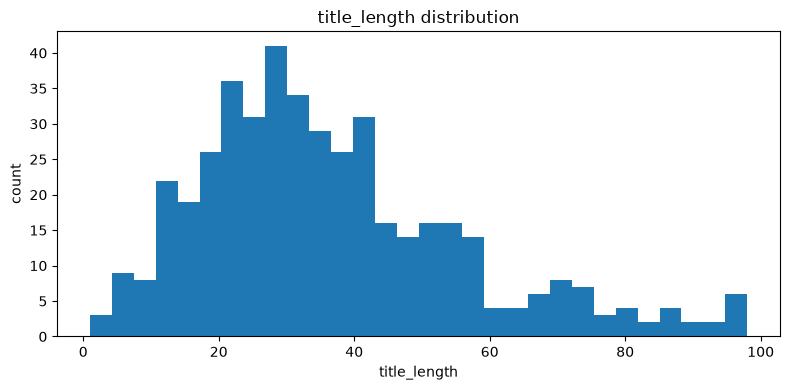

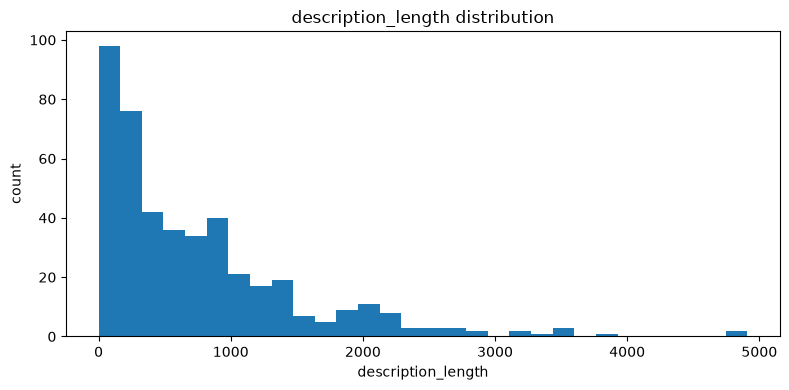

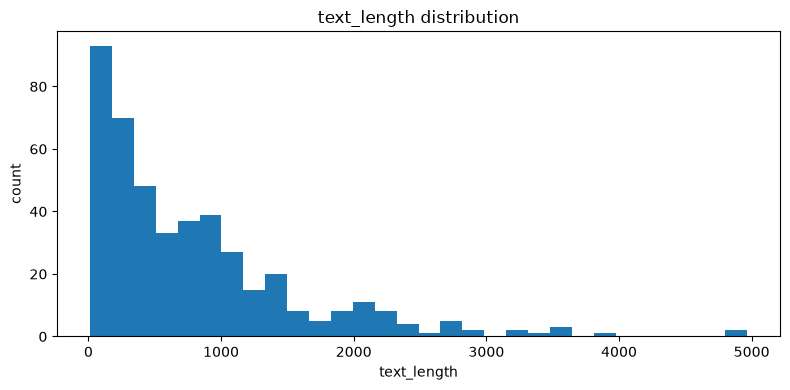

In [1421]:
for col in length_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

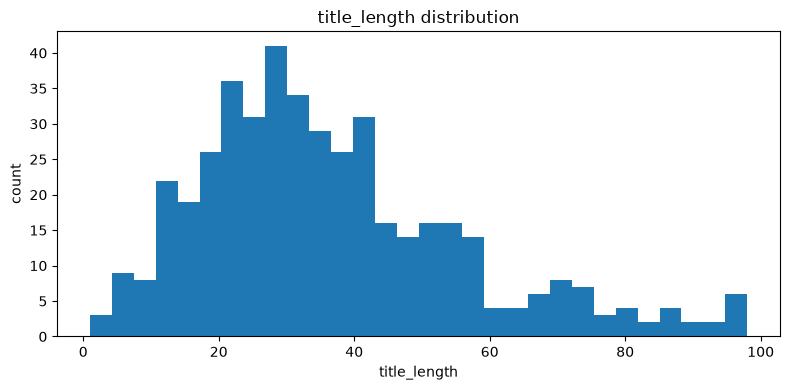

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/title_length_distribution.png


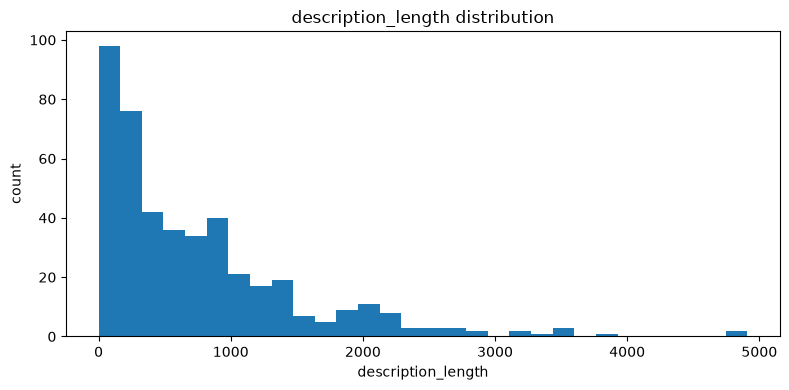

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/description_length_distribution.png


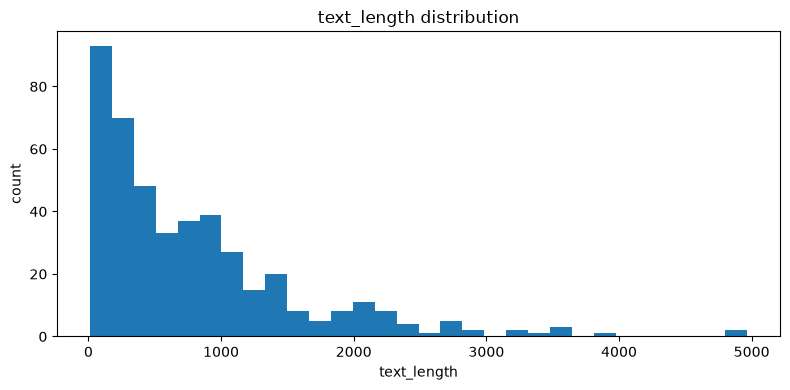

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/text_length_distribution.png


In [1422]:
for col in length_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()

    output_path = OUTPUTS_DIR / f"{col}_distribution.png"
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("saved:", output_path)

## 6. ジャンルごとの文字数傾向を確認する

次に、ジャンルごとにテキストの長さに違いがあるかを確認する。

例えば、料理動画では材料や手順が概要欄に書かれていて長くなりやすい可能性がある。

音楽動画では配信リンク、歌詞、クレジット情報などが含まれる可能性がある。

学習動画では教材リンクや補足説明が含まれる可能性がある。

ゲーム動画では配信者の定型文やSNSリンクが含まれる可能性がある。

ジャンルごとの文字数の違いは、後で分類結果や誤分類例を解釈するときの参考になる。

In [1423]:
genre_length_mean = df.groupby("genre")[length_cols].mean().round(1)

genre_length_mean

,title_length,description_length,text_length
genre,,,
cooking,40.8,977.6,1019.2
game,40.5,597.5,638.9
music,30.0,603.9,634.8
study,35.7,845.8,882.5


In [1424]:
genre_length_median = df.groupby("genre")[length_cols].median().round(1)

genre_length_median

,title_length,description_length,text_length
genre,,,
cooking,35.0,767.5,797.5
game,36.0,523.0,575.0
music,25.0,396.0,416.0
study,32.0,513.0,552.0


In [1425]:
genre_length_summary = df.groupby("genre")[length_cols].agg(
    ["mean", "median", "std", "min", "max"]
).round(1)

genre_length_summary

title_length                      description_length                \
                mean median   std min max               mean median    std   
genre                                                                        
cooking         40.8   35.0  20.0  12  98              977.6  767.5  921.0   
game            40.5   36.0  19.5   9  95              597.5  523.0  515.3   
music           30.0   25.0  18.7   1  79              603.9  396.0  637.2   
study           35.7   32.0  18.8   5  95              845.8  513.0  909.4   

                  text_length                          
        min   max        mean median    std min   max  
genre                                                  
cooking   0  3789      1019.2  797.5  927.3  12  3821  
game      0  2581       638.9  575.0  523.6  27  2669  
music     0  3213       634.8  416.0  645.2  20  3276  
study     0  4909       882.5  552.0  912.7  17  4966

In [1426]:
genre_description_quantile = df.groupby("genre")["description_length"].quantile(
    [0.5, 0.75, 0.9, 0.95, 1.0]
).unstack().round(1)

genre_description_quantile

,0.50,0.75,0.90,0.95,1.00
genre,,,,,
cooking,767.5,1463.2,2211.8,2653.4,3789.0
game,523.0,870.5,1274.6,1425.2,2581.0
music,396.0,896.0,1387.8,2012.8,3213.0
study,513.0,1104.5,1919.0,2542.5,4909.0


<Figure size 800x400 with 0 Axes>

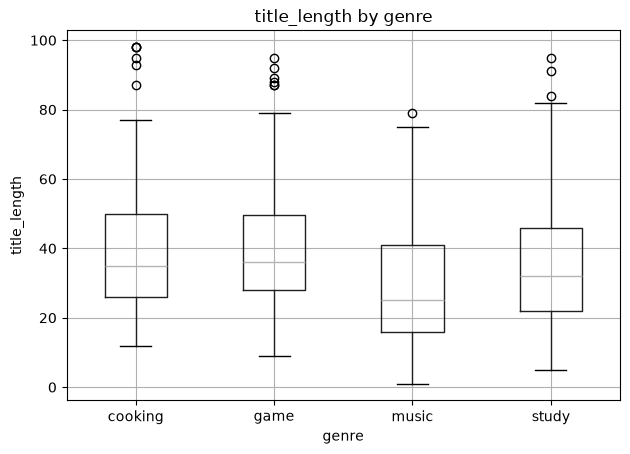

<Figure size 800x400 with 0 Axes>

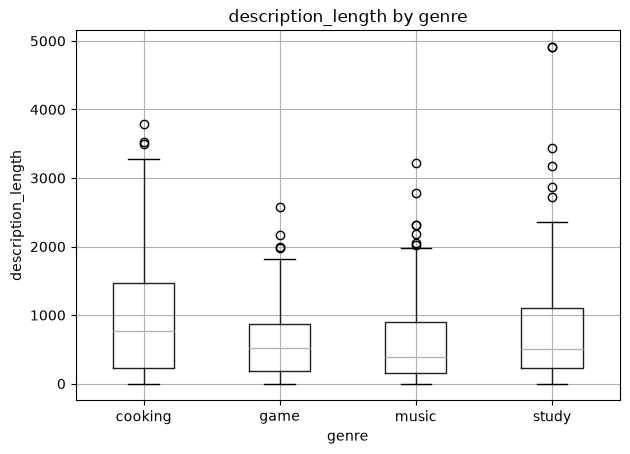

<Figure size 800x400 with 0 Axes>

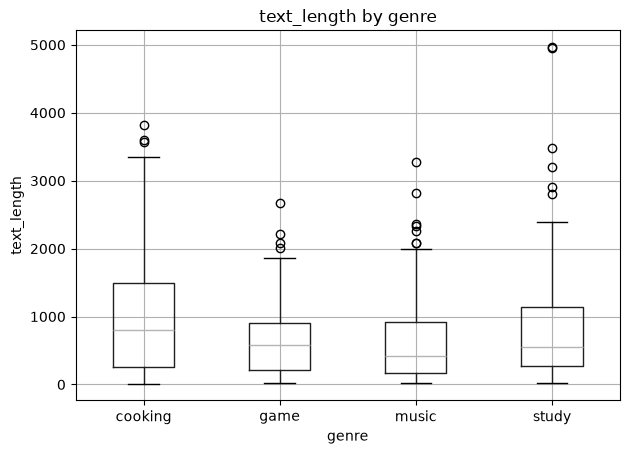

In [1427]:
for col in length_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col, by="genre")
    plt.title(f"{col} by genre")
    plt.suptitle("")
    plt.xlabel("genre")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

<Figure size 800x400 with 0 Axes>

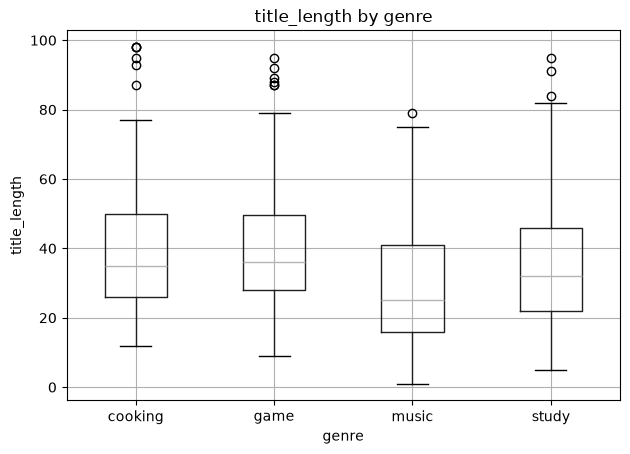

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/title_length_by_genre_boxplot.png


<Figure size 800x400 with 0 Axes>

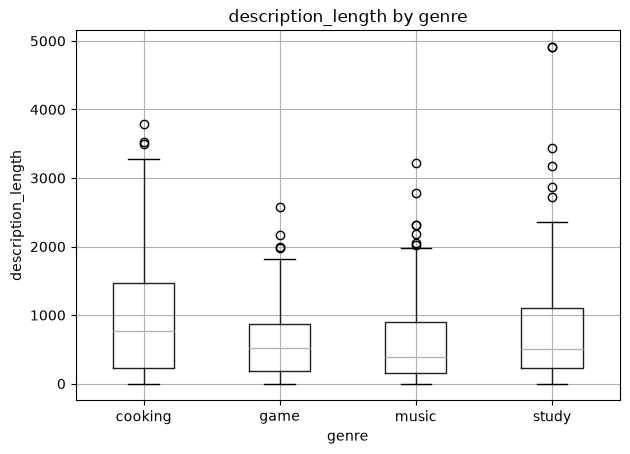

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/description_length_by_genre_boxplot.png


<Figure size 800x400 with 0 Axes>

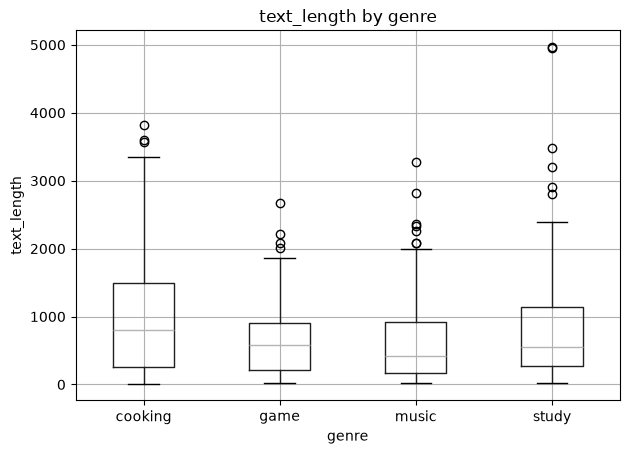

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/text_length_by_genre_boxplot.png


In [1428]:
for col in length_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col, by="genre")
    plt.title(f"{col} by genre")
    plt.suptitle("")
    plt.xlabel("genre")
    plt.ylabel(col)
    plt.tight_layout()

    output_path = OUTPUTS_DIR / f"{col}_by_genre_boxplot.png"
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("saved:", output_path)

## 7. 概要欄が極端に長い動画を確認する

概要欄が長い動画を実際に確認する。

数値だけでは、概要欄が長い理由までは分からない。

ここでは、文字数が長い動画を上から数件見て、以下を確認する。

* 動画内容の説明が長いのか
* SNSリンクが多いのか
* 商品リンクや配信リンクが多いのか
* ハッシュタグが多いのか
* チャンネルの定型文が多いのか
* 分類に役立つ情報が含まれているのか

この確認によって、概要欄をそのまま分類に使うべきか、後で一部を除去するべきかを考える材料にする。

In [1429]:
long_description_df = df.sort_values("description_length", ascending=False)

long_description_df[
    ["genre", "title", "channel_title", "description_length", "url"]
].head(10)

,genre,title,channel_title,description_length,url
292,study,【東京大学出版会 齋藤正彦 線型代数入門】第2章 §5-1 多元一次方程式系の解法、非同次系の一般論,MT 数学・数学史,4909,https://www.youtube.com/watch?v=FXDLNPqucxU
291,study,【東京大学出版会 齋藤正彦 線型代数入門】第一章 §4-4 平面の合同変換、平行移動、回転、鏡映、無限遠点と射影,MT 数学・数学史,4909,https://www.youtube.com/watch?v=EoUjby7EoWc
370,cooking,【最強の時短】冷凍ストック鍋！忙しい日々でも栄養満点の夕食を！,板前シンヤの絶品☆おうちごはん,3789,https://www.youtube.com/watch?v=M8Ga6IU_gWo
401,cooking,【フライドポテトを超える】スウェーデンが生んだ最高峰の芋料理『ハッセルバックポテト』,George ジョージ吉田,3531,https://www.youtube.com/watch?v=78oQWR-3qFE
422,cooking,３００万再生人気レシピ！【漬けるだけ】これが驚くほどウマすぎて市販や居酒屋じゃもう満足出来ない…と何度も言われた『超やべぇキュウリの1/2本漬け』ピリ辛／低糖質／おつまみ／作り置き／副菜／野菜漬け,こっタソの自由気ままに【Kottaso Recipe】,3501,https://www.youtube.com/watch?v=kwWH0Qlc_eg
331,study,【超初心者向け】Premiere ProでYouTubeの動画編集をする流れと方法,Mappy Photo,3441,https://www.youtube.com/watch?v=yoGbTe_rV_M
437,cooking,【鮎の串の打ち方】串の通り道を見える形で解説・鮎 塩焼きの失敗例と化粧塩・Japanese food👉#和食レシピ日本料理案内所,和食レシピ【日本料理案内所】,3277,https://www.youtube.com/watch?v=HDUiz6IesgQ
67,music,Lizzy McAlpine - erase me feat. Jacob Collier (official video),Lizzy McAlpine,3213,https://www.youtube.com/watch?v=YV9NrQvNEv4
261,study,The Continuity of Splines,Freya Holmér,3173,https://www.youtube.com/watch?v=jvPPXbo87ds
235,study,【計25冊】SF読むならまずはここから！ おすすめSF小説マッピング！【前編】,ずんだ文芸部【ざっくり小説紹介】,2866,https://www.youtube.com/watch?v=BfQxlVpnDr8


In [1430]:
long_description_preview = long_description_df[
    ["genre", "title", "channel_title", "description_length", "description"]
].head(10).copy()

long_description_preview["description_preview"] = (
    long_description_preview["description"]
    .fillna("")
    .str.replace("\n", " ", regex=False)
    .str[:500]
)

long_description_preview = long_description_preview.drop(columns="description")

display(long_description_preview)

,genre,title,channel_title,description_length,description_preview
292,study,【東京大学出版会 齋藤正彦 線型代数入門】第2章 §5-1 多元一次方程式系の解法、非同次系の一般論,MT 数学・数学史,4909,Contents: Thanks for watching. Please also go to the links below. チャンネル運営と動画制作を支援していただけると幸いです チャンネルメンバーシップはYouTube...
291,study,【東京大学出版会 齋藤正彦 線型代数入門】第一章 §4-4 平面の合同変換、平行移動、回転、鏡映、無限遠点と射影,MT 数学・数学史,4909,Contents: Thanks for watching. Please also go to the links below. チャンネル運営と動画制作を支援していただけると幸いです チャンネルメンバーシップはYouTube...
370,cooking,【最強の時短】冷凍ストック鍋！忙しい日々でも栄養満点の夕食を！,板前シンヤの絶品☆おうちごはん,3789,今回使用したおすすめの食材・調理器具を載せています。 ------------------- 絶品☆おうちごはん＜ポイント＞ ------------------- ①鍋野菜を冷凍してストックして置くことで、忙しい日でも出来立ての...
401,cooking,【フライドポテトを超える】スウェーデンが生んだ最高峰の芋料理『ハッセルバックポテト』,George ジョージ吉田,3531,北欧の国民食、ハッセルバックポテト。アコーディオンのような見た目が華やかで、パーティーのおもてなし料理や、クリスマスにもおすすめです。レストランでは、ステーキの付け合わせに作っていましたが、付け合わせの領域を超える美味しさ。 今回は...
422,cooking,３００万再生人気レシピ！【漬けるだけ】これが驚くほどウマすぎて市販や居酒屋じゃもう満足出来ない…と何度も言われた『超やべぇキュウリの1/2本漬け』ピリ辛／低糖質／おつまみ／作り置き／副菜／野菜漬け,こっタソの自由気ままに【Kottaso Recipe】,3501,◆こっタソ動物園チャンネル 新しいチャンネルです！こちらもおヒマな時にどぞ。 ⇒https://www.youtube.com/c/こっタソ動物園-kottasoanimals ご視聴ありがとうございます。 Thank you f...
331,study,【超初心者向け】Premiere ProでYouTubeの動画編集をする流れと方法,Mappy Photo,3441,Adobe Premiere Pro（アドビプレミアプロ）を使ってYouTubeの動画編集をする流れと方法を解説しました。 初めてPremiere Proを使う方がざっくりでもとりあえず動画を作ることができるようになることを目的と...
437,cooking,【鮎の串の打ち方】串の通り道を見える形で解説・鮎 塩焼きの失敗例と化粧塩・Japanese food👉#和食レシピ日本料理案内所,和食レシピ【日本料理案内所】,3277,【鮎の串打ち方法・鮎の串の刺し方の基本】金串が鮎の内部のどこを通って、どこから出るのかを身が無い状態で見えるように解説しております。 ※ 生きている鮎としめた鮎では金串の打ち方を鮮度によって変化させ、腹が破裂しないよう調節してくださ...
67,music,Lizzy McAlpine - erase me feat. Jacob Collier (official video),Lizzy McAlpine,3213,"‘Older’, the new album from Lizzy McAlpine, is out now. Listen here: https://LizzyMcAlpine.lnk.to/OlderAlbum Liste..."
261,study,The Continuity of Splines,Freya Holmér,3173,"why are splines? well my god I have good news for you, here's why splines! if you like my work, please consider sup..."
235,study,【計25冊】SF読むならまずはここから！ おすすめSF小説マッピング！【前編】,ずんだ文芸部【ざっくり小説紹介】,2866,最近話題の「プロジェクトヘイルメアリー」「三体」を始めとした、これ読んどけば間違いない！というおすすめのSF小説をギュッと詰め込みました！ 「SFって難しそう……」という初心者からSF玄人まで幅広い方にとって有益な情報となるよう、...


In [1431]:
for _, row in long_description_df.head(5).iterrows():
    print("=" * 80)
    print("genre:", row["genre"])
    print("title:", row["title"])
    print("channel:", row["channel_title"])
    print("description_length:", row["description_length"])
    print("url:", row["url"])
    print()
    print(str(row["description"])[:1000])
    print()

genre: study
title: 【東京大学出版会 齋藤正彦 線型代数入門】第2章 §5-1 多元一次方程式系の解法、非同次系の一般論
channel: MT 数学・数学史
description_length: 4909
url: https://www.youtube.com/watch?v=FXDLNPqucxU

Contents: Thanks for watching. Please also go to the links below.

チャンネル運営と動画制作を支援していただけると幸いです

チャンネルメンバーシップはYouTubeのチャンネルページから
https://youtube.com/channel/UCA7LZAC55oFU74PnYohV0Tg

クラウドファンディング＆支援コミュニティlink
https://community.camp-fire.jp/projects/view/273185

欲しいものリスト：https://www.amazon.co.jp/hz/wishlist/ls/2UVYOZW56CP47?&sort=price-asc

Twitter link: https://twitter.com/maths_mt?lang=en

Insta link: https://www.instagram.com/mt_mathschannel/

数学史のNoteへのリンク
https://note.com/maths_mt

オンラインや個別指導、仕事などの相談は此方から: 
maths.toshi@gmail.com
-----------------------------------------------------------------

[[リンク集 links]]

オイラーの公式 Euler’s formula 
[27] https://youtu.be/9VC1v1Vwojg
[323] https://youtu.be/5VBxhA8ROzc

フェルマーの小定理プレイリスト Playlist of Fermat’s little theorem.
https://www.youtube.com/playlist?list=PLlA6jgaa1nvgFSD5X50Gb6oYhcQQ

### 文字数確認のまとめ

タイトル・概要欄・結合テキストの文字数を確認した。

特に `description_length` は、動画によって大きく差が出やすい。

概要欄が長い動画については、実際の中身を確認し、以下のどれが多いかを見る。

- 動画内容の説明
- SNSリンク
- 商品リンク
- 配信リンク
- ハッシュタグ
- チャンネルの定型文

この確認結果は、後でURL、ドメイン、ハッシュタグを抽出するときの前提になる。

## 8. URLとドメインを抽出する

概要欄に含まれるURLを抽出し、URLからドメインを取り出す。

URLそのものは非常に種類が多く、そのままでは扱いづらい。

そのため、ここではURL全体ではなく、以下のようなドメイン単位で集計する。

* `youtube.com`
* `youtu.be`
* `twitter.com`
* `x.com`
* `instagram.com`
* `spotify.com`
* `amazon.co.jp`
* `github.com`
* `note.com`

ドメインを見ることで、ジャンルごとの概要欄の使われ方を確認できる。

例えば、音楽動画では配信サービスのリンクが多く、学習動画では教材やGitHubのリンクが多い、といった傾向が見える可能性がある。

In [1432]:
url_pattern = re.compile(r"https?://[^\s<>\"]+|www\.[^\s<>\"]+")

def extract_urls(text):
    if pd.isna(text):
        return []
    urls = url_pattern.findall(str(text))
    return [url.strip(".,、。)）]］}」』'\"") for url in urls]

def extract_domain(url):
    url = str(url)
    if url.startswith("www."):
        url = "https://" + url

    parsed = urlparse(url)
    domain = parsed.netloc.lower()

    if domain.startswith("www."):
        domain = domain[4:]

    return domain

In [1433]:
df["urls"] = df["description"].apply(extract_urls)
df["url_count"] = df["urls"].apply(len)
df["has_url"] = df["url_count"] > 0

df[["genre", "title", "url_count", "has_url"]].head()

,genre,title,url_count,has_url
0,music,「胎児の夢」 feat.初音ミク,2,True
1,music,天使じゃないよ/初音ミク,2,True
2,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),4,True
3,music,夢憂鬱 / 初音ミク,6,True
4,music,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made",4,True


In [1434]:
url_rows = []

for _, row in df.iterrows():
    for url in row["urls"]:
        domain = extract_domain(url)
        if domain:
            url_rows.append({
                "video_id": row["video_id"],
                "genre": row["genre"],
                "title": row["title"],
                "url": url,
                "domain": domain,
            })

url_df = pd.DataFrame(url_rows)

print("URL出現数:", len(url_df))
print("ユニークドメイン数:", url_df["domain"].nunique() if len(url_df) > 0 else 0)

url_df.head()

URL出現数: 2732
ユニークドメイン数: 419


,video_id,genre,title,url,domain
0,ktzbPzmAnnw,music,「胎児の夢」 feat.初音ミク,https://piapro.jp/t/F5n3,piapro.jp
1,ktzbPzmAnnw,music,「胎児の夢」 feat.初音ミク,https://www.nicovideo.jp/my/mylist/68190832?ref=pc_mypage_mylist,nicovideo.jp
2,arlXG7TVdPk,music,天使じゃないよ/初音ミク,https://x.com/echize_nn?s=21&t=nbH4Oc,x.com
3,arlXG7TVdPk,music,天使じゃないよ/初音ミク,https://piapro.jp/t/gHN8,piapro.jp
4,DNltbDXaKw8,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),https://twitter.com/@urayahayahaurra,twitter.com


In [1435]:
url_rate_by_genre = df.groupby("genre").agg(
    video_count=("video_id", "count"),
    videos_with_url=("has_url", "sum"),
    mean_url_count=("url_count", "mean"),
    max_url_count=("url_count", "max"),
)

url_rate_by_genre["url_video_rate"] = (
    url_rate_by_genre["videos_with_url"] / url_rate_by_genre["video_count"] * 100
).round(2)

url_rate_by_genre.round(2)

,video_count,videos_with_url,mean_url_count,max_url_count,url_video_rate
genre,,,,,
cooking,102,71,7.76,58,69.61
game,107,89,6.44,32,83.18
music,123,81,3.51,24,65.85
study,111,94,7.38,70,84.68


## 9. ジャンル別の頻出ドメインを確認する

抽出したドメインを、ジャンルごとに集計する。

ここでは、以下の2種類のドメインに注目する。

1. 多くのジャンルに共通して出るドメイン
2. 特定ジャンルに偏って出るドメイン

多くのジャンルに共通して出るドメインは、分類にはあまり役立たない可能性がある。

例えば、どのジャンルにも `youtube.com` や `twitter.com` が多く出てくる場合、それらはジャンル固有の特徴ではなく、YouTube概要欄の定型的な情報と考えられる。

一方で、特定ジャンルに偏って出るドメインは、分類に役立つ可能性がある。

この段階では削除するかどうかを決めきらず、まずは共通ドメインとジャンル固有ドメインを分けて確認する。

In [1436]:
domain_occurrence_counts = (
    url_df
    .groupby(["genre", "domain"])
    .size()
    .reset_index(name="url_occurrence_count")
    .sort_values(["genre", "url_occurrence_count"], ascending=[True, False])
)

domain_occurrence_counts.head(20)

,genre,domain,url_occurrence_count
6,cooking,amzn.to,164
87,cooking,youtube.com,124
86,cooking,youtu.be,99
32,cooking,instagram.com,53
2,cooking,amazon.co.jp,44
80,cooking,twitter.com,42
5,cooking,amzn.asia,21
4,cooking,amzlink.to,13
22,cooking,dova-s.jp,13
24,cooking,facebook.com,13


In [1437]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        domain_occurrence_counts[domain_occurrence_counts["genre"] == genre]
        .head(15)
    )

cooking


,genre,domain,url_occurrence_count
6,cooking,amzn.to,164
87,cooking,youtube.com,124
86,cooking,youtu.be,99
32,cooking,instagram.com,53
2,cooking,amazon.co.jp,44
80,cooking,twitter.com,42
5,cooking,amzn.asia,21
4,cooking,amzlink.to,13
22,cooking,dova-s.jp,13
24,cooking,facebook.com,13


game


,genre,domain,url_occurrence_count
203,game,youtube.com,193
194,game,twitter.com,104
202,game,youtu.be,103
190,game,t.co,23
193,game,twitch.tv,18
186,game,store.line.me,12
97,game,bit.ly,8
188,game,store.steampowered.com,8
201,game,x.com,8
98,game,ch.nicovideo.jp,6


music


,genre,domain,url_occurrence_count
321,music,twitter.com,78
327,music,x.com,48
331,music,youtube.com,32
330,music,youtu.be,29
251,music,instagram.com,20
259,music,linkco.re,13
282,music,nex-tone.link,11
316,music,tiktok.com,8
241,music,facebook.com,7
293,music,piapro.jp,6


study


,genre,domain,url_occurrence_count
499,study,youtu.be,244
500,study,youtube.com,119
340,study,amzn.to,46
485,study,twitter.com,46
395,study,instagram.com,20
385,study,github.com,19
335,study,a.r10.to,13
388,study,goo.gle,10
495,study,x.com,10
381,study,facebook.com,9


In [1438]:
video_domain_df = url_df.drop_duplicates(["video_id", "genre", "domain"])

domain_video_counts = (
    video_domain_df
    .groupby(["genre", "domain"])
    .size()
    .reset_index(name="video_count")
    .sort_values(["genre", "video_count"], ascending=[True, False])
)

domain_video_counts.head(20)

,genre,domain,video_count
32,cooking,instagram.com,45
87,cooking,youtube.com,42
80,cooking,twitter.com,41
6,cooking,amzn.to,20
86,cooking,youtu.be,19
2,cooking,amazon.co.jp,18
24,cooking,facebook.com,12
22,cooking,dova-s.jp,11
79,cooking,tiktok.com,11
62,cooking,pinterest.jp,7


In [1439]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        domain_video_counts[domain_video_counts["genre"] == genre]
        .head(15)
    )

cooking


,genre,domain,video_count
32,cooking,instagram.com,45
87,cooking,youtube.com,42
80,cooking,twitter.com,41
6,cooking,amzn.to,20
86,cooking,youtu.be,19
2,cooking,amazon.co.jp,18
24,cooking,facebook.com,12
22,cooking,dova-s.jp,11
79,cooking,tiktok.com,11
62,cooking,pinterest.jp,7


game


,genre,domain,video_count
203,game,youtube.com,59
194,game,twitter.com,52
202,game,youtu.be,29
193,game,twitch.tv,15
188,game,store.steampowered.com,8
201,game,x.com,8
98,game,ch.nicovideo.jp,6
104,game,discord.gg,6
107,game,dova-s.jp,6
126,game,instagram.com,5


music


,genre,domain,video_count
321,music,twitter.com,36
331,music,youtube.com,21
327,music,x.com,18
251,music,instagram.com,17
330,music,youtu.be,15
259,music,linkco.re,13
316,music,tiktok.com,8
241,music,facebook.com,7
293,music,piapro.jp,6
308,music,soundcloud.com,6


study


,genre,domain,video_count
500,study,youtube.com,52
485,study,twitter.com,38
499,study,youtu.be,34
395,study,instagram.com,16
340,study,amzn.to,15
385,study,github.com,11
495,study,x.com,9
442,study,open.spotify.com,8
381,study,facebook.com,7
437,study,note.com,7


## 10. 共通ドメインを削除候補として整理する

ジャンル別のドメイン集計をもとに、どのジャンルにも共通して出てくるドメインを削除候補として整理する。

ここでは、例えば以下のような条件を考える。

* 3ジャンル以上に出現している
* 出現回数が一定以上ある
* 特定ジャンルへの偏りが小さい
* YouTubeやSNSなど、動画内容より投稿者の定型情報を表していそうである

このようなドメインは、分類モデルがジャンルではなく概要欄テンプレートを学習してしまう原因になる可能性がある。

そのため、後の前処理で削除する候補として記録しておく。

In [1440]:
domain_genre_pivot = (
    video_domain_df
    .groupby(["domain", "genre"])
    .size()
    .unstack(fill_value=0)
)

domain_genre_pivot["total_video_count"] = domain_genre_pivot.sum(axis=1)
domain_genre_pivot["n_genres"] = (domain_genre_pivot.drop(columns="total_video_count") > 0).sum(axis=1)
domain_genre_pivot["max_genre_count"] = domain_genre_pivot.drop(
    columns=["total_video_count", "n_genres"]
).max(axis=1)
domain_genre_pivot["max_genre_ratio"] = (
    domain_genre_pivot["max_genre_count"] / domain_genre_pivot["total_video_count"]
)

domain_genre_summary = (
    domain_genre_pivot
    .sort_values(["n_genres", "total_video_count"], ascending=False)
)

domain_genre_summary.head(30)

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
youtube.com,42,59,21,52,174,4,59,0.339080
twitter.com,41,52,36,38,167,4,52,0.311377
youtu.be,19,29,15,34,97,4,34,0.350515
instagram.com,45,5,17,16,83,4,45,0.542169
amzn.to,20,2,1,15,38,4,20,0.526316
facebook.com,12,1,7,7,27,4,12,0.444444
amazon.co.jp,18,1,2,5,26,4,18,0.692308
tiktok.com,11,3,8,3,25,4,11,0.440000
bit.ly,6,4,2,6,18,4,6,0.333333


In [1441]:
common_domain_candidates = domain_genre_summary[
    (domain_genre_summary["n_genres"] >= 3)
    & (domain_genre_summary["total_video_count"] >= 5)
    & (domain_genre_summary["max_genre_ratio"] <= 0.7)
].copy()

common_domain_candidates

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
youtube.com,42,59,21,52,174,4,59,0.339080
twitter.com,41,52,36,38,167,4,52,0.311377
youtu.be,19,29,15,34,97,4,34,0.350515
instagram.com,45,5,17,16,83,4,45,0.542169
amzn.to,20,2,1,15,38,4,20,0.526316
facebook.com,12,1,7,7,27,4,12,0.444444
amazon.co.jp,18,1,2,5,26,4,18,0.692308
tiktok.com,11,3,8,3,25,4,11,0.440000
bit.ly,6,4,2,6,18,4,6,0.333333


In [1442]:
genre_specific_domain_candidates = domain_genre_summary[
    (domain_genre_summary["total_video_count"] >= 3)
    & (domain_genre_summary["max_genre_ratio"] >= 0.8)
].copy()

genre_specific_domain_candidates.head(30)

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
twitch.tv,0,15,0,1,16,2,15,0.937500
linkco.re,1,0,13,0,14,2,13,0.928571
github.com,0,1,0,11,12,2,11,0.916667
store.steampowered.com,0,8,0,1,9,2,8,0.888889
vt.tiktok.com,6,1,0,0,7,2,6,0.857143
forms.gle,0,1,0,5,6,2,5,0.833333
maoudamashii.jokersounds.com,1,5,0,0,6,2,5,0.833333
a.r10.to,4,0,0,1,5,2,4,0.800000
pinterest.jp,7,0,0,0,7,1,7,1.000000


In [1443]:
common_domains = common_domain_candidates.index.tolist()

common_domains

['youtube.com',
 'twitter.com',
 'youtu.be',
 'instagram.com',
 'amzn.to',
 'facebook.com',
 'amazon.co.jp',
 'tiktok.com',
 'bit.ly',
 'goo.gl',
 'note.com',
 'x.com',
 'dova-s.jp',
 'soundeffect-lab.info',
 'musmus.main.jp',
 'line.me',
 'nicovideo.jp',
 'otologic.jp',
 'amzn.asia',
 'mobile.twitter.com']

In [1444]:
domain_candidate_summary = pd.DataFrame({
    "common_domain_candidates": pd.Series(common_domains),
})

domain_candidate_summary

,common_domain_candidates
0,youtube.com
1,twitter.com
2,youtu.be
3,instagram.com
4,amzn.to
5,facebook.com
6,amazon.co.jp
7,tiktok.com
8,bit.ly
9,goo.gl


### ドメイン確認のまとめ

概要欄からURLを抽出し、URLからドメインを取り出した。

ドメインについては、単純なURL出現回数だけでなく、同じ動画内で同じドメインが複数回出た場合を1回として数える `video_count` も確認した。

今回の方針では、以下のように扱う。

- 多くのジャンルに共通して出るドメイン: 削除候補
- 特定ジャンルに偏って出るドメイン: 分類に有用な特徴候補

共通ドメインの候補は、後の前処理で削除対象として検討する。

ただし、この段階ではまだ削除は行わず、まずは候補として記録する。

## 11. ハッシュタグを抽出する

概要欄に含まれるハッシュタグを抽出する。

ハッシュタグは、単純なノイズとは限らない。

例えば、以下のようなハッシュタグはジャンル分類に役立つ可能性がある。

* `#歌ってみた`
* `#cover`
* `#ゲーム実況`
* `#レシピ`
* `#料理`
* `#数学`
* `#Python`
* `#勉強`

一方で、以下のようなハッシュタグはジャンルに関係なく出る可能性がある。

* `#shorts`
* `#youtube`
* `#おすすめ`

そのため、ハッシュタグは削除対象として一括で扱うのではなく、ジャンル別の出現傾向を確認する。

In [1445]:
hashtag_pattern = re.compile(r"(?<![A-Za-z0-9_/])#([^\s#]+)")

def normalize_hashtag(tag):
    tag = str(tag).strip()
    tag = tag.strip(".,、。!！?？:：;；)）]］}」』'\"")
    return "#" + tag.lower()

def extract_hashtags(text):
    if pd.isna(text):
        return []

    tags = hashtag_pattern.findall(str(text))
    return [normalize_hashtag(tag) for tag in tags if tag.strip()]

In [1446]:
df["hashtag_source_text"] = (
    df["title"].fillna("") + "\n" + df["description"].fillna("")
)

df["hashtags"] = df["hashtag_source_text"].apply(extract_hashtags)
df["hashtag_count"] = df["hashtags"].apply(len)
df["has_hashtag"] = df["hashtag_count"] > 0

df[["genre", "title", "hashtag_count", "has_hashtag"]].head()

,genre,title,hashtag_count,has_hashtag
0,music,「胎児の夢」 feat.初音ミク,0,False
1,music,天使じゃないよ/初音ミク,4,True
2,music,きおくをみたの/初音ミク(まかろり×いのうつはSA),0,False
3,music,夢憂鬱 / 初音ミク,1,True
4,music,"八月、僕らの犯した間違いの答え合わせ/ カゼヒキ - August, the answer to the mistakes we made",3,True


In [1447]:
hashtag_rows = []

for _, row in df.iterrows():
    for hashtag in row["hashtags"]:
        hashtag_rows.append({
            "video_id": row["video_id"],
            "genre": row["genre"],
            "title": row["title"],
            "hashtag": hashtag,
        })

hashtag_df = pd.DataFrame(hashtag_rows)

print("ハッシュタグ出現数:", len(hashtag_df))
print("ユニークハッシュタグ数:", hashtag_df["hashtag"].nunique() if len(hashtag_df) > 0 else 0)

hashtag_df.head()

ハッシュタグ出現数: 1053
ユニークハッシュタグ数: 829


,video_id,genre,title,hashtag
0,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#vocaloid
1,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#初音ミク
2,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#ボカロ
3,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#オリジナル曲
4,JqvE2fxm80U,music,夢憂鬱 / 初音ミク,#vocaduo2024vv


In [1448]:
hashtag_rate_by_genre = df.groupby("genre").agg(
    video_count=("video_id", "count"),
    videos_with_hashtag=("has_hashtag", "sum"),
    mean_hashtag_count=("hashtag_count", "mean"),
    max_hashtag_count=("hashtag_count", "max"),
)

hashtag_rate_by_genre["hashtag_video_rate"] = (
    hashtag_rate_by_genre["videos_with_hashtag"] / hashtag_rate_by_genre["video_count"] * 100
).round(2)

hashtag_rate_by_genre.round(2)

,video_count,videos_with_hashtag,mean_hashtag_count,max_hashtag_count,hashtag_video_rate
genre,,,,,
cooking,102,70,3.98,61,68.63
game,107,59,1.76,15,55.14
music,123,37,1.78,38,30.08
study,111,54,2.16,17,48.65


## 12. ジャンル別の頻出ハッシュタグを確認する

抽出したハッシュタグを、ジャンルごとに集計する。

ここでは、以下の2種類のハッシュタグに注目する。

1. 多くのジャンルに共通して出るハッシュタグ
2. 特定ジャンルに偏って出るハッシュタグ

特定ジャンルに偏って出るハッシュタグは、分類に役立つ特徴である可能性が高い。

一方で、どのジャンルにも出るハッシュタグは、ジャンル分類にはあまり役立たない可能性がある。

この確認によって、残すべきハッシュタグと、削除候補にするハッシュタグを分けるための材料にする。

In [1449]:
hashtag_occurrence_counts = (
    hashtag_df
    .groupby(["genre", "hashtag"])
    .size()
    .reset_index(name="hashtag_occurrence_count")
    .sort_values(["genre", "hashtag_occurrence_count"], ascending=[True, False])
)

hashtag_occurrence_counts.head(20)

,genre,hashtag,hashtag_occurrence_count
35,cooking,#shorts,33
240,cooking,#簡単レシピ,14
196,cooking,#料理,10
169,cooking,#作り置き,6
241,cooking,#簡単料理,5
155,cooking,#リュウジ,4
205,cooking,#時短レシピ,4
33,cooking,#short,3
42,cooking,#おうちごはん,3
53,cooking,#かんたんレシピ,3


In [1450]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        hashtag_occurrence_counts[hashtag_occurrence_counts["genre"] == genre]
        .head(20)
    )

cooking


,genre,hashtag,hashtag_occurrence_count
35,cooking,#shorts,33
240,cooking,#簡単レシピ,14
196,cooking,#料理,10
169,cooking,#作り置き,6
241,cooking,#簡単料理,5
155,cooking,#リュウジ,4
205,cooking,#時短レシピ,4
33,cooking,#short,3
42,cooking,#おうちごはん,3
53,cooking,#かんたんレシピ,3


game


,genre,hashtag,hashtag_occurrence_count
336,game,#あらなみマイクラ,5
294,game,#1,4
325,game,#rta,3
358,game,#ゆっくり実況,3
365,game,#ゲーム,3
399,game,#マイクラ,3
403,game,#マインクラフト,3
437,game,#裏技,3
318,game,#kun,2
319,game,#minecraft,2


music


,genre,hashtag,hashtag_occurrence_count
532,music,#vocaloid,5
529,music,#utau,3
588,music,#初音ミク,3
616,music,#歌ってみた,3
479,music,#hatsunemiku,2
491,music,#jpop,2
545,music,#エモい,2
546,music,#エモい曲,2
549,music,#オリジナル曲,2
584,music,#人工言語,2


study


,genre,hashtag,hashtag_occurrence_count
699,study,#toeic,5
767,study,#大学受験,5
702,study,#toeic対策,4
660,study,#ai,3
762,study,#地理,3
787,study,#数学,3
789,study,#日本史,3
668,study,#dtm,2
674,study,#g検定,2
675,study,#html,2


In [1451]:
video_hashtag_df = hashtag_df.drop_duplicates(["video_id", "genre", "hashtag"])

hashtag_video_counts = (
    video_hashtag_df
    .groupby(["genre", "hashtag"])
    .size()
    .reset_index(name="video_count")
    .sort_values(["genre", "video_count"], ascending=[True, False])
)

hashtag_video_counts.head(20)

,genre,hashtag,video_count
35,cooking,#shorts,23
240,cooking,#簡単レシピ,13
196,cooking,#料理,8
169,cooking,#作り置き,6
205,cooking,#時短レシピ,4
42,cooking,#おうちごはん,3
53,cooking,#かんたんレシピ,3
115,cooking,#ダイエットレシピ,3
176,cooking,#和食,3
199,cooking,#料理男子,3


In [1452]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        hashtag_video_counts[hashtag_video_counts["genre"] == genre]
        .head(20)
    )

cooking


,genre,hashtag,video_count
35,cooking,#shorts,23
240,cooking,#簡単レシピ,13
196,cooking,#料理,8
169,cooking,#作り置き,6
205,cooking,#時短レシピ,4
42,cooking,#おうちごはん,3
53,cooking,#かんたんレシピ,3
115,cooking,#ダイエットレシピ,3
176,cooking,#和食,3
199,cooking,#料理男子,3


game


,genre,hashtag,video_count
294,game,#1,4
325,game,#rta,3
358,game,#ゆっくり実況,3
365,game,#ゲーム,3
399,game,#マイクラ,3
403,game,#マインクラフト,3
437,game,#裏技,3
318,game,#kun,2
319,game,#minecraft,2
350,game,#のばまん,2


music


,genre,hashtag,video_count
532,music,#vocaloid,5
529,music,#utau,3
588,music,#初音ミク,3
616,music,#歌ってみた,3
479,music,#hatsunemiku,2
491,music,#jpop,2
546,music,#エモい曲,2
549,music,#オリジナル曲,2
449,music,#01,1
450,music,#246,1


study


,genre,hashtag,video_count
699,study,#toeic,5
767,study,#大学受験,5
702,study,#toeic対策,4
660,study,#ai,3
762,study,#地理,3
787,study,#数学,3
789,study,#日本史,3
668,study,#dtm,2
674,study,#g検定,2
675,study,#html,2


## 13. 共通ハッシュタグを削除候補として整理する

ジャンル別のハッシュタグ集計をもとに、どのジャンルにも共通して出てくるハッシュタグを削除候補として整理する。

ここでは、例えば以下のような条件を考える。

* 3ジャンル以上に出現している
* 出現回数が一定以上ある
* 特定ジャンルへの偏りが小さい
* `#shorts` のように、動画形式を表すだけでジャンルを表していない

このようなハッシュタグは、後の前処理で削除する候補として記録しておく。

ただし、ハッシュタグを削除するかどうかは、このEDAだけで最終決定しない。

まずは、削除候補を整理し、分類実験で「削除前」と「削除後」を比較できるようにする。

In [1453]:
hashtag_genre_pivot = (
    video_hashtag_df
    .groupby(["hashtag", "genre"])
    .size()
    .unstack(fill_value=0)
)

hashtag_genre_pivot["total_video_count"] = hashtag_genre_pivot.sum(axis=1)
hashtag_genre_pivot["n_genres"] = (
    hashtag_genre_pivot.drop(columns="total_video_count") > 0
).sum(axis=1)

hashtag_genre_pivot["max_genre_count"] = hashtag_genre_pivot.drop(
    columns=["total_video_count", "n_genres"]
).max(axis=1)

hashtag_genre_pivot["max_genre_ratio"] = (
    hashtag_genre_pivot["max_genre_count"] / hashtag_genre_pivot["total_video_count"]
)

hashtag_genre_summary = hashtag_genre_pivot.sort_values(
    ["n_genres", "total_video_count"],
    ascending=False,
)

hashtag_genre_summary.head(30)

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,
#shorts,23,1,0,1,25,3,23,0.920000
#vocaloid,0,0,5,1,6,2,5,0.833333
#1,0,4,0,1,5,2,4,0.800000
#ブルーアーカイブ,0,2,1,0,3,2,2,0.666667
#3,0,1,0,1,2,2,1,0.500000
#vtuber,0,1,1,0,2,2,1,0.500000
#英語リスニング,1,0,0,1,2,2,1,0.500000
#音楽理論,0,0,1,1,2,2,1,0.500000
#簡単レシピ,13,0,0,0,13,1,13,1.000000


In [1454]:
common_hashtag_candidates = hashtag_genre_summary[
    (hashtag_genre_summary["n_genres"] >= 3)
    & (hashtag_genre_summary["total_video_count"] >= 5)
    & (hashtag_genre_summary["max_genre_ratio"] <= 0.7)
].copy()

common_hashtag_candidates

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,


In [1455]:
genre_specific_hashtag_candidates = hashtag_genre_summary[
    (hashtag_genre_summary["total_video_count"] >= 3)
    & (hashtag_genre_summary["max_genre_ratio"] >= 0.8)
].copy()

genre_specific_hashtag_candidates.head(50)

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,
#shorts,23,1,0,1,25,3,23,0.920000
#vocaloid,0,0,5,1,6,2,5,0.833333
#1,0,4,0,1,5,2,4,0.800000
#簡単レシピ,13,0,0,0,13,1,13,1.000000
#料理,8,0,0,0,8,1,8,1.000000
#作り置き,6,0,0,0,6,1,6,1.000000
#toeic,0,0,0,5,5,1,5,1.000000
#大学受験,0,0,0,5,5,1,5,1.000000
#toeic対策,0,0,0,4,4,1,4,1.000000


In [1456]:
common_hashtags = common_hashtag_candidates.index.tolist()

common_hashtags

[]

In [1457]:
hashtag_candidate_summary = pd.DataFrame({
    "common_hashtag_candidates": pd.Series(common_hashtags),
})

hashtag_candidate_summary

,common_hashtag_candidates


### ハッシュタグ確認のまとめ

タイトルと概要欄からハッシュタグを抽出し、ジャンル別に集計した。

ハッシュタグについても、単純な出現回数だけでなく、同じ動画内で同じハッシュタグが複数回出た場合を1回として数える `video_count` も確認した。

今回の方針では、以下のように扱う。

- 多くのジャンルに共通して出るハッシュタグ: 削除候補
- 特定ジャンルに偏って出るハッシュタグ: 分類に有用な特徴候補

共通ハッシュタグの候補は、後の前処理で削除対象として検討する。

ただし、この段階ではまだ削除は行わず、まずは候補として記録する。

## 14. ジャンル別の特徴語を確認する

次に、ジャンルごとの特徴語を確認する。

ここでは、動画タイトルや概要欄に出てくる語のうち、特定ジャンルに偏って出ているものを探す。

タイトル例を数件見るだけでは、ジャンルごとの傾向は分かりにくい。

そのため、単語や短い語句の出現傾向を集計し、ジャンルごとに特徴的な語を確認する。

この確認は、後でTF-IDF + ロジスティック回帰を使った分類結果を解釈するときの参考になる。

In [1458]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [1459]:
def get_genre_top_tfidf_features(
    df,
    text_col,
    label_col="genre",
    top_n=20,
    ngram_range=(2, 6),
    min_df=2,
    max_df=0.85,
    max_features=5000,
):
    texts = df[text_col].fillna("").astype(str)
    labels = df[label_col].to_numpy()

    vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        sublinear_tf=True,
    )

    X = vectorizer.fit_transform(texts)
    feature_names = np.array(vectorizer.get_feature_names_out())

    rows = []

    for genre in sorted(np.unique(labels)):
        genre_mask = labels == genre
        other_mask = labels != genre

        genre_mean = np.asarray(X[genre_mask].mean(axis=0)).ravel()
        other_mean = np.asarray(X[other_mask].mean(axis=0)).ravel()

        distinctive_score = genre_mean - other_mean
        top_indices = distinctive_score.argsort()[::-1][:top_n]

        for rank, idx in enumerate(top_indices, start=1):
            rows.append({
                "genre": genre,
                "rank": rank,
                "feature": feature_names[idx],
                "genre_mean_tfidf": genre_mean[idx],
                "other_mean_tfidf": other_mean[idx],
                "distinctive_score": distinctive_score[idx],
            })

    return pd.DataFrame(rows)

In [1460]:
title_top_features = get_genre_top_tfidf_features(
    df,
    text_col="title",
    top_n=20,
    ngram_range=(2, 6),
    min_df=2,
    max_df=0.85,
)

title_top_features.head()

,genre,rank,feature,genre_mean_tfidf,other_mean_tfidf,distinctive_score
0,cooking,1,作り,0.030078,0.001194,0.028883
1,cooking,2,シピ,0.025553,0.000000,0.025553
2,cooking,3,レシピ,0.025553,0.000000,0.025553
3,cooking,4,レシ,0.025553,0.000000,0.025553
4,cooking,5,ho,0.025909,0.002095,0.023814


In [1461]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        title_top_features[title_top_features["genre"] == genre]
        [["rank", "feature", "distinctive_score", "genre_mean_tfidf", "other_mean_tfidf"]]
    )

cooking


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
0,1,作り,0.028883,0.030078,0.001194
1,2,シピ,0.025553,0.025553,0.000000
2,3,レシピ,0.025553,0.025553,0.000000
3,4,レシ,0.025553,0.025553,0.000000
4,5,ho,0.023814,0.025909,0.002095
5,6,#short,0.022980,0.023591,0.000610
6,7,hort,0.022980,0.023591,0.000610
7,8,hor,0.022980,0.023591,0.000610
8,9,#sh,0.022980,0.023591,0.000610
9,10,#sho,0.022980,0.023591,0.000610


game


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
20,1,クラ,0.019485,0.020100,0.000615
21,2,実況,0.018663,0.019089,0.000426
22,3,レイ,0.016310,0.017145,0.000835
23,4,マイ,0.015648,0.015648,0.000000
24,5,プレイ,0.014369,0.014857,0.000488
25,6,rta,0.013747,0.013747,0.000000
26,7,プレ,0.013738,0.014582,0.000844
27,8,バグ,0.012057,0.012057,0.000000
28,9,カー,0.012037,0.012037,0.000000
29,10,実況】,0.011832,0.011832,0.000000


music


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
40,1,-,0.034834,0.036246,0.001413
41,2,-,0.034122,0.035554,0.001432
42,3,-,0.033763,0.035896,0.002133
43,4,(,0.016735,0.018478,0.001743
44,5,/,0.016575,0.016914,0.000339
45,6,/,0.016575,0.016914,0.000339
46,7,/,0.016350,0.017564,0.001214
47,8,ov,0.015787,0.016219,0.000432
48,9,音ミ,0.015322,0.015322,0.000000
49,10,音ミク,0.015322,0.015322,0.000000


study


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
60,1,数学,0.018551,0.018551,0.000000
61,2,空間,0.015757,0.015757,0.000000
62,3,線形,0.012898,0.012898,0.000000
63,4,地理,0.012088,0.012088,0.000000
64,5,解説,0.011937,0.014567,0.002630
65,6,次元,0.011321,0.011321,0.000000
66,7,積分,0.010741,0.010741,0.000000
67,8,関数,0.009671,0.009671,0.000000
68,9,気候,0.009571,0.009571,0.000000
69,10,講義,0.008935,0.008935,0.000000


In [1462]:
text_base_top_features = get_genre_top_tfidf_features(
    df,
    text_col="text_base",
    top_n=20,
    ngram_range=(2, 6),
    min_df=2,
    max_df=0.85,
)

text_base_top_features.head()

,genre,rank,feature,genre_mean_tfidf,other_mean_tfidf,distinctive_score
0,cooking,1,レシピ,0.036335,0.000062,0.036273
1,cooking,2,レシ,0.036335,0.000062,0.036273
2,cooking,3,シピ,0.036335,0.000062,0.036273
3,cooking,4,さじ,0.030562,0.000000,0.030562
4,cooking,5,大さ,0.027184,0.000000,0.027184


In [1463]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        text_base_top_features[text_base_top_features["genre"] == genre]
        [["rank", "feature", "distinctive_score", "genre_mean_tfidf", "other_mean_tfidf"]]
    )

cooking


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
0,1,レシピ,0.036273,0.036335,0.000062
1,2,レシ,0.036273,0.036335,0.000062
2,3,シピ,0.036273,0.036335,0.000062
3,4,さじ,0.030562,0.030562,0.000000
4,5,大さ,0.027184,0.027184,0.000000
5,6,大さじ,0.027184,0.027184,0.000000
6,7,料理,0.025841,0.025841,0.000000
7,8,hort,0.022468,0.023062,0.000594
8,9,short,0.022468,0.023062,0.000594
9,10,#short,0.022457,0.022817,0.000361


game


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
20,1,実況,0.020242,0.020989,0.000747
21,2,ゲー,0.016171,0.018240,0.002069
22,3,バグ,0.016048,0.016048,0.000000
23,4,ゲーム,0.015512,0.016859,0.001347
24,5,レイ,0.014940,0.017472,0.002532
25,6,マイ,0.013721,0.015003,0.001282
26,7,プレイ,0.013667,0.015415,0.001748
27,8,】,0.012415,0.017483,0.005068
28,9,ポケ,0.012072,0.012139,0.000067
29,10,tw,0.011285,0.022346,0.011061


music


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
40,1,-,0.017197,0.020879,0.003682
41,2,-,0.017150,0.019476,0.002326
42,3,-,0.016743,0.021691,0.004948
43,4,y,0.016443,0.019374,0.002930
44,5,:,0.016272,0.023086,0.006815
45,6,d,0.015853,0.023453,0.007600
46,7,e,0.014824,0.026864,0.012040
47,8,yo,0.014751,0.017310,0.002559
48,9,m,0.014172,0.021995,0.007823
49,10,sic,0.014005,0.016856,0.002851


study


,rank,feature,distinctive_score,genre_mean_tfidf,other_mean_tfidf
60,1,講義,0.024142,0.024142,0.000000
61,2,解説,0.022372,0.023878,0.001506
62,3,大学,0.020882,0.021150,0.000267
63,4,関数,0.016972,0.016972,0.000000
64,5,す。,0.016102,0.027351,0.011249
65,6,数学,0.015995,0.015995,0.000000
66,7,ます。,0.015896,0.023789,0.007893
67,8,ます,0.013508,0.027156,0.013647
68,9,\n0,0.013102,0.016482,0.003381
69,10,いて,0.012981,0.018160,0.005179


In [1464]:
title_feature_set = set(title_top_features["feature"])
text_base_feature_set = set(text_base_top_features["feature"])

print("title 上位特徴数:", len(title_feature_set))
print("text_base 上位特徴数:", len(text_base_feature_set))
print("共通特徴数:", len(title_feature_set & text_base_feature_set))

title 上位特徴数: 80
text_base 上位特徴数: 80
共通特徴数: 30


In [1465]:
for genre in sorted(df["genre"].unique()):
    title_features = set(
        title_top_features[title_top_features["genre"] == genre]["feature"]
    )
    text_base_features = set(
        text_base_top_features[text_base_top_features["genre"] == genre]["feature"]
    )

    print("=" * 80)
    print(genre)
    print("titleのみ:", sorted(title_features - text_base_features)[:20])
    print("text_baseのみ:", sorted(text_base_features - title_features)[:20])
    print("共通:", sorted(title_features & text_base_features)[:20])

cooking
titleのみ: [' #', '#s', 'ho', 'sho', '作り']
text_baseのみ: ['さじ', '大さ', '大さじ', '料理', '簡単']
共通: ['#sh', '#sho', '#shor', '#short', 'hor', 'hort', 'horts', 'orts', 'rts', 'shor', 'short', 'shorts', 'シピ', 'レシ', 'レシピ']
game
titleのみ: ['rta', '【マ', '【マイ', 'した', 'ゆっ', 'ゆっく', 'ゆっくり', 'カー', 'クラ', 'クリア', 'ター', 'プレ', 'モン', '実況】', '況】']
text_baseのみ: ['.yout', '.youtu', '/st', 'tch', 'tw', 'w.yo', 'w.you', 'w.yout', 'ww.yo', 'ww.you', 'www.yo', '】 ', 'ゲー', 'ゲーム', 'ポケ']
共通: ['バグ', 'プレイ', 'マイ', 'レイ', '実況']
music
titleのみ: [' (', ' /', ' / ', '/ ', 'er', 'ic', 'me', 'ov', 've', 'ミク', '初音', '初音ミ', '初音ミク', '音ミ', '音ミク']
text_baseのみ: [' b', ' o', ' y', ' yo', ' you', ': ', 'al', 'd ', 'lyri', 'lyric', 'musi', 'music', 'sic', 'usic', 'yric']
共通: [' -', ' - ', ' m', '- ', 'e ']
study
titleのみ: ['の解', '何か', '入門', '地理', '地理】', '学】', '学部', '次元', '気候', '物理', '積分', '空間', '統計', '線形', '高校']
text_baseのみ: ['\n0', ':0', 'いて', 'います', 'います。', 'す。', 'ついて', 'ていま', 'につ', 'につい', 'について', 'ます', 'ます。', '問題', '大学']
共通: ['動画',

In [1466]:
noise_like_patterns = [
    "http",
    "www",
    ".com",
    ".jp",
    "://",
    "#",
    "twitter",
    "instagram",
    "youtube",
    "youtu.be",
]

def is_noise_like_feature(feature):
    feature_lower = str(feature).lower()
    return any(pattern in feature_lower for pattern in noise_like_patterns)

In [1467]:
text_base_top_features["is_noise_like"] = text_base_top_features["feature"].apply(
    is_noise_like_feature
)

text_base_top_features[text_base_top_features["is_noise_like"]]

,genre,rank,feature,genre_mean_tfidf,other_mean_tfidf,distinctive_score,is_noise_like
9,cooking,10,#short,0.022817,0.000361,0.022457,True
10,cooking,11,#sho,0.022817,0.000361,0.022457,True
11,cooking,12,#shor,0.022817,0.000361,0.022457,True
15,cooking,16,#sh,0.022388,0.000595,0.021793,True
33,game,14,www.yo,0.018644,0.007717,0.010927,True


In [1468]:
noise_like_count_by_genre = (
    text_base_top_features
    .groupby("genre")["is_noise_like"]
    .sum()
    .sort_values(ascending=False)
)

noise_like_count_by_genre

genre
cooking    4
game       1
music      0
study      0
Name: is_noise_like, dtype: int64

In [1469]:
title_top_features.to_csv(
    OUTPUTS_DIR / "title_top_features_by_genre.csv",
    index=False,
)

text_base_top_features.to_csv(
    OUTPUTS_DIR / "text_base_top_features_by_genre.csv",
    index=False,
)

print("saved:", OUTPUTS_DIR / "title_top_features_by_genre.csv")
print("saved:", OUTPUTS_DIR / "text_base_top_features_by_genre.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/title_top_features_by_genre.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/text_base_top_features_by_genre.csv


### 特徴語確認のまとめ

タイトルと `text_base` について、ジャンルごとに特徴的な文字列を確認した。

日本語の形態素解析はまだ使わず、文字n-gramのTF-IDFを使って確認した。

この方法では、厳密な単語ではなく、ジャンルごとに出やすい短い文字列を確認している。

確認した内容は以下である。

- タイトルだけで見たジャンル別の特徴的な文字列
- `title + description` で見たジャンル別の特徴的な文字列
- タイトル由来の特徴と概要欄込みの特徴の違い
- URL・ハッシュタグ・ドメイン由来の文字列が上位に出ているか

もし `text_base` の上位特徴にURLやSNS、汎用ハッシュタグ由来の文字列が多く出る場合、概要欄の定型情報が分類特徴に強く入っている可能性がある。

一方で、特定ジャンルに偏って出る文字列は、分類に役立つ特徴である可能性がある。

この結果は、後でTF-IDF + ロジスティック回帰の分類結果や、共通ドメイン・共通ハッシュタグ削除の効果を解釈するときに使う。

## 15. チャンネルの偏りを確認する

同じチャンネルの動画が多く含まれていると、モデルがジャンルではなくチャンネル固有の語彙や概要欄テンプレートを学習してしまう可能性がある。

ここでは、ジャンルごとに上位のチャンネルと件数を確認する。

特定のチャンネルに極端に偏っていなければ、今回のPoCではそのまま分類実験に進む。

一方で、特定チャンネルの動画が多い場合は、モデル評価時に注意する必要がある。

In [1470]:
channel_counts = (
    df.groupby(["genre", "channel_title"])
    .size()
    .reset_index(name="count")
    .sort_values(["genre", "count"], ascending=[True, False])
)

channel_counts.head()

,genre,channel_title,count
32,cooking,だれウマ【料理研究家】,4
49,cooking,テイストメイド ジャパン,4
5,cooking,George ジョージ吉田,2
11,cooking,kattyanneru/かっちゃんねる,2
16,cooking,おすぎ(管理栄養士),2


In [1471]:
for genre in sorted(df["genre"].unique()):
    print("=" * 80)
    print(genre)

    display(
        channel_counts[channel_counts["genre"] == genre]
        .head(10)
    )

cooking


,genre,channel_title,count
32,cooking,だれウマ【料理研究家】,4
49,cooking,テイストメイド ジャパン,4
5,cooking,George ジョージ吉田,2
11,cooking,kattyanneru/かっちゃんねる,2
16,cooking,おすぎ(管理栄養士),2
21,cooking,きまま.Kimama ch★.,2
22,cooking,くまの限界食堂,2
23,cooking,けんた食堂,2
30,cooking,せこまる食堂,2
39,cooking,ぴーきちごはん,2


game


,genre,channel_title,count
88,game,HikakinGames,2
110,game,zubu,2
114,game,さなちゃんねる,2
120,game,ちゃあ/chaa's,2
129,game,のばまんゲームス,2
132,game,ひぬ【マイクラダンジョンズ&ダンジョンズ2攻略解説ch】,2
148,game,カナメとハルキー,2
165,game,主役は我々だ!,2
174,game,最後の壁【バグ動画メイン】,2
83,game,ニート部,1


music


,genre,channel_title,count
210,music,NY channel,2
214,music,PAS TASTA,2
217,music,SPACE SHOWER,2
223,music,TWICE - Topic,2
241,music,mukadetokyo,2
259,music,いのうつはSA,2
260,music,お柴鉱脈 Oshibacomyaku,2
266,music,まかろり,2
292,music,電ǂ鯨,2
181,music,- LΛMPLIGHT,1


study


,genre,channel_title,count
295,study,3Blue1BrownJapan,3
296,study,AKITOの勉強チャンネル,3
335,study,「ただよび」文系チャンネル,3
336,study,【TOEIC対策】猛牛ちゃんねる,3
362,study,予備校のノリで学ぶ「大学の数学・物理」,3
376,study,渡邉究 数学科教員,3
298,study,Amazon Web Services Japan 公式,2
306,study,Google Cloud Japan,2
310,study,Kazu Sekizawa - Nuclear Physicist at Science Tokyo,2
311,study,Keiichi Yamasaki,2


In [1472]:
channel_bias_summary = (
    channel_counts
    .groupby("genre")
    .agg(
        unique_channels=("channel_title", "nunique"),
        max_channel_count=("count", "max"),
        mean_channel_count=("count", "mean"),
    )
)

genre_video_counts = df["genre"].value_counts()

channel_bias_summary["genre_video_count"] = channel_bias_summary.index.map(genre_video_counts)
channel_bias_summary["max_channel_ratio"] = (
    channel_bias_summary["max_channel_count"]
    / channel_bias_summary["genre_video_count"]
    * 100
).round(2)

channel_bias_summary.round(2)

,unique_channels,max_channel_count,mean_channel_count,genre_video_count,max_channel_ratio
genre,,,,,
cooking,83,4,1.23,102,3.92
game,98,2,1.09,107,1.87
music,114,2,1.08,123,1.63
study,88,3,1.26,111,2.70


In [1473]:
high_channel_ratio_threshold = 10

high_channel_bias = channel_bias_summary[
    channel_bias_summary["max_channel_ratio"] >= high_channel_ratio_threshold
]

high_channel_bias

,unique_channels,max_channel_count,mean_channel_count,genre_video_count,max_channel_ratio
genre,,,,,


In [1474]:
if high_channel_bias.empty:
    print("特定チャンネルへの極端な偏りはなさそうです")
else:
    print("特定チャンネルへの偏りが強いジャンルがあります")
    display(high_channel_bias)

特定チャンネルへの極端な偏りはなさそうです


### チャンネル偏り確認のまとめ

ジャンルごとに、同じチャンネルの動画がどの程度含まれているかを確認した。

同じチャンネルの動画が多すぎる場合、モデルがジャンルそのものではなく、チャンネル固有のタイトル表現や概要欄テンプレートを学習してしまう可能性がある。

今回は、ジャンルごとの上位チャンネル件数と、最大チャンネル件数の割合を確認した。

特定チャンネルへの極端な偏りがなければ、このまま分類実験に進む。

## 16. EDAで見つけた削除候補を整理する

ここまでの分析をもとに、後の前処理で削除候補にする情報を整理する。

主な削除候補は以下である。

* 多くのジャンルに共通して出るドメイン
* 多くのジャンルに共通して出るハッシュタグ
* ジャンルに関係なく出る定型文
* 動画内容ではなく投稿者情報や宣伝に近い文字列

一方で、特定ジャンルに偏って出るドメインやハッシュタグは、分類に有用な可能性があるため、すぐには削除しない。

この段階では、削除候補を記録することを目的とする。

最終的には、以下のような比較実験につなげる。

* 元の `text_base` を使った分類
* 共通ドメイン・共通ハッシュタグを削除したテキストを使った分類
* タイトルを重めにしたテキストを使った分類

In [1475]:
common_domain_summary = domain_genre_summary.loc[common_domains].copy()

common_domain_summary

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
youtube.com,42,59,21,52,174,4,59,0.339080
twitter.com,41,52,36,38,167,4,52,0.311377
youtu.be,19,29,15,34,97,4,34,0.350515
instagram.com,45,5,17,16,83,4,45,0.542169
amzn.to,20,2,1,15,38,4,20,0.526316
facebook.com,12,1,7,7,27,4,12,0.444444
amazon.co.jp,18,1,2,5,26,4,18,0.692308
tiktok.com,11,3,8,3,25,4,11,0.440000
bit.ly,6,4,2,6,18,4,6,0.333333


In [1476]:
common_domain_summary.to_csv(
    OUTPUTS_DIR / "common_domain_candidates.csv",
    encoding="utf-8-sig"
)

print("saved:", OUTPUTS_DIR / "common_domain_candidates.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/common_domain_candidates.csv


In [1477]:
common_hashtag_summary = hashtag_genre_summary.loc[common_hashtags].copy()

common_hashtag_summary

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,


In [1478]:
common_hashtag_summary.to_csv(
    OUTPUTS_DIR / "common_hashtag_candidates.csv",
    encoding="utf-8-sig"
)

print("saved:", OUTPUTS_DIR / "common_hashtag_candidates.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/common_hashtag_candidates.csv


In [1479]:
cleanup_candidates = {
    "common_domains": common_domains,
    "common_hashtags": common_hashtags,
}

cleanup_candidates

{'common_domains': ['youtube.com',
  'twitter.com',
  'youtu.be',
  'instagram.com',
  'amzn.to',
  'facebook.com',
  'amazon.co.jp',
  'tiktok.com',
  'bit.ly',
  'goo.gl',
  'note.com',
  'x.com',
  'dova-s.jp',
  'soundeffect-lab.info',
  'musmus.main.jp',
  'line.me',
  'nicovideo.jp',
  'otologic.jp',
  'amzn.asia',
  'mobile.twitter.com'],
 'common_hashtags': []}

In [1480]:
cleanup_candidates_df = pd.DataFrame({
    "type": (
        ["domain"] * len(common_domains)
        + ["hashtag"] * len(common_hashtags)
    ),
    "value": common_domains + common_hashtags,
})

cleanup_candidates_df

,type,value
0,domain,youtube.com
1,domain,twitter.com
2,domain,youtu.be
3,domain,instagram.com
4,domain,amzn.to
5,domain,facebook.com
6,domain,amazon.co.jp
7,domain,tiktok.com
8,domain,bit.ly
9,domain,goo.gl


In [1481]:
cleanup_candidates_df.to_csv(
    OUTPUTS_DIR / "cleanup_candidates.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "cleanup_candidates.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/cleanup_candidates.csv


In [1482]:
pd.Series({
    "common_domain_count": len(common_domains),
    "common_hashtag_count": len(common_hashtags),
    "total_cleanup_candidate_count": len(common_domains) + len(common_hashtags),
})

common_domain_count              20
common_hashtag_count              0
total_cleanup_candidate_count    20
dtype: int64

In [1483]:
print("共通ドメイン削除候補")
for domain in common_domains:
    print("-", domain)

print()

print("共通ハッシュタグ削除候補")
for hashtag in common_hashtags:
    print("-", hashtag)

共通ドメイン削除候補
- youtube.com
- twitter.com
- youtu.be
- instagram.com
- amzn.to
- facebook.com
- amazon.co.jp
- tiktok.com
- bit.ly
- goo.gl
- note.com
- x.com
- dova-s.jp
- soundeffect-lab.info
- musmus.main.jp
- line.me
- nicovideo.jp
- otologic.jp
- amzn.asia
- mobile.twitter.com

共通ハッシュタグ削除候補


In [1484]:
genre_specific_domains = genre_specific_domain_candidates.index.tolist()
genre_specific_hashtags = genre_specific_hashtag_candidates.index.tolist()

print("ジャンル固有寄りドメイン候補数:", len(genre_specific_domains))
print("ジャンル固有寄りハッシュタグ候補数:", len(genre_specific_hashtags))

ジャンル固有寄りドメイン候補数: 30
ジャンル固有寄りハッシュタグ候補数: 30


In [1485]:
display(genre_specific_domain_candidates.head(20))
display(genre_specific_hashtag_candidates.head(20))

genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
domain,,,,,,,,
twitch.tv,0,15,0,1,16,2,15,0.937500
linkco.re,1,0,13,0,14,2,13,0.928571
github.com,0,1,0,11,12,2,11,0.916667
store.steampowered.com,0,8,0,1,9,2,8,0.888889
vt.tiktok.com,6,1,0,0,7,2,6,0.857143
forms.gle,0,1,0,5,6,2,5,0.833333
maoudamashii.jokersounds.com,1,5,0,0,6,2,5,0.833333
a.r10.to,4,0,0,1,5,2,4,0.800000
pinterest.jp,7,0,0,0,7,1,7,1.000000


genre,cooking,game,music,study,total_video_count,n_genres,max_genre_count,max_genre_ratio
hashtag,,,,,,,,
#shorts,23,1,0,1,25,3,23,0.920000
#vocaloid,0,0,5,1,6,2,5,0.833333
#1,0,4,0,1,5,2,4,0.800000
#簡単レシピ,13,0,0,0,13,1,13,1.000000
#料理,8,0,0,0,8,1,8,1.000000
#作り置き,6,0,0,0,6,1,6,1.000000
#toeic,0,0,0,5,5,1,5,1.000000
#大学受験,0,0,0,5,5,1,5,1.000000
#toeic対策,0,0,0,4,4,1,4,1.000000


### 削除候補整理のまとめ

ここまでのEDAで確認した結果をもとに、後の前処理で削除候補にする情報を整理した。

今回の削除候補は、以下のようなものを想定している。

- 多くのジャンルに共通して出るドメイン
- 多くのジャンルに共通して出るハッシュタグ

これらは、動画のジャンルそのものというより、YouTube概要欄の定型文、SNS誘導、投稿者情報、動画形式などを表している可能性がある。

一方で、特定ジャンルに偏って出るドメインやハッシュタグは、分類に有用な特徴である可能性があるため、すぐには削除しない。

EDAで確認した特徴語一覧は、`data/analysis/eda/` 配下に保存する。

次の分類実験では、まず元の `text_base` を使ったベースラインを作り、その後で共通ドメイン・共通ハッシュタグを削除したテキストと比較する。

## 17. ここまでの暫定まとめ

今回のEDAでは、processed CSVを使って、分類実験の前にデータの特徴を確認した。

確認した主な内容は以下である。

* 学習対象データの件数
* ジャンル別のクラスバランス
* タイトル・概要欄・結合テキストの文字数
* 概要欄が長い動画の内容
* URLとドメインのジャンル別傾向
* ハッシュタグのジャンル別傾向
* 共通ドメイン・共通ハッシュタグの削除候補
* ジャンル別の特徴語
* チャンネル単位の偏り

今回の方針では、URL・ドメイン・ハッシュタグを最初からすべてノイズとは扱わない。

特定ジャンルに偏って出るものは分類に役立つ特徴候補とし、どのジャンルにも共通して出るものは削除候補として扱う。

現時点では、まず `title + description` を使ったベースライン分類に進み、その後、共通ドメイン・共通ハッシュタグを削除した場合や、タイトルを重めにした場合と比較する方針とする。



# 追加EDA：本文・ハッシュタグ・ドメインを分けて扱うための確認

前半のEDAでは、`text_base` にタイトル、概要欄本文、URL、ドメイン、ハッシュタグ、SNS導線、商品リンク、チャンネル定型文などが混在していることを確認した。

特に文字 n-gram TF-IDF では、`#shorts` や URL・ドメイン由来の文字列が断片的な特徴として出ており、本文由来の特徴と区別しづらかった。

ここからは、分類実験に進む前に、本文・ハッシュタグ・ドメイン・API tags を分けて確認する。

確認する主な内容は以下。

* ハッシュタグを動画単位で重複除去して再集計する
* ハッシュタグの出現動画数による足切りを確認する
* URL・ハッシュタグを除去した `cleaned_text` を作成する
* raw text と cleaned text の特徴語を比較する
* YouTube API の `tags` 列を確認する
* `duration` を秒に変換してジャンル別傾向を見る
* `channel_id` のジャンルまたぎを確認する
* 分類実験で使う特徴量候補を整理する

`other_candidates` は今回の追加EDAでは扱わず、学習対象である `music` / `game` / `study` / `cooking` の4ジャンルに絞る。

## 18. ハッシュタグを動画単位で重複除去して再集計する

前回は、タイトルと概要欄から抽出したハッシュタグをそのまま集計した。

ただし、同じ動画内に同じハッシュタグが複数回出る場合、出現回数をそのまま数えると一部の動画の影響が大きくなる。

ここでは、1動画内の同一ハッシュタグを重複除去し、「その動画にそのハッシュタグが含まれるか」を基準に再集計する。

確認する内容は以下。

* 重複除去前後のハッシュタグ数
* ジャンル別のハッシュタグ付き動画率
* ジャンル別の平均ユニークハッシュタグ数
* 頻出ハッシュタグの変化
* `#shorts` のような動画形式タグの残り方

この結果から、ハッシュタグを出現回数ではなく、動画単位の有無特徴として扱う方針が妥当かを確認する。

In [1486]:
target_genres = ["music", "game", "study", "cooking"]

df_eda = df[df["genre"].isin(target_genres)].copy()

df_eda["hashtags_raw"] = df_eda["hashtags"].map(
    lambda tags: tags if isinstance(tags, list) else []
)

df_eda["hashtags_unique"] = df_eda["hashtags_raw"].map(
    lambda tags: sorted(set(tags))
)

df_eda["hashtag_count_raw"] = df_eda["hashtags_raw"].map(len)
df_eda["unique_hashtag_count"] = df_eda["hashtags_unique"].map(len)
df_eda["has_hashtag"] = df_eda["unique_hashtag_count"] > 0

print("videos:", len(df_eda))
print("raw hashtag count:", df_eda["hashtag_count_raw"].sum())
print("deduplicated hashtag count:", df_eda["unique_hashtag_count"].sum())
print("unique hashtags:", len(set(sum(df_eda["hashtags_unique"].tolist(), []))))

videos: 443
raw hashtag count: 1053
deduplicated hashtag count: 1015
unique hashtags: 829


In [1487]:
hashtag_video_records = []

for row in df_eda[["video_id", "genre", "title", "hashtags_unique"]].itertuples(index=False):
    for hashtag in row.hashtags_unique:
        hashtag_video_records.append(
            {
                "video_id": row.video_id,
                "genre": row.genre,
                "title": row.title,
                "hashtag": hashtag,
            }
        )

hashtag_video_df = pd.DataFrame(hashtag_video_records)

print(hashtag_video_df.shape)
hashtag_video_df.head()

(1015, 4)


,video_id,genre,title,hashtag
0,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#vocaloid
1,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#オリジナル曲
2,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#ボカロ
3,arlXG7TVdPk,music,天使じゃないよ/初音ミク,#初音ミク
4,JqvE2fxm80U,music,夢憂鬱 / 初音ミク,#vocaduo2024vv


In [1488]:
hashtag_video_summary = (
    df_eda
    .groupby("genre")
    .agg(
        video_count=("video_id", "count"),
        videos_with_hashtag=("has_hashtag", "sum"),
        mean_raw_hashtag_count=("hashtag_count_raw", "mean"),
        mean_unique_hashtag_count=("unique_hashtag_count", "mean"),
        max_raw_hashtag_count=("hashtag_count_raw", "max"),
        max_unique_hashtag_count=("unique_hashtag_count", "max"),
    )
)

hashtag_video_summary["hashtag_video_rate"] = (
    hashtag_video_summary["videos_with_hashtag"]
    / hashtag_video_summary["video_count"]
    * 100
)

hashtag_video_summary.round(2)

,video_count,videos_with_hashtag,mean_raw_hashtag_count,mean_unique_hashtag_count,max_raw_hashtag_count,max_unique_hashtag_count,hashtag_video_rate
genre,,,,,,,
cooking,102,70,3.98,3.72,61,60,68.63
game,107,59,1.76,1.71,15,12,55.14
music,123,37,1.78,1.73,38,36,30.08
study,111,54,2.16,2.16,17,17,48.65


In [1489]:
top_hashtags_by_genre = (
    hashtag_video_df
    .groupby(["genre", "hashtag"])
    .agg(video_count=("video_id", "nunique"))
    .reset_index()
    .sort_values(["genre", "video_count", "hashtag"], ascending=[True, False, True])
)

top_hashtags_by_genre.groupby("genre").head(20)

,genre,hashtag,video_count
35,cooking,#shorts,23
240,cooking,#簡単レシピ,13
196,cooking,#料理,8
169,cooking,#作り置き,6
205,cooking,#時短レシピ,4
...,...,...,...
742,study,#井上宏昭,2
743,study,#京大,2
744,study,#人工知能,2
754,study,#勉強法,2


In [1490]:
hashtag_video_summary.to_csv(
    OUTPUTS_DIR / "hashtag_video_summary.csv",
    encoding="utf-8-sig"
)

top_hashtags_by_genre.to_csv(
    OUTPUTS_DIR / "top_hashtags_by_genre_deduplicated.csv",
    index=False,
    encoding="utf-8-sig"
)

hashtag_video_df.to_csv(
    OUTPUTS_DIR / "hashtag_video_df_deduplicated.csv",
    index=False,
    encoding="utf-8-sig"
)

print("saved:", OUTPUTS_DIR / "hashtag_video_summary.csv")
print("saved:", OUTPUTS_DIR / "top_hashtags_by_genre_deduplicated.csv")
print("saved:", OUTPUTS_DIR / "hashtag_video_df_deduplicated.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/hashtag_video_summary.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/top_hashtags_by_genre_deduplicated.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/hashtag_video_df_deduplicated.csv


## 19. ハッシュタグの出現動画数による足切りを確認する

ハッシュタグはユニーク数が多く、1動画にしか出ないタグも多い。

そのまま特徴量にすると、動画固有・投稿者固有の情報を覚えてしまう可能性がある。

ここでは、動画単位で重複除去したハッシュタグについて、以下の足切り条件を比較する。

```text
min_video_count >= 2
min_video_count >= 3
min_video_count >= 5
```

確認する内容は以下。

* 足切り後に残るハッシュタグ数
* ジャンル別に残るハッシュタグの例
* 分類に有用そうなタグが残るか
* 固有タグがどの程度落ちるか
* 足切りを強くしすぎていないか

今回のデータは443件と小規模なので、最終的な条件は分類実験の結果も見て判断する。

In [1491]:
hashtag_genre_matrix = pd.crosstab(
    hashtag_video_df["hashtag"],
    hashtag_video_df["genre"],
).reindex(columns=target_genres, fill_value=0)

hashtag_count_summary = hashtag_genre_matrix.copy()

hashtag_count_summary["total_video_count"] = hashtag_genre_matrix.sum(axis=1)
hashtag_count_summary["n_genres"] = (hashtag_genre_matrix > 0).sum(axis=1)
hashtag_count_summary["max_genre"] = hashtag_genre_matrix.idxmax(axis=1)
hashtag_count_summary["max_genre_count"] = hashtag_genre_matrix.max(axis=1)
hashtag_count_summary["max_genre_ratio"] = (
    hashtag_count_summary["max_genre_count"]
    / hashtag_count_summary["total_video_count"]
)

hashtag_count_summary = (
    hashtag_count_summary
    .reset_index()
    .sort_values(
        ["total_video_count", "max_genre_ratio", "hashtag"],
        ascending=[False, False, True],
    )
)

hashtag_count_summary.head(50)

genre,hashtag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
189,#shorts,0,1,1,23,25,3,cooking,23,0.920000
724,#簡単レシピ,0,0,0,13,13,1,cooking,13,1.000000
620,#料理,0,0,0,8,8,1,cooking,8,1.000000
514,#作り置き,0,0,0,6,6,1,cooking,6,1.000000
216,#vocaloid,5,0,1,0,6,2,music,5,0.833333
202,#toeic,0,0,5,0,5,1,study,5,1.000000
569,#大学受験,0,0,5,0,5,1,study,5,1.000000
3,#1,0,4,1,0,5,2,game,4,0.800000
205,#toeic対策,0,0,4,0,4,1,study,4,1.000000
643,#時短レシピ,0,0,0,4,4,1,cooking,4,1.000000


In [1492]:
hashtag_cutoff_records = []

for min_video_count in [1, 2, 3, 5, 10]:
    target = hashtag_count_summary[
        hashtag_count_summary["total_video_count"] >= min_video_count
    ]

    hashtag_cutoff_records.append(
        {
            "min_video_count": min_video_count,
            "remaining_hashtag_count": len(target),
            "remaining_video_hashtag_pairs": target["total_video_count"].sum(),
            "single_genre_hashtag_count": (target["n_genres"] == 1).sum(),
            "multi_genre_hashtag_count": (target["n_genres"] >= 2).sum(),
            "highly_genre_biased_count": (target["max_genre_ratio"] >= 0.8).sum(),
        }
    )

hashtag_cutoff_summary = pd.DataFrame(hashtag_cutoff_records)

hashtag_cutoff_summary

,min_video_count,remaining_hashtag_count,remaining_video_hashtag_pairs,single_genre_hashtag_count,multi_genre_hashtag_count,highly_genre_biased_count
0,1,829,1015,821,8,824
1,2,104,290,96,8,99
2,3,31,144,27,4,30
3,5,8,73,5,3,8
4,10,2,38,1,1,2


In [1493]:
for min_video_count in [2, 3, 5]:
    print(f"min_video_count >= {min_video_count}")

    display(
        hashtag_count_summary[
            hashtag_count_summary["total_video_count"] >= min_video_count
        ]
        .sort_values(
            ["max_genre", "total_video_count", "max_genre_ratio", "hashtag"],
            ascending=[True, False, False, True],
        )
        .groupby("max_genre")
        .head(15)
    )

min_video_count >= 2


genre,hashtag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
189,#shorts,0,1,1,23,25,3,cooking,23,0.920000
724,#簡単レシピ,0,0,0,13,13,1,cooking,13,1.000000
620,#料理,0,0,0,8,8,1,cooking,8,1.000000
514,#作り置き,0,0,0,6,6,1,cooking,6,1.000000
643,#時短レシピ,0,0,0,4,4,1,cooking,4,1.000000
236,#おうちごはん,0,0,0,3,3,1,cooking,3,1.000000
248,#かんたんレシピ,0,0,0,3,3,1,cooking,3,1.000000
388,#ダイエットレシピ,0,0,0,3,3,1,cooking,3,1.000000
549,#和食,0,0,0,3,3,1,cooking,3,1.000000
623,#料理男子,0,0,0,3,3,1,cooking,3,1.000000


min_video_count >= 3


genre,hashtag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
189,#shorts,0,1,1,23,25,3,cooking,23,0.920000
724,#簡単レシピ,0,0,0,13,13,1,cooking,13,1.000000
620,#料理,0,0,0,8,8,1,cooking,8,1.000000
514,#作り置き,0,0,0,6,6,1,cooking,6,1.000000
643,#時短レシピ,0,0,0,4,4,1,cooking,4,1.000000
236,#おうちごはん,0,0,0,3,3,1,cooking,3,1.000000
248,#かんたんレシピ,0,0,0,3,3,1,cooking,3,1.000000
388,#ダイエットレシピ,0,0,0,3,3,1,cooking,3,1.000000
549,#和食,0,0,0,3,3,1,cooking,3,1.000000
623,#料理男子,0,0,0,3,3,1,cooking,3,1.000000


min_video_count >= 5


genre,hashtag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
189,#shorts,0,1,1,23,25,3,cooking,23,0.920000
724,#簡単レシピ,0,0,0,13,13,1,cooking,13,1.000000
620,#料理,0,0,0,8,8,1,cooking,8,1.000000
514,#作り置き,0,0,0,6,6,1,cooking,6,1.000000
3,#1,0,4,1,0,5,2,game,4,0.800000
216,#vocaloid,5,0,1,0,6,2,music,5,0.833333
202,#toeic,0,0,5,0,5,1,study,5,1.000000
569,#大学受験,0,0,5,0,5,1,study,5,1.000000


In [1494]:
genre_biased_hashtags = hashtag_count_summary[
    (hashtag_count_summary["total_video_count"] >= 2)
    & (hashtag_count_summary["max_genre_ratio"] >= 0.8)
].copy()

genre_biased_hashtags.head(80)

genre,hashtag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
189,#shorts,0,1,1,23,25,3,cooking,23,0.920000
724,#簡単レシピ,0,0,0,13,13,1,cooking,13,1.000000
620,#料理,0,0,0,8,8,1,cooking,8,1.000000
514,#作り置き,0,0,0,6,6,1,cooking,6,1.000000
216,#vocaloid,5,0,1,0,6,2,music,5,0.833333
...,...,...,...,...,...,...,...,...,...,...
570,#大学受験日本史,0,0,2,0,2,1,study,2,1.000000
571,#大学数学,0,0,2,0,2,1,study,2,1.000000
572,#大学講義,0,0,2,0,2,1,study,2,1.000000
586,#対角化,0,0,2,0,2,1,study,2,1.000000


In [1495]:
shared_hashtags = hashtag_count_summary[
    hashtag_count_summary["n_genres"] >= 2
].copy()

shared_hashtags.head(80)

genre,hashtag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
189,#shorts,0,1,1,23,25,3,cooking,23,0.920000
216,#vocaloid,5,0,1,0,6,2,music,5,0.833333
3,#1,0,4,1,0,5,2,game,4,0.800000
442,#ブルーアーカイブ,1,2,0,0,3,2,game,2,0.666667
19,#3,0,1,1,0,2,2,game,1,0.500000
220,#vtuber,1,1,0,0,2,2,music,1,0.500000
746,#英語リスニング,0,0,1,1,2,2,study,1,0.500000
790,#音楽理論,1,0,1,0,2,2,music,1,0.500000


In [1496]:
hashtag_count_summary.to_csv(
    OUTPUTS_DIR / "hashtag_count_summary_video_level.csv",
    index=False,
    encoding="utf-8-sig",
)

hashtag_cutoff_summary.to_csv(
    OUTPUTS_DIR / "hashtag_cutoff_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

genre_biased_hashtags.to_csv(
    OUTPUTS_DIR / "genre_biased_hashtags.csv",
    index=False,
    encoding="utf-8-sig",
)

shared_hashtags.to_csv(
    OUTPUTS_DIR / "shared_hashtags.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "hashtag_count_summary_video_level.csv")
print("saved:", OUTPUTS_DIR / "hashtag_cutoff_summary.csv")
print("saved:", OUTPUTS_DIR / "genre_biased_hashtags.csv")
print("saved:", OUTPUTS_DIR / "shared_hashtags.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/hashtag_count_summary_video_level.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/hashtag_cutoff_summary.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/genre_biased_hashtags.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/shared_hashtags.csv


## 20. URL・ハッシュタグを除去した cleaned text を作成する

現在の `text_base` には、概要欄本文だけでなく、URL、ドメイン、ハッシュタグ、SNS導線などが含まれている。

ここでは、本文由来の特徴を確認しやすくするため、URLとハッシュタグを除去したテキストを作成する。

作成する列は以下。

cleaned_title
cleaned_description
cleaned_text

cleaned_title は、title からURLとハッシュタグを除去したテキスト。

`cleaned_description` は、`description` からURLとハッシュタグを除去したテキスト。

`cleaned_text` は、`title` と `cleaned_description` を結合したテキスト。

確認する内容は以下。

* `cleaned_description` が空になった動画数
* `cleaned_text` が空になった動画数
* 除去前後の文字数比較
* ジャンル別の cleaned text 長
* URL・ハッシュタグ除去によって文字数が大きく減るジャンル

`cleaned_text` はタイトルを含むため、概要欄が空になってもタイトルが残っていれば分類入力として利用できる。

In [1497]:
import re

URL_PATTERN = re.compile(r"https?://[^\s　]+|www\.[^\s　]+")
HASHTAG_REMOVE_PATTERN = re.compile(r"[#＃][^\s#＃]+")
SPACE_PATTERN = re.compile(r"\s+")

SEPARATOR_LINE_PATTERN = re.compile(
    r"^[\s\-_=＊*＿_─━ー―－〜~・.。:：|｜/／\\＼+＋#＃■□◆◇●○◎★☆※]+$"
)

REPEATED_SYMBOL_PATTERN = re.compile(
    r"([\-_=＊*＿_─━ー―－〜~・.。:：|｜/／\\＼+＋#＃■□◆◇●○◎★☆※])\1{2,}"
)

def remove_urls_and_hashtags(text):
    text = "" if pd.isna(text) else str(text)
    text = URL_PATTERN.sub(" ", text)
    text = HASHTAG_REMOVE_PATTERN.sub(" ", text)
    text = SPACE_PATTERN.sub(" ", text).strip()
    return text

def remove_separator_like_text(text):
    text = "" if pd.isna(text) else str(text)

    lines = []
    for line in text.splitlines():
        stripped = line.strip()

        if len(stripped) >= 3 and SEPARATOR_LINE_PATTERN.match(stripped):
            continue

        lines.append(line)

    text = "\n".join(lines)
    text = REPEATED_SYMBOL_PATTERN.sub(" ", text)
    text = SPACE_PATTERN.sub(" ", text).strip()
    return text

df_eda["cleaned_title"] = df_eda["title"].map(remove_urls_and_hashtags)
df_eda["cleaned_description"] = df_eda["description"].map(remove_urls_and_hashtags)

df_eda["cleaned_text"] = (
    df_eda["cleaned_title"]
    + " "
    + df_eda["cleaned_description"]
).str.replace(r"\s+", " ", regex=True).str.strip()

df_eda["cleaned_title_no_separators"] = (
    df_eda["cleaned_title"].map(remove_separator_like_text)
)

df_eda["cleaned_description_no_separators"] = (
    df_eda["cleaned_description"].map(remove_separator_like_text)
)

df_eda["cleaned_text_no_separators"] = (
    df_eda["cleaned_title_no_separators"]
    + " "
    + df_eda["cleaned_description_no_separators"]
).str.replace(r"\s+", " ", regex=True).str.strip()

df_eda["title_length"] = df_eda["title"].fillna("").astype(str).str.len()
df_eda["cleaned_title_length"] = df_eda["cleaned_title"].str.len()
df_eda["cleaned_title_no_separators_length"] = (
    df_eda["cleaned_title_no_separators"].str.len()
)

df_eda["description_length"] = df_eda["description"].fillna("").astype(str).str.len()
df_eda["cleaned_description_length"] = df_eda["cleaned_description"].str.len()
df_eda["cleaned_description_no_separators_length"] = (
    df_eda["cleaned_description_no_separators"].str.len()
)

df_eda["text_base_length"] = df_eda["text_base"].fillna("").astype(str).str.len()
df_eda["cleaned_text_length"] = df_eda["cleaned_text"].str.len()
df_eda["cleaned_text_no_separators_length"] = (
    df_eda["cleaned_text_no_separators"].str.len()
)

print("empty title:", (df_eda["title_length"] == 0).sum())
print("empty cleaned_title:", (df_eda["cleaned_title_length"] == 0).sum())
print(
    "empty cleaned_title_no_separators:",
    (df_eda["cleaned_title_no_separators_length"] == 0).sum(),
)

print("empty description:", (df_eda["description_length"] == 0).sum())
print("empty cleaned_description:", (df_eda["cleaned_description_length"] == 0).sum())
print(
    "empty cleaned_description_no_separators:",
    (df_eda["cleaned_description_no_separators_length"] == 0).sum(),
)

print("empty text_base:", (df_eda["text_base_length"] == 0).sum())
print("empty cleaned_text:", (df_eda["cleaned_text_length"] == 0).sum())
print(
    "empty cleaned_text_no_separators:",
    (df_eda["cleaned_text_no_separators_length"] == 0).sum(),
)

empty title: 0
empty cleaned_title: 1
empty cleaned_title_no_separators: 1
empty description: 25
empty cleaned_description: 30
empty cleaned_description_no_separators: 30
empty text_base: 0
empty cleaned_text: 0
empty cleaned_text_no_separators: 0


In [1498]:
cleaned_text_length_summary = (
    df_eda
    .groupby("genre")
    .agg(
        video_count=("video_id", "count"),
        mean_title_length=("title_length", "mean"),
        mean_cleaned_title_length=("cleaned_title_length", "mean"),
        mean_cleaned_title_no_separators_length=(
            "cleaned_title_no_separators_length",
            "mean",
        ),
        mean_description_length=("description_length", "mean"),
        mean_cleaned_description_length=("cleaned_description_length", "mean"),
        mean_cleaned_description_no_separators_length=(
            "cleaned_description_no_separators_length",
            "mean",
        ),
        mean_text_base_length=("text_base_length", "mean"),
        mean_cleaned_text_length=("cleaned_text_length", "mean"),
        mean_cleaned_text_no_separators_length=(
            "cleaned_text_no_separators_length",
            "mean",
        ),
        median_text_base_length=("text_base_length", "median"),
        median_cleaned_text_length=("cleaned_text_length", "median"),
        median_cleaned_text_no_separators_length=(
            "cleaned_text_no_separators_length",
            "median",
        ),
    )
)

cleaned_text_length_summary["mean_text_removed_length"] = (
    cleaned_text_length_summary["mean_text_base_length"]
    - cleaned_text_length_summary["mean_cleaned_text_length"]
)

cleaned_text_length_summary["mean_separator_removed_length"] = (
    cleaned_text_length_summary["mean_cleaned_text_length"]
    - cleaned_text_length_summary["mean_cleaned_text_no_separators_length"]
)

cleaned_text_length_summary.round(2)

,video_count,mean_title_length,mean_cleaned_title_length,mean_cleaned_title_no_separators_length,mean_description_length,mean_cleaned_description_length,mean_cleaned_description_no_separators_length,mean_text_base_length,mean_cleaned_text_length,mean_cleaned_text_no_separators_length,median_text_base_length,median_cleaned_text_length,median_cleaned_text_no_separators_length,mean_text_removed_length,mean_separator_removed_length
genre,,,,,,,,,,,,,,,
cooking,102,40.75,35.07,35.07,977.59,637.34,605.12,1019.21,673.25,641.03,797.5,466.5,460.0,345.95,32.23
game,107,40.49,37.74,37.69,597.47,297.87,287.00,638.93,336.58,325.66,575.0,241.0,232.0,302.35,10.92
music,123,29.98,29.86,29.82,603.89,444.11,427.97,634.81,474.91,458.72,416.0,278.0,275.0,159.90,16.19
study,111,35.74,34.66,34.66,845.77,538.06,503.71,882.48,573.68,539.33,552.0,336.0,329.0,308.79,34.35


In [1499]:
df_eda["description_removed_length"] = (
    df_eda["description_length"]
    - df_eda["cleaned_description_length"]
)

df_eda["separator_removed_length"] = (
    df_eda["cleaned_text_length"]
    - df_eda["cleaned_text_no_separators_length"]
)

removed_length_examples = (
    df_eda[
        [
            "video_id",
            "genre",
            "title",
            "description_length",
            "cleaned_description_length",
            "description_removed_length",
            "cleaned_text_length",
            "cleaned_text_no_separators_length",
            "separator_removed_length",
        ]
    ]
    .sort_values("separator_removed_length", ascending=False)
)

removed_length_examples.head(20)

,video_id,genre,title,description_length,cleaned_description_length,description_removed_length,cleaned_text_length,cleaned_text_no_separators_length,separator_removed_length
416,_ymao-K1j8o,cooking,美味しすぎて一瞬で消える。キャベツ使い切り！大量消費,1440,1209,231,1236,686,550
331,yoGbTe_rV_M,study,【超初心者向け】Premiere ProでYouTubeの動画編集をする流れと方法,3441,2224,1217,2266,1769,497
400,YBWj93U56LM,cooking,ミネストローネの作り方☆煮込むだけで超簡単！コクと旨味アップ♪美味しいミネストローネのコツをご紹介します☆-How to make Minestrone-【料理研究家ゆかり】,1958,1617,341,1705,1255,450
234,H5TGzM_PCW4,study,【1時間で速習】Codex完全入門！IDE版・CLI版の使い方と違いを徹底解説｜ChatGPTユーザー必見,1919,1639,280,1693,1259,434
370,M8Ga6IU_gWo,cooking,【最強の時短】冷凍ストック鍋！忙しい日々でも栄養満点の夕食を！,3789,2978,811,3010,2637,373
282,v4qUClQ4zfI,study,【高校数学】置換積分の本質【数Ⅲ(積分法)】,1468,1140,328,1163,824,339
266,xzzTYL90M8s,study,高校数学からはじめる深層学習入門(畳み込みニューラルネットワークの理解),1312,1002,310,1039,771,268
63,eGJ2an8_ujU,music,DUSTCELL - 堕落生活 / Corrupted Life,2788,1823,965,1856,1625,231
436,yuvqVIPpZEE,cooking,チョコレートベルベットケーキの作り方| Velvet Texture Chocolate Cake Recipe,2188,2001,187,2058,1828,230
283,3HWXyv0thOw,study,面積最大が正三角形であることの証明,1923,1575,348,1593,1379,214


In [1500]:
preview_cols = [
    "video_id",
    "genre",
    "title",
    "cleaned_title",
    "cleaned_title_no_separators",
    "description",
    "cleaned_description",
    "cleaned_description_no_separators",
    "text_base",
    "cleaned_text",
    "cleaned_text_no_separators",
]

df_eda[preview_cols].sample(10, random_state=42)

,video_id,genre,title,cleaned_title,cleaned_title_no_separators,description,cleaned_description,cleaned_description_no_separators,text_base,cleaned_text,cleaned_text_no_separators
333,HoDEI9GIAxY,study,超初心者向けUnityの使い方31 〜効果音を鳴らしてみよう〜,超初心者向けUnityの使い方31 〜効果音を鳴らしてみよう〜,超初心者向けUnityの使い方31 〜効果音を鳴らしてみよう〜,オンラインのキッズプログラミング教室ITeens Labがお届けする、小学生や中学生でもわかるUnityの使い方動画の第31回です。\n\n3D/2Dゲームの制作エンジンとして人気のUnityの使い方を超初心者向けに解説していきます...,オンラインのキッズプログラミング教室ITeens Labがお届けする、小学生や中学生でもわかるUnityの使い方動画の第31回です。 3D/2Dゲームの制作エンジンとして人気のUnityの使い方を超初心者向けに解説していきます。 今...,オンラインのキッズプログラミング教室ITeens Labがお届けする、小学生や中学生でもわかるUnityの使い方動画の第31回です。 3D/2Dゲームの制作エンジンとして人気のUnityの使い方を超初心者向けに解説していきます。 今...,超初心者向けUnityの使い方31 〜効果音を鳴らしてみよう〜 オンラインのキッズプログラミング教室ITeens Labがお届けする、小学生や中学生でもわかるUnityの使い方動画の第31回です。\n\n3D/2Dゲームの制作エンジ...,超初心者向けUnityの使い方31 〜効果音を鳴らしてみよう〜 オンラインのキッズプログラミング教室ITeens Labがお届けする、小学生や中学生でもわかるUnityの使い方動画の第31回です。 3D/2Dゲームの制作エンジンとし...,超初心者向けUnityの使い方31 〜効果音を鳴らしてみよう〜 オンラインのキッズプログラミング教室ITeens Labがお届けする、小学生や中学生でもわかるUnityの使い方動画の第31回です。 3D/2Dゲームの制作エンジンとし...
137,e552sJZEY0k,game,絶対にコインをとってはいけないらしい...【マリオメーカー2】,絶対にコインをとってはいけないらしい...【マリオメーカー2】,絶対にコインをとってはいけないらしい 【マリオメーカー2】,動画内で使われているLINEスタンプ発売中\n購入はこちらから\nhttps://line.me/S/sticker/32786840\n\n予想再生数： 50万再生\nどうも！ちゃあこと、検証おじさんです！\n最近マリカワールドの...,動画内で使われているLINEスタンプ発売中 購入はこちらから 予想再生数： 50万再生 どうも！ちゃあこと、検証おじさんです！ 最近マリカワールドの検証系にハマってます。 マリオメーカーではtroll（騙し）コースと甲羅コースを愛し...,動画内で使われているLINEスタンプ発売中 購入はこちらから 予想再生数： 50万再生 どうも！ちゃあこと、検証おじさんです！ 最近マリカワールドの検証系にハマってます。 マリオメーカーではtroll（騙し）コースと甲羅コースを愛し...,絶対にコインをとってはいけないらしい...【マリオメーカー2】 動画内で使われているLINEスタンプ発売中\n購入はこちらから\nhttps://line.me/S/sticker/32786840\n\n予想再生数： 50万再生\...,絶対にコインをとってはいけないらしい...【マリオメーカー2】 動画内で使われているLINEスタンプ発売中 購入はこちらから 予想再生数： 50万再生 どうも！ちゃあこと、検証おじさんです！ 最近マリカワールドの検証系にハマってます...,絶対にコインをとってはいけないらしい 【マリオメーカー2】 動画内で使われているLINEスタンプ発売中 購入はこちらから 予想再生数： 50万再生 どうも！ちゃあこと、検証おじさんです！ 最近マリカワールドの検証系にハマってます。 ...
72,TqaUgFd_o7s,music,"ROVO ""D.D.E."" PV (from 10th Album ""PHASE"")","ROVO ""D.D.E."" PV (from 10th Album ""PHASE"")","ROVO ""D.D.E."" PV (from 10th Album ""PHASE"")","2012年11月14日リリース、2年ぶり10作目となるROVOのニューアルバム""PHASE""より、代表曲「D.D.E.」のPVが完成！\n時代の奔流は必然的に音に込められ、より力強いメッセージを放ち続けるROVO。\nこのアルバムに...","2012年11月14日リリース、2年ぶり10作目となるROVOのニューアルバム""PHASE""より、代表曲「D.D.E.」のPVが完成！ 時代の奔流は必然的に音に込められ、より力強いメッセージを放ち続けるROVO。 このアルバムには、...","2012年11月14日リリース、2年ぶり10作目となるROVOのニューアルバム""PHASE""より、代表曲「D.D.E.」のPVが完成！ 時代の奔流は必然的に音に込められ、より力強いメッセージを放ち続けるROVO。 このアルバムには、...","ROVO ""D.D.E."" PV (from 10th Album ""PHASE"") 2012年11月14日リリース、2年ぶり10作目となるROVOのニューアルバム""PHASE""より、代表曲「D.D.E.」のPVが完成！\n時代の奔...","ROVO ""D.D.E."" PV (from 10th Album ""PHASE"") 2012年11月14日リリース、2年ぶり10作目となるROVOのニューアルバム""PHASE""より、代表曲「D.D.E.」のPVが完成！ 時代の奔流...","ROVO ""D.D.E."" PV (from 10th Album ""PHASE"") 2012年11月14日リリース、2年ぶり10作目となるROVOのニューアルバム""PHASE""より、代表曲「D.D.E.」のPVが完成！ 時代の奔流..."
364,iiQwIC5R0OQ,cooking,もう普通の煮卵には戻れない「煮卵は全部これがいい」 #shorts,もう普通の煮卵には戻れない「煮卵は全部これがいい」,もう普通の煮卵には戻れない「煮卵は全部これがいい」,■こうせい校長の初出版レシピ本です■\nhttps://www.amazon.co.jp/dp/4046054328\n\n◾️こうせい校長が経営する飲食店◾️\nhttps://tabelog.com/tokyo/A1328/A1...,■こうせい校長の初出版レシピ本です■ ◾️こうせい校長が経営する飲食店◾️ 初めまして。岩野上 幸生（いわのうえ こうせい）と言います。1985年生まれの40歳です。長崎で生まれ育ち、18歳の時に名古屋で料理の修行を開始。24歳の時...,■こうせい校長の初出版レシピ本です■ ◾️こうせい校長が経営する飲食店◾️ 初めまして。岩野上 幸生（いわのうえ こうせい）と言います。1985年生まれの40歳です。長崎で生まれ育ち、18歳の時に名古屋で料理の修行を開始。24歳の時...,もう普通の煮卵には戻れない「煮卵は全部これがいい」 #shorts ■こうせい校長の初出版レシピ本です■\nhttps://www.amazon.co.jp/dp/4046054328\n\n◾️こうせい校長が経営する飲食店◾️...,もう普通の煮卵には戻れない「煮卵は全部これがいい」 ■こうせい校長の初出版レシピ本です■ ◾️こうせい校長が経営する飲食店◾️ 初めまして。岩野上 幸生（いわのうえ こうせい）と言います。1985年生まれの40歳です。長崎で生まれ育...,もう普通の煮卵には戻れない「煮卵は全部これがいい」 ■こうせい校長の初出版レシピ本です■ ◾️こうせい校長が経営する飲食店◾️ 初めまして。岩野上 幸生（いわのうえ こうせい）と言います。1985年生まれの40歳です。長崎で生まれ育...
73,kf9vKEIPORU,music,ROVO - Canvas,ROVO - Canvas,ROVO - Canvas,"From The Album ""Flage"" [2002]","From The Album ""Flage"" [2002]","From The Album ""Flage"" [2002]","ROVO - Canvas From The Album ""Flage"" [2002]","ROVO - Canvas From The Album ""Flage"" [2002]","ROVO - Canvas From The Album ""Flage"" [2002]"
294,fdeTrCROzhs,study,T29 §4ソボレフの不等式と半線形シュレディンガー方程式への応用4,T29 §4ソボレフの不等式と半線形シュレディンガー方程式

In [1501]:
cleaned_text_length_summary.to_csv(
    OUTPUTS_DIR / "cleaned_text_length_summary.csv",
    encoding="utf-8-sig",
)

removed_length_examples.to_csv(
    OUTPUTS_DIR / "cleaned_text_removed_length_examples.csv",
    index=False,
    encoding="utf-8-sig",
)

df_eda[
    [
        "video_id",
        "genre",
        "title",
        "cleaned_title",
        "cleaned_title_no_separators",
        "description",
        "cleaned_description",
        "cleaned_description_no_separators",
        "text_base",
        "cleaned_text",
        "cleaned_text_no_separators",
        "title_length",
        "cleaned_title_length",
        "cleaned_title_no_separators_length",
        "description_length",
        "cleaned_description_length",
        "cleaned_description_no_separators_length",
        "text_base_length",
        "cleaned_text_length",
        "cleaned_text_no_separators_length",
    ]
].to_csv(
    OUTPUTS_DIR / "cleaned_text_preview.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "cleaned_text_length_summary.csv")
print("saved:", OUTPUTS_DIR / "cleaned_text_removed_length_examples.csv")
print("saved:", OUTPUTS_DIR / "cleaned_text_preview.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/cleaned_text_length_summary.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/cleaned_text_removed_length_examples.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/cleaned_text_preview.csv


## 21. title / description / cleaned_description / cleaned_text の特徴語を比較する

ここでは、以下のテキスト列について、文字 n-gram TF-IDF によるジャンル別特徴語を比較する。

```text
title
description
cleaned_description
text_base
cleaned_text
```

確認する内容は以下。

* `title` だけでジャンル特徴が見えるか
* `description` には有用な本文語が含まれるか
* `cleaned_description` でURL・ハッシュタグ由来の断片が減るか
* `text_base` では定型文やリンク由来の特徴が目立つか
* `cleaned_text` で本文由来の特徴が読みやすくなるか

特に、以下のようなジャンル特徴が見えるかを確認する。

```text
music: 歌, feat, vocal, cover, MV
game: ゲーム, 実況, マイクラ, 攻略
study: 数学, Python, 解説, 講義
cooking: レシピ, 材料, 作り方, 料理
```

この結果から、分類実験で `text_base` と `cleaned_text` を比較する意味を確認する。

In [1502]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def get_genre_top_tfidf_features(
    input_df,
    text_col,
    label_col="genre",
    top_n=20,
    ngram_range=(2, 6),
    min_df=2,
    max_df=0.85,
):
    work = input_df[[label_col, text_col]].copy()
    work[text_col] = work[text_col].fillna("").astype(str)

    vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
    )

    X = vectorizer.fit_transform(work[text_col])
    feature_names = np.array(vectorizer.get_feature_names_out())
    labels = work[label_col].to_numpy()

    records = []

    for genre in sorted(work[label_col].unique()):
        genre_mask = labels == genre

        genre_mean = np.asarray(X[genre_mask].mean(axis=0)).ravel()
        other_mean = np.asarray(X[~genre_mask].mean(axis=0)).ravel()
        score = genre_mean - other_mean

        top_indices = score.argsort()[::-1][:top_n]

        for rank, index in enumerate(top_indices, start=1):
            records.append(
                {
                    "text_col": text_col,
                    "genre": genre,
                    "rank": rank,
                    "feature": feature_names[index],
                    "score": score[index],
                    "genre_mean": genre_mean[index],
                    "other_mean": other_mean[index],
                }
            )

    return pd.DataFrame(records)

In [1503]:
feature_text_cols = [
    "title",
    "cleaned_title",
    "description",
    "cleaned_description",
    "text_base",
    "cleaned_text",
    "cleaned_text_no_separators",
]

top_feature_tables = []

for text_col in feature_text_cols:
    top_features = get_genre_top_tfidf_features(
        df_eda,
        text_col=text_col,
        top_n=20,
        ngram_range=(2, 6),
        min_df=2,
        max_df=0.85,
    )

    top_feature_tables.append(top_features)

    print(text_col)
    display(top_features)

top_features_by_text_col = pd.concat(top_feature_tables, ignore_index=True)

title


,text_col,genre,rank,feature,score,genre_mean,other_mean
0,title,cooking,1,作り,0.026794,0.027942,0.001148
1,title,cooking,2,#,0.026593,0.032149,0.005555
2,title,cooking,3,レシ,0.026119,0.026119,0.000000
3,title,cooking,4,シピ,0.026119,0.026119,0.000000
4,title,cooking,5,レシピ,0.026119,0.026119,0.000000
...,...,...,...,...,...,...,...
75,title,study,16,学部,0.007690,0.007690,0.000000
76,title,study,17,地理】,0.007650,0.007650,0.000000
77,title,study,18,物理,0.007486,0.007486,0.000000
78,title,study,19,関数の,0.007370,0.007370,0.000000


cleaned_title


,text_col,genre,rank,feature,score,genre_mean,other_mean
0,cleaned_title,cooking,1,作り,0.027912,0.029108,0.001196
1,cleaned_title,cooking,2,り方,0.022287,0.023388,0.001101
2,cleaned_title,cooking,3,作り方,0.021854,0.022965,0.001111
3,cleaned_title,cooking,4,の作り方,0.020398,0.021521,0.001122
4,cleaned_title,cooking,5,の作り,0.020398,0.021521,0.001122
...,...,...,...,...,...,...,...
75,cleaned_title,study,16,学】,0.007848,0.007848,0.000000
76,cleaned_title,study,17,【線形代数,0.007841,0.007841,0.000000
77,cleaned_title,study,18,【線形代,0.007841,0.007841,0.000000
78,cleaned_title,study,19,線形代,0.007841,0.007841,0.000000


description


...

,text_col,genre,rank,feature,score,genre_mean,other_mean
0,text_base,cooking,1,ーー,0.025355,0.031405,0.006051
1,text_base,cooking,2,ーーー,0.024487,0.030076,0.005590
2,text_base,cooking,3,ーーーー,0.023349,0.028543,0.005194
3,text_base,cooking,4,ーーーーー,0.021831,0.026682,0.004851
4,text_base,cooking,5,ーーーーーー,0.020313,0.024821,0.004509
...,...,...,...,...,...,...,...
75,text_base,study,16,動画,0.005855,0.010056,0.004200
76,text_base,study,17,数学,0.005814,0.005814,0.000000
77,text_base,study,18,****,0.005812,0.005812,0.000000
78,text_base,study,19,th,0.005711,0.012840,0.007129


cleaned_text


,text_col,genre,rank,feature,score,genre_mean,other_mean
0,cleaned_text,cooking,1,ーー,0.032927,0.039957,0.007029
1,cleaned_text,cooking,2,ーーー,0.031858,0.038227,0.006368
2,cleaned_text,cooking,3,ーーーー,0.030323,0.036201,0.005878
3,cleaned_text,cooking,4,ーーーーー,0.028290,0.033761,0.005470
4,cleaned_text,cooking,5,ーーーーーー,0.026257,0.031320,0.005063
...,...,...,...,...,...,...,...
75,cleaned_text,study,16,0:,0.006330,0.008165,0.001836
76,cleaned_text,study,17,す。,0.006234,0.011017,0.004784
77,cleaned_text,study,18,界史,0.006209,0.006209,0.000000
78,cleaned_text,study,19,世界史,0.006209,0.006209,0.000000


cleaned_text_no_separators


,text_col,genre,rank,feature,score,genre_mean,other_mean
0,cleaned_text_no_separators,cooking,1,さじ,0.023730,0.023730,0.000000
1,cleaned_text_no_separators,cooking,2,大さじ,0.018711,0.018711,0.000000
2,cleaned_text_no_separators,cooking,3,大さ,0.018711,0.018711,0.000000
3,cleaned_text_no_separators,cooking,4,レシ,0.017627,0.017653,0.000026
4,cleaned_text_no_separators,cooking,5,レシピ,0.017627,0.017653,0.000026
...,...,...,...,...,...,...,...
75,cleaned_text_no_separators,study,16,oeic,0.006914,0.006914,0.000000
76,cleaned_text_no_separators,study,17,oei,0.006914,0.006914,0.000000
77,cleaned_text_no_separators,study,18,toei,0.006914,0.006914,0.000000
78,cleaned_text_no_separators,study,19,toeic,0.006914,0.006914,0.000000


In [1504]:
for text_col in feature_text_cols:
    print(f"===== {text_col} =====")

    display(
        top_features_by_text_col[
            (top_features_by_text_col["text_col"] == text_col)
            & (top_features_by_text_col["rank"] <= 10)
        ]
    )

===== title =====


,text_col,genre,rank,feature,score,genre_mean,other_mean
0,title,cooking,1,作り,0.026794,0.027942,0.001148
1,title,cooking,2,#,0.026593,0.032149,0.005555
2,title,cooking,3,レシ,0.026119,0.026119,0.000000
3,title,cooking,4,シピ,0.026119,0.026119,0.000000
4,title,cooking,5,レシピ,0.026119,0.026119,0.000000
5,title,cooking,6,ho,0.023550,0.025532,0.001982
6,title,cooking,7,short,0.022396,0.022967,0.000571
7,title,cooking,8,hort,0.022396,0.022967,0.000571
8,title,cooking,9,hor,0.022396,0.022967,0.000571
9,title,cooking,10,#short,0.022396,0.022967,0.000571


===== cleaned_title =====


,text_col,genre,rank,feature,score,genre_mean,other_mean
80,cleaned_title,cooking,1,作り,0.027912,0.029108,0.001196
81,cleaned_title,cooking,2,り方,0.022287,0.023388,0.001101
82,cleaned_title,cooking,3,作り方,0.021854,0.022965,0.001111
83,cleaned_title,cooking,4,の作り方,0.020398,0.021521,0.001122
84,cleaned_title,cooking,5,の作り,0.020398,0.021521,0.001122
85,cleaned_title,cooking,6,の作,0.020398,0.021521,0.001122
86,cleaned_title,cooking,7,レシピ,0.020056,0.020056,0.000000
87,cleaned_title,cooking,8,レシ,0.020056,0.020056,0.000000
88,cleaned_title,cooking,9,シピ,0.020056,0.020056,0.000000
89,cleaned_title,cooking,10,焼き,0.017340,0.017340,0.000000


===== description =====


...

,text_col,genre,rank,feature,score,genre_mean,other_mean
320,text_base,cooking,1,ーー,0.025355,0.031405,0.006051
321,text_base,cooking,2,ーーー,0.024487,0.030076,0.005590
322,text_base,cooking,3,ーーーー,0.023349,0.028543,0.005194
323,text_base,cooking,4,ーーーーー,0.021831,0.026682,0.004851
324,text_base,cooking,5,ーーーーーー,0.020313,0.024821,0.004509
325,text_base,cooking,6,シピ,0.019296,0.019305,0.000009
326,text_base,cooking,7,レシ,0.019296,0.019305,0.000009
327,text_base,cooking,8,レシピ,0.019296,0.019305,0.000009
328,text_base,cooking,9,さじ,0.016590,0.016590,0.000000
329,text_base,cooking,10,大さじ,0.013258,0.013258,0.000000


===== cleaned_text =====


,text_col,genre,rank,feature,score,genre_mean,other_mean
400,cleaned_text,cooking,1,ーー,0.032927,0.039957,0.007029
401,cleaned_text,cooking,2,ーーー,0.031858,0.038227,0.006368
402,cleaned_text,cooking,3,ーーーー,0.030323,0.036201,0.005878
403,cleaned_text,cooking,4,ーーーーー,0.028290,0.033761,0.005470
404,cleaned_text,cooking,5,ーーーーーー,0.026257,0.031320,0.005063
405,cleaned_text,cooking,6,さじ,0.020503,0.020503,0.000000
406,cleaned_text,cooking,7,大さ,0.016172,0.016172,0.000000
407,cleaned_text,cooking,8,大さじ,0.016172,0.016172,0.000000
408,cleaned_text,cooking,9,レシ,0.014666,0.014676,0.000010
409,cleaned_text,cooking,10,シピ,0.014666,0.014676,0.000010


===== cleaned_text_no_separators =====


,text_col,genre,rank,feature,score,genre_mean,other_mean
480,cleaned_text_no_separators,cooking,1,さじ,0.023730,0.023730,0.000000
481,cleaned_text_no_separators,cooking,2,大さじ,0.018711,0.018711,0.000000
482,cleaned_text_no_separators,cooking,3,大さ,0.018711,0.018711,0.000000
483,cleaned_text_no_separators,cooking,4,レシ,0.017627,0.017653,0.000026
484,cleaned_text_no_separators,cooking,5,レシピ,0.017627,0.017653,0.000026
485,cleaned_text_no_separators,cooking,6,シピ,0.017627,0.017653,0.000026
486,cleaned_text_no_separators,cooking,7,・,0.017146,0.021670,0.004523
487,cleaned_text_no_separators,cooking,8,0g,0.015549,0.015549,0.000000
488,cleaned_text_no_separators,cooking,9,料理,0.012651,0.012651,0.000000
489,cleaned_text_no_separators,cooking,10,さじ1,0.012503,0.012503,0.000000


In [1505]:
top_features_by_text_col.to_csv(
    OUTPUTS_DIR / "top_tfidf_features_by_text_col.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "top_tfidf_features_by_text_col.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/top_tfidf_features_by_text_col.csv


## 22. raw text_base と cleaned_text の特徴語を直接比較する

ここでは、`text_base` と `cleaned_text`と `cleaned_text_no_separators` の特徴語を直接比較する。

目的は、URL・ハッシュタグ除去によって、特徴語一覧がどの程度解釈しやすくなるかを見ることである。

確認する内容は以下。

* `text_base` で目立つURL・ドメイン・ハッシュタグ由来の特徴
* `cleaned_text` で消えた特徴
* `cleaned_text` に残る本文由来の特徴
* `cleaned_text_no_separators`で消えた特徴
* `cleaned_text_no_separators` に残る本文由来の特徴
* ジャンルごとの特徴語の読みやすさ
* 本文テキストと別特徴を分ける方針が妥当か

`cleaned_text_no_separators` で本文特徴が読みやすくなれば、分類実験では `cleaned_text_no_separators` を重要な比較対象にする。

ただし、ハッシュタグやドメインにも有用な情報がある可能性があるため、削除して終わりではなく、別特徴として追加する実験につなげる。

In [1506]:
compare_text_cols = [
    "text_base",
    "cleaned_text",
    "cleaned_text_no_separators",
]

compare_top_n = 15

In [1507]:
comparison_records = []

for genre in sorted(df_eda["genre"].unique()):
    for rank in range(1, compare_top_n + 1):
        record = {
            "genre": genre,
            "rank": rank,
        }

        for text_col in compare_text_cols:
            target = top_features_by_text_col[
                (top_features_by_text_col["text_col"] == text_col)
                & (top_features_by_text_col["genre"] == genre)
                & (top_features_by_text_col["rank"] == rank)
            ]

            if len(target) == 0:
                record[text_col] = None
                record[f"{text_col}_score"] = None
            else:
                row = target.iloc[0]
                record[text_col] = row["feature"]
                record[f"{text_col}_score"] = row["score"]

        comparison_records.append(record)

raw_cleaned_feature_comparison = pd.DataFrame(comparison_records)

raw_cleaned_feature_comparison

,genre,rank,text_base,text_base_score,cleaned_text,cleaned_text_score,cleaned_text_no_separators,cleaned_text_no_separators_score
0,cooking,1,ーー,0.025355,ーー,0.032927,さじ,0.023730
1,cooking,2,ーーー,0.024487,ーーー,0.031858,大さじ,0.018711
2,cooking,3,ーーーー,0.023349,ーーーー,0.030323,大さ,0.018711
3,cooking,4,ーーーーー,0.021831,ーーーーー,0.028290,レシ,0.017627
4,cooking,5,ーーーーーー,0.020313,ーーーーーー,0.026257,レシピ,0.017627
5,cooking,6,シピ,0.019296,さじ,0.020503,シピ,0.017627
6,cooking,7,レシ,0.019296,大さ,0.016172,・,0.017146
7,cooking,8,レシピ,0.019296,大さじ,0.016172,0g,0.015549
8,cooking,9,さじ,0.016590,レシ,0.014666,料理,0.012651
9,cooking,10,大さじ,0.013258,シピ,0.014666,さじ1,0.012503


In [1508]:
top_feature_strings = (
    top_features_by_text_col[
        (top_features_by_text_col["text_col"].isin(compare_text_cols))
        & (top_features_by_text_col["rank"] <= compare_top_n)
    ]
    .sort_values(["genre", "text_col", "rank"])
    .groupby(["genre", "text_col"])["feature"]
    .apply(lambda features: " / ".join(features.astype(str)))
    .reset_index()
)

top_feature_strings_pivot = top_feature_strings.pivot(
    index="genre",
    columns="text_col",
    values="feature",
).reset_index()

top_feature_strings_pivot

text_col,genre,cleaned_text,cleaned_text_no_separators,text_base
0,cooking,ーー / ーーー / ーーーー / ーーーーー / ーーーーーー / さじ / 大さ / 大さじ / レシ / シピ / レシピ / ・ / 0g / さじ1 / じ1,さじ / 大さじ / 大さ / レシ / レシピ / シピ / ・ / 0g / 料理 / さじ1 / じ1 / 大 / 大さ / 大さじ / 0g,ーー / ーーー / ーーーー / ーーーーー / ーーーーーー / シピ / レシ / レシピ / さじ / 大さじ / 大さ / 料理 / hort / short / shor
1,game,== / 】 / === / → / ==== / 実況 / ===== / ゲー / 】 【 / ====== / 【 / バグ / マイ / ゲーム / クラ,】 / → / 実況 / ゲー / バグ / ゲーム / クラ / マイ / 】 【 / 【 / レイ / ポケ / ニコ / ！！ / プレイ,tt / == / ww / === / ==== / ps / tp / ===== / // / :/ / :// / ttp / htt / http / 実況
2,music,e / : / - / st / - / er / - / ic / d / y / o / re / m / ea / a,: / - / - / e / st / - / ic / d / er / y / m / re / hi / ea / (,: / e / y / - / - / d / - / b / yo / er / ic / m / ed / o / al
3,study,------ / ----- / ---- / --- / -- / 講義 / 0 / す。 / 関数 / 解説 / ます。 / 動画 / 大学 / ます / :0,す。 / 0 / 講義 / ます。 / 解説 / 関数 / ます / 動画 / 大学 / す。 / :0 / 数学 / 0: / ます。 / eic,---- / ----- / ------ / --- / -- / 関数 / 講義 / 解説 / \n0 / す。 / 大学 / ます。 / 微分 / 計算 / ***


In [1509]:
def get_top_feature_set(text_col, genre, top_n=20):
    return set(
        top_features_by_text_col[
            (top_features_by_text_col["text_col"] == text_col)
            & (top_features_by_text_col["genre"] == genre)
            & (top_features_by_text_col["rank"] <= top_n)
        ]["feature"]
    )

overlap_records = []

for genre in sorted(df_eda["genre"].unique()):
    text_base_features = get_top_feature_set("text_base", genre)
    cleaned_text_features = get_top_feature_set("cleaned_text", genre)
    no_separator_features = get_top_feature_set(
        "cleaned_text_no_separators",
        genre,
    )

    overlap_records.append(
        {
            "genre": genre,
            "top_n": 20,
            "text_base_cleaned_text_overlap": len(
                text_base_features & cleaned_text_features
            ),
            "cleaned_text_no_separators_overlap": len(
                cleaned_text_features & no_separator_features
            ),
            "text_base_no_separators_overlap": len(
                text_base_features & no_separator_features
            ),
        }
    )

feature_overlap_summary = pd.DataFrame(overlap_records)

feature_overlap_summary

,genre,top_n,text_base_cleaned_text_overlap,cleaned_text_no_separators_overlap,text_base_no_separators_overlap
0,cooking,20,12,15,7
1,game,20,6,15,1
2,music,20,14,18,14
3,study,20,13,13,8


In [1510]:
removed_from_cleaned_records = []

for genre in sorted(df_eda["genre"].unique()):
    cleaned_features = get_top_feature_set("cleaned_text", genre)
    no_separator_features = get_top_feature_set(
        "cleaned_text_no_separators",
        genre,
    )

    removed_features = sorted(cleaned_features - no_separator_features)

    for feature in removed_features:
        source_row = top_features_by_text_col[
            (top_features_by_text_col["text_col"] == "cleaned_text")
            & (top_features_by_text_col["genre"] == genre)
            & (top_features_by_text_col["feature"] == feature)
        ].iloc[0]

        removed_from_cleaned_records.append(
            {
                "genre": genre,
                "feature": feature,
                "cleaned_text_rank": source_row["rank"],
                "cleaned_text_score": source_row["score"],
            }
        )

removed_from_cleaned_features = (
    pd.DataFrame(removed_from_cleaned_records)
    .sort_values(["genre", "cleaned_text_rank"])
)

removed_from_cleaned_features

,genre,feature,cleaned_text_rank,cleaned_text_score
0,cooking,ーー,1,0.032927
1,cooking,ーーー,2,0.031858
2,cooking,ーーーー,3,0.030323
3,cooking,ーーーーー,4,0.028290
4,cooking,ーーーーーー,5,0.026257
5,game,==,1,0.012975
6,game,===,3,0.012037
7,game,====,5,0.011099
8,game,=====,7,0.010162
9,game,======,10,0.009446


In [1511]:
added_by_no_separator_records = []

for genre in sorted(df_eda["genre"].unique()):
    cleaned_features = get_top_feature_set("cleaned_text", genre)
    no_separator_features = get_top_feature_set(
        "cleaned_text_no_separators",
        genre,
    )

    added_features = sorted(no_separator_features - cleaned_features)

    for feature in added_features:
        source_row = top_features_by_text_col[
            (top_features_by_text_col["text_col"] == "cleaned_text_no_separators")
            & (top_features_by_text_col["genre"] == genre)
            & (top_features_by_text_col["feature"] == feature)
        ].iloc[0]

        added_by_no_separator_records.append(
            {
                "genre": genre,
                "feature": feature,
                "cleaned_text_no_separators_rank": source_row["rank"],
                "cleaned_text_no_separators_score": source_row["score"],
            }
        )

added_by_no_separator_features = (
    pd.DataFrame(added_by_no_separator_records)
    .sort_values(["genre", "cleaned_text_no_separators_rank"])
)

added_by_no_separator_features

,genre,feature,cleaned_text_no_separators_rank,cleaned_text_no_separators_score
1,cooking,大さ,13,0.011568
2,cooking,大さじ,14,0.011568
3,cooking,g,17,0.010817
0,cooking,1,18,0.010384
4,cooking,焼き,20,0.009844
6,game,ポケ,12,0.007576
5,game,プレイ,15,0.007348
7,game,ーム,17,0.007084
9,game,生リス,19,0.006722
8,game,生リ,20,0.006722


In [1512]:
raw_cleaned_feature_comparison.to_csv(
    OUTPUTS_DIR / "raw_cleaned_feature_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

top_feature_strings_pivot.to_csv(
    OUTPUTS_DIR / "raw_cleaned_top_feature_strings.csv",
    index=False,
    encoding="utf-8-sig",
)

feature_overlap_summary.to_csv(
    OUTPUTS_DIR / "raw_cleaned_feature_overlap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

removed_from_cleaned_features.to_csv(
    OUTPUTS_DIR / "features_removed_by_separator_cleaning.csv",
    index=False,
    encoding="utf-8-sig",
)

added_by_no_separator_features.to_csv(
    OUTPUTS_DIR / "features_added_by_separator_cleaning.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "raw_cleaned_feature_comparison.csv")
print("saved:", OUTPUTS_DIR / "raw_cleaned_top_feature_strings.csv")
print("saved:", OUTPUTS_DIR / "raw_cleaned_feature_overlap_summary.csv")
print("saved:", OUTPUTS_DIR / "features_removed_by_separator_cleaning.csv")
print("saved:", OUTPUTS_DIR / "features_added_by_separator_cleaning.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/raw_cleaned_feature_comparison.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/raw_cleaned_top_feature_strings.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/raw_cleaned_feature_overlap_summary.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/features_removed_by_separator_cleaning.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/features_added_by_separator_cleaning.csv


## 23. YouTube API の tags 列を確認する

タイトル・概要欄中のハッシュタグとは別に、YouTube API から取得した `tags` 列を確認する。

`tags` は投稿者が設定した動画メタデータであり、概要欄の `#...` とは別物である。

確認する内容は以下。

* `tags` が空の動画数
* ジャンル別の tags あり率
* ジャンル別の平均 tag 数
* ジャンル別の頻出 tag
* 投稿者名・シリーズ名などに寄りすぎていないか
* ハッシュタグとは違う情報が含まれているか

API tags が十分に入っていれば、分類実験で `cleaned_text + API tags features` を比較する価値がある。

一方で、空の動画が多い場合や固有名詞に寄りすぎる場合は、補助特徴として扱う。

In [1513]:
import ast
import json

def parse_api_tags(value):
    if isinstance(value, list):
        parsed = value
    elif pd.isna(value):
        return []
    else:
        text = str(value).strip()

        if text == "" or text.lower() in {"nan", "none", "[]"}:
            return []

        parsed = None

        for parser in [json.loads, ast.literal_eval]:
            try:
                parsed = parser(text)
                break
            except Exception:
                pass

        if parsed is None:
            return []

    if not isinstance(parsed, list):
        return []

    return sorted(
        {
            str(tag).strip().lower()
            for tag in parsed
            if str(tag).strip()
        }
    )

df_eda["api_tags_unique"] = df_eda["tags"].map(parse_api_tags)
df_eda["api_tag_count"] = df_eda["api_tags_unique"].map(len)
df_eda["has_api_tags"] = df_eda["api_tag_count"] > 0

print("videos:", len(df_eda))
print("videos with api tags:", df_eda["has_api_tags"].sum())
print("api tag count:", df_eda["api_tag_count"].sum())
print("unique api tags:", len(set(sum(df_eda["api_tags_unique"].tolist(), []))))

videos: 443
videos with api tags: 316
api tag count: 4076
unique api tags: 3004


In [1514]:
api_tag_summary = (
    df_eda
    .groupby("genre")
    .agg(
        video_count=("video_id", "count"),
        videos_with_api_tags=("has_api_tags", "sum"),
        mean_api_tag_count=("api_tag_count", "mean"),
        median_api_tag_count=("api_tag_count", "median"),
        max_api_tag_count=("api_tag_count", "max"),
    )
    .reset_index()
)

api_tag_summary["api_tag_video_rate"] = (
    api_tag_summary["videos_with_api_tags"]
    / api_tag_summary["video_count"]
    * 100
)

api_tag_summary.round(2)

,genre,video_count,videos_with_api_tags,mean_api_tag_count,median_api_tag_count,max_api_tag_count,api_tag_video_rate
0,cooking,102,71,13.72,8.0,79,69.61
1,game,107,82,8.36,6.0,36,76.64
2,music,123,84,7.70,4.0,65,68.29
3,study,111,79,7.53,5.0,39,71.17


In [1515]:
api_tag_video_records = []

for row in df_eda[["video_id", "genre", "api_tags_unique"]].itertuples(index=False):
    for api_tag in row.api_tags_unique:
        api_tag_video_records.append(
            {
                "video_id": row.video_id,
                "genre": row.genre,
                "api_tag": api_tag,
            }
        )

api_tag_video_df = pd.DataFrame(api_tag_video_records)

print("video-api_tag pairs:", len(api_tag_video_df))

api_tag_video_df.head(20)

video-api_tag pairs: 4076


,video_id,genre,api_tag
0,ktzbPzmAnnw,music,#vocaloid
1,ktzbPzmAnnw,music,#初音ミク
2,Pmj5CGPaUQ8,music,utau
3,Pmj5CGPaUQ8,music,れーしあ
4,Pmj5CGPaUQ8,music,カゼヒキ
5,Pmj5CGPaUQ8,music,ボカロ
6,Pmj5CGPaUQ8,music,僕らの犯した間違いの答え合わせ
7,Pmj5CGPaUQ8,music,八月
8,Pmj5CGPaUQ8,music,切ないボカロ
9,Pmj5CGPaUQ8,music,夏 ボカロ


In [1516]:
if api_tag_video_df.empty:
    api_tag_count_summary = pd.DataFrame(
        columns=[
            "api_tag",
            *target_genres,
            "total_video_count",
            "n_genres",
            "max_genre",
            "max_genre_count",
            "max_genre_ratio",
        ]
    )
else:
    api_tag_genre_matrix = pd.crosstab(
        api_tag_video_df["api_tag"],
        api_tag_video_df["genre"],
    ).reindex(columns=target_genres, fill_value=0)

    api_tag_genre_matrix = api_tag_genre_matrix.rename_axis(
        index="api_tag",
        columns=None,
    )

    api_tag_count_summary = api_tag_genre_matrix.copy()

    api_tag_count_summary["total_video_count"] = api_tag_genre_matrix.sum(axis=1)
    api_tag_count_summary["n_genres"] = (api_tag_genre_matrix > 0).sum(axis=1)
    api_tag_count_summary["max_genre"] = api_tag_genre_matrix.idxmax(axis=1)
    api_tag_count_summary["max_genre_count"] = api_tag_genre_matrix.max(axis=1)
    api_tag_count_summary["max_genre_ratio"] = (
        api_tag_count_summary["max_genre_count"]
        / api_tag_count_summary["total_video_count"]
    )

    api_tag_count_summary = (
        api_tag_count_summary
        .reset_index()
        .sort_values(
            ["total_video_count", "max_genre_ratio", "api_tag"],
            ascending=[False, False, True],
        )
    )

api_tag_count_summary.head(80)

,api_tag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
2455,料理,0,0,0,36,36,1,cooking,36,1.000000
2071,レシピ,0,0,0,32,32,1,cooking,32,1.000000
1569,ゲーム,1,22,1,2,26,4,game,22,0.846154
2159,作り方,0,0,2,21,23,2,cooking,21,0.913043
2356,実況,1,21,0,0,22,2,game,21,0.954545
...,...,...,...,...,...,...,...,...,...,...
2207,初音ミク,4,0,0,0,4,1,music,4,1.000000
2318,大学院,0,0,4,0,4,1,study,4,1.000000
2506,時短レシピ,0,0,0,4,4,1,cooking,4,1.000000
2575,歴史,0,0,4,0,4,1,study,4,1.000000


In [1517]:
api_tag_cutoff_records = []

for min_video_count in [1, 2, 3, 5, 10]:
    target = api_tag_count_summary[
        api_tag_count_summary["total_video_count"] >= min_video_count
    ]

    api_tag_cutoff_records.append(
        {
            "min_video_count": min_video_count,
            "remaining_api_tag_count": len(target),
            "remaining_video_api_tag_pairs": target["total_video_count"].sum(),
            "single_genre_api_tag_count": (target["n_genres"] == 1).sum(),
            "multi_genre_api_tag_count": (target["n_genres"] >= 2).sum(),
            "highly_genre_biased_count": (
                target["max_genre_ratio"] >= 0.8
            ).sum(),
        }
    )

api_tag_cutoff_summary = pd.DataFrame(api_tag_cutoff_records)

api_tag_cutoff_summary

,min_video_count,remaining_api_tag_count,remaining_video_api_tag_pairs,single_genre_api_tag_count,multi_genre_api_tag_count,highly_genre_biased_count
0,1,3004,4076,2923,81,2933
1,2,495,1567,414,81,424
2,3,171,919,129,42,139
3,5,62,561,45,17,55
4,10,14,263,9,5,12


In [1518]:
for min_video_count in [2, 3, 5]:
    print(f"min_video_count >= {min_video_count}")

    display(
        api_tag_count_summary[
            api_tag_count_summary["total_video_count"] >= min_video_count
        ]
        .sort_values(
            ["max_genre", "total_video_count", "max_genre_ratio", "api_tag"],
            ascending=[True, False, False, True],
        )
        .groupby("max_genre")
        .head(15)
    )

min_video_count >= 2


,api_tag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
2455,料理,0,0,0,36,36,1,cooking,36,1.000000
2071,レシピ,0,0,0,32,32,1,cooking,32,1.000000
2159,作り方,0,0,2,21,23,2,cooking,21,0.913043
291,cooking,0,0,0,19,19,1,cooking,19,1.000000
2465,料理動画,0,0,0,16,16,1,cooking,16,1.000000
2730,簡単,0,0,0,15,15,1,cooking,15,1.000000
2736,簡単レシピ,0,0,0,15,15,1,cooking,15,1.000000
2420,手作り,0,0,0,10,10,1,cooking,10,1.000000
832,recipe,0,0,0,8,8,1,cooking,8,1.000000
1163,おいしい,0,0,0,8,8,1,cooking,8,1.000000


min_video_count >= 3


,api_tag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
2455,料理,0,0,0,36,36,1,cooking,36,1.000000
2071,レシピ,0,0,0,32,32,1,cooking,32,1.000000
2159,作り方,0,0,2,21,23,2,cooking,21,0.913043
291,cooking,0,0,0,19,19,1,cooking,19,1.000000
2465,料理動画,0,0,0,16,16,1,cooking,16,1.000000
2730,簡単,0,0,0,15,15,1,cooking,15,1.000000
2736,簡単レシピ,0,0,0,15,15,1,cooking,15,1.000000
2420,手作り,0,0,0,10,10,1,cooking,10,1.000000
832,recipe,0,0,0,8,8,1,cooking,8,1.000000
1163,おいしい,0,0,0,8,8,1,cooking,8,1.000000


min_video_count >= 5


,api_tag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
2455,料理,0,0,0,36,36,1,cooking,36,1.000000
2071,レシピ,0,0,0,32,32,1,cooking,32,1.000000
2159,作り方,0,0,2,21,23,2,cooking,21,0.913043
291,cooking,0,0,0,19,19,1,cooking,19,1.000000
2465,料理動画,0,0,0,16,16,1,cooking,16,1.000000
2730,簡単,0,0,0,15,15,1,cooking,15,1.000000
2736,簡単レシピ,0,0,0,15,15,1,cooking,15,1.000000
2420,手作り,0,0,0,10,10,1,cooking,10,1.000000
832,recipe,0,0,0,8,8,1,cooking,8,1.000000
1163,おいしい,0,0,0,8,8,1,cooking,8,1.000000


In [1519]:
genre_biased_api_tags = api_tag_count_summary[
    (api_tag_count_summary["total_video_count"] >= 2)
    & (api_tag_count_summary["max_genre_ratio"] >= 0.8)
].copy()

genre_biased_api_tags.head(100)

,api_tag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
2455,料理,0,0,0,36,36,1,cooking,36,1.000000
2071,レシピ,0,0,0,32,32,1,cooking,32,1.000000
1569,ゲーム,1,22,1,2,26,4,game,22,0.846154
2159,作り方,0,0,2,21,23,2,cooking,21,0.913043
2356,実況,1,21,0,0,22,2,game,21,0.954545
...,...,...,...,...,...,...,...,...,...,...
1157,うまい,0,0,0,3,3,1,cooking,3,1.000000
1166,おうち居酒屋,0,0,0,3,3,1,cooking,3,1.000000
1187,おやつ,0,0,0,3,3,1,cooking,3,1.000000
1188,お弁当,0,0,0,3,3,1,cooking,3,1.000000


In [1520]:
shared_api_tags = api_tag_count_summary[
    api_tag_count_summary["n_genres"] >= 2
].copy()

shared_api_tags.head(100)

,api_tag,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio
1569,ゲーム,1,22,1,2,26,4,game,22,0.846154
2159,作り方,0,0,2,21,23,2,cooking,21,0.913043
2356,実況,1,21,0,0,22,2,game,21,0.954545
2201,初心者,0,3,6,2,11,3,study,6,0.545455
2827,解説,0,4,5,1,10,3,study,5,0.500000
...,...,...,...,...,...,...,...,...,...,...
2837,説明,0,1,0,1,2,2,game,1,0.500000
2889,雑学,0,0,1,1,2,2,study,1,0.500000
2905,韓国,0,1,0,1,2,2,game,1,0.500000
2907,音ゲー,1,0,1,0,2,2,music,1,0.500000


In [1521]:
api_tag_summary.to_csv(
    OUTPUTS_DIR / "api_tag_summary_by_genre.csv",
    index=False,
    encoding="utf-8-sig",
)

api_tag_video_df.to_csv(
    OUTPUTS_DIR / "api_tag_video_df.csv",
    index=False,
    encoding="utf-8-sig",
)

api_tag_count_summary.to_csv(
    OUTPUTS_DIR / "api_tag_count_summary_video_level.csv",
    index=False,
    encoding="utf-8-sig",
)

api_tag_cutoff_summary.to_csv(
    OUTPUTS_DIR / "api_tag_cutoff_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

genre_biased_api_tags.to_csv(
    OUTPUTS_DIR / "genre_biased_api_tags.csv",
    index=False,
    encoding="utf-8-sig",
)

shared_api_tags.to_csv(
    OUTPUTS_DIR / "shared_api_tags.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "api_tag_summary_by_genre.csv")
print("saved:", OUTPUTS_DIR / "api_tag_video_df.csv")
print("saved:", OUTPUTS_DIR / "api_tag_count_summary_video_level.csv")
print("saved:", OUTPUTS_DIR / "api_tag_cutoff_summary.csv")
print("saved:", OUTPUTS_DIR / "genre_biased_api_tags.csv")
print("saved:", OUTPUTS_DIR / "shared_api_tags.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/api_tag_summary_by_genre.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/api_tag_video_df.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/api_tag_count_summary_video_level.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/api_tag_cutoff_summary.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/genre_biased_api_tags.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/shared_api_tags.csv


## 24. duration を秒に変換してジャンル別に確認する

`duration` はYouTube APIから取得した動画時間である。

現在は ISO 8601 duration 形式なので、秒数に変換して確認する。

作成する列は以下。

```text
duration_seconds
log1p_duration_seconds
is_short_like
```

確認する内容は以下。

* ジャンル別の平均・中央値
* ジャンル別の分布
* 極端に短い動画・長い動画の有無
* `#shorts` と短尺動画が対応しているか
* duration が補助特徴量として使えそうか

duration はテキスト特徴とは別の数値特徴なので、最初の分類実験では主役にせず、追加特徴量候補として確認する。

In [1522]:
DURATION_PATTERN = re.compile(
    r"^P(?:(?P<days>\d+)D)?(?:T(?:(?P<hours>\d+)H)?(?:(?P<minutes>\d+)M)?(?:(?P<seconds>\d+)S)?)?$"
)

def parse_iso8601_duration_to_seconds(value):
    text = "" if pd.isna(value) else str(value).strip()
    match = DURATION_PATTERN.match(text)

    if match is None:
        return np.nan

    parts = {
        key: int(value or 0)
        for key, value in match.groupdict().items()
    }

    return (
        parts["days"] * 86400
        + parts["hours"] * 3600
        + parts["minutes"] * 60
        + parts["seconds"]
    )

df_eda["duration_seconds"] = df_eda["duration"].map(
    parse_iso8601_duration_to_seconds
)

df_eda["duration_minutes"] = df_eda["duration_seconds"] / 60
df_eda["log1p_duration_seconds"] = np.log1p(df_eda["duration_seconds"])
df_eda["is_short_like"] = df_eda["duration_seconds"] <= 60

print("videos:", len(df_eda))
print("missing duration:", df_eda["duration_seconds"].isna().sum())
print("short-like videos:", df_eda["is_short_like"].sum())

videos: 443
missing duration: 0
short-like videos: 49


In [1523]:
duration_summary = (
    df_eda
    .groupby("genre")
    .agg(
        video_count=("video_id", "count"),
        missing_duration_count=("duration_seconds", lambda s: s.isna().sum()),
        mean_duration_seconds=("duration_seconds", "mean"),
        median_duration_seconds=("duration_seconds", "median"),
        min_duration_seconds=("duration_seconds", "min"),
        max_duration_seconds=("duration_seconds", "max"),
        mean_duration_minutes=("duration_minutes", "mean"),
        median_duration_minutes=("duration_minutes", "median"),
        short_like_count=("is_short_like", "sum"),
    )
    .reset_index()
)

duration_summary["short_like_rate"] = (
    duration_summary["short_like_count"]
    / duration_summary["video_count"]
    * 100
)

duration_summary.round(2)

,genre,video_count,missing_duration_count,mean_duration_seconds,median_duration_seconds,min_duration_seconds,max_duration_seconds,mean_duration_minutes,median_duration_minutes,short_like_count,short_like_rate
0,cooking,102,0,348.19,264.0,19,2438,5.80,4.40,42,41.18
1,game,107,0,2217.20,1118.0,0,28554,36.95,18.63,4,3.74
2,music,123,0,306.99,214.0,43,9225,5.12,3.57,1,0.81
3,study,111,0,1296.41,932.0,51,6570,21.61,15.53,2,1.80


In [1524]:
duration_quantile_summary = (
    df_eda
    .groupby("genre")["duration_minutes"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95])
    .unstack()
    .reset_index()
)

duration_quantile_summary.columns = [
    "genre",
    "q25_minutes",
    "q50_minutes",
    "q75_minutes",
    "q90_minutes",
    "q95_minutes",
]

duration_quantile_summary.round(2)

,genre,q25_minutes,q50_minutes,q75_minutes,q90_minutes,q95_minutes
0,cooking,0.97,4.40,9.15,14.55,15.33
1,game,8.96,18.63,31.78,83.89,146.15
2,music,2.96,3.57,4.25,5.13,5.64
3,study,10.21,15.53,25.83,47.95,63.61


In [1525]:
long_duration_examples = (
    df_eda[
        [
            "video_id",
            "genre",
            "title",
            "channel_title",
            "duration",
            "duration_seconds",
            "duration_minutes",
        ]
    ]
    .sort_values("duration_seconds", ascending=False)
)

long_duration_examples.head(20)

,video_id,genre,title,channel_title,duration,duration_seconds,duration_minutes
200,IYZkJTWwjUE,game,【#2】完全初見ドキドキ文芸部2 なんらか特異なゲームなことはさすがに知ってるけど負けるわけがない 勝つ,ナポ・レボリューション,PT7H55M54S,28554,475.900000
204,x5pkfriUP98,game,【ニコ生】もこう『おはようございます』【2023/09/16】,もこうニコ生録画保管庫,PT5H16M33S,18993,316.550000
221,cWfdu5U4eEg,game,#ビギニングラセフ DAY1「この街でお芝居がしたいんです！」,やみえん,PT3H42M54S,13374,222.900000
150,j-O0b26XIu4,game,ピクミン2 完全クリアRTA 3時間38分50秒,iid01,PT3H42M25S,13345,222.416667
203,4UjTHtLdlr4,game,うんこちゃん『ピクミン』2周目Part1【2015/02/06】,うんこちゃん昔の録画保管庫,PT2H51M20S,10280,171.333333
167,VfciasY40i4,game,"Dark Deception「Chapter 1-4：S Rank TOUR 2022」No commentary, No deaths",もずたか / Mozutaka,PT2H37M20S,9440,157.333333
118,BMF4Jvb9AMo,music,【 歌枠 】初見さん歓迎✨ 切ない冬の曲をしっとりと歌います...❄️ singing stream【 白河しらせ / #RIOTMUSIC 】,白河しらせ / SHIRASE SHIRAKAWA,PT2H33M45S,9225,153.750000
198,iFYLZflUi8k,game,【もじぴったんアンコール】ことばのちからは頭脳の証！キュア…え～…ナントカ！,さなちゃんねる,PT2H4S,7204,120.066667
153,kWsB6uUfcWs,game,バリヤードlv5を最初から相棒にしてRTAに挑んだら【バリヤードチャート】,ベテランポケモントレーナーの社交場,PT1H57M24S,7044,117.400000
265,WbzNRTTrX0g,study,Search - Lecture 0 - CS50's Introduction to Artificial Intelligence with Python 2020,CS50,PT1H49M30S,6570,109.500000


In [1526]:
short_duration_examples = (
    df_eda[
        [
            "video_id",
            "genre",
            "title",
            "channel_title",
            "duration",
            "duration_seconds",
            "duration_minutes",
        ]
    ]
    .sort_values("duration_seconds", ascending=True)
)

short_duration_examples.head(20)

,video_id,genre,title,channel_title,duration,duration_seconds,duration_minutes
139,SCm6U0EGJWk,game,【本番・第2ミラー】第4回身内メンツでRTAリレー,マリオ大会アーカイブ,P0D,0,0.000000
214,_gl60nPTNNM,game,【ブロスタ】チートを疑うレベルの弾避けで無双する味方のナーニがやばすぎる笑笑 #ブロスタ #brawlstars,たけ あり,PT9S,9,0.150000
219,yWwq9SrsmPw,game,フレイムコア+ニュークリア,御供猫太,PT18S,18,0.300000
403,ezofrO4QrHI,cooking,【コツは火加減】踊るたまごスープの作り方,テイストメイド ジャパン,PT19S,19,0.316667
390,eQYZxwIgCfw,cooking,鶏がらポン酢豚もやし炒め,まるみキッチン【簡単レシピ】,PT22S,22,0.366667
378,Ny4nW_H6FF8,cooking,豚こま肉で作るピーマンの肉詰め🫑 #料理＃献立 ＃簡単レシピ＃簡単ごはん＃レシピ＃簡単ご飯#料理動画 ＃手抜きごはん#recipe#food#ゆんキッチン,ゆん◎家族と食べる幸せごはん,PT31S,31,0.516667
389,peQOZd7bUvI,cooking,キャベツとウインナーとチーズのうまいやつ#shorts,ぴーきちごはん,PT31S,31,0.516667
395,rM6H_pudxPI,cooking,美味すぎて手で食べたくなるホタテ丼,ハシダ,PT32S,32,0.533333
382,5S5lVsZOiSE,cooking,炊飯器で爆痩せ‼︎〜丸ごと豚キャベツ〜# ダイエット#ダイエットレシピ#炊飯器レシピ#時短レシピ#ほったらかし飯,薬剤師たくや_簡単バク痩せ炊飯,PT33S,33,0.550000
392,eJG9moIu5zE,cooking,30kg痩せた男が食べている鶏むね味噌胡麻丼の作り方を紹介します！#shorts #short,しゅんまるのダイエット日記,PT34S,34,0.566667


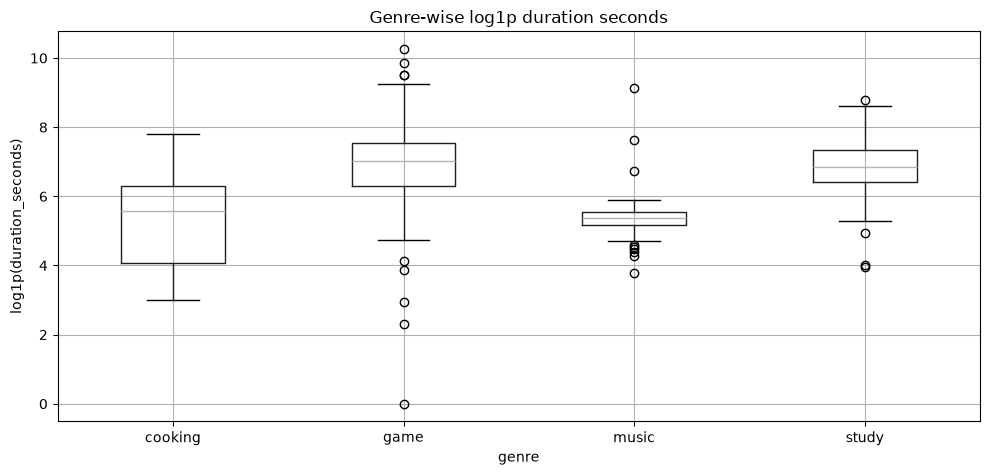

In [1527]:
df_eda.boxplot(
    column="log1p_duration_seconds",
    by="genre",
    figsize=(10, 5),
)

plt.title("Genre-wise log1p duration seconds")
plt.suptitle("")
plt.xlabel("genre")
plt.ylabel("log1p(duration_seconds)")
plt.tight_layout()
plt.show()

In [1528]:
duration_summary.to_csv(
    OUTPUTS_DIR / "duration_summary_by_genre.csv",
    index=False,
    encoding="utf-8-sig",
)

duration_quantile_summary.to_csv(
    OUTPUTS_DIR / "duration_quantile_summary_by_genre.csv",
    index=False,
    encoding="utf-8-sig",
)

long_duration_examples.to_csv(
    OUTPUTS_DIR / "long_duration_examples.csv",
    index=False,
    encoding="utf-8-sig",
)

short_duration_examples.to_csv(
    OUTPUTS_DIR / "short_duration_examples.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "duration_summary_by_genre.csv")
print("saved:", OUTPUTS_DIR / "duration_quantile_summary_by_genre.csv")
print("saved:", OUTPUTS_DIR / "long_duration_examples.csv")
print("saved:", OUTPUTS_DIR / "short_duration_examples.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/duration_summary_by_genre.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/duration_quantile_summary_by_genre.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/long_duration_examples.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/short_duration_examples.csv


## 25. channel_id のジャンルまたぎを確認する

前回は、ジャンル内でのチャンネル偏りを確認した。

ここでは追加で、同じ `channel_id` が複数ジャンルにまたがって出ているかを確認する。

確認する内容は以下。

* 複数ジャンルに出ているチャンネルがあるか
* そのチャンネルの動画タイトル
* ラベルが自然か
* ジャンル境界が曖昧な動画が含まれていないか
* `channel_title` を特徴量に入れるとチャンネル依存になりすぎないか

今回のベースラインでは、`channel_title` は直接使わず、誤分類分析用の確認情報として扱う。

必要に応じて、将来的に `GroupShuffleSplit` や `GroupKFold` も検討する。

In [1529]:
channel_key_cols = ["channel_id"]

if "channel_title" in df_eda.columns:
    channel_key_cols.append("channel_title")

channel_genre_summary = (
    df_eda
    .groupby(channel_key_cols)
    .agg(
        video_count=("video_id", "count"),
        n_genres=("genre", "nunique"),
        genres=("genre", lambda s: ", ".join(sorted(s.unique()))),
    )
    .reset_index()
    .sort_values(["n_genres", "video_count"], ascending=[False, False])
)

print("unique channels:", len(channel_genre_summary))
print("multi-genre channels:", (channel_genre_summary["n_genres"] >= 2).sum())

channel_genre_summary.head(30)

unique channels: 383
multi-genre channels: 0


,channel_id,channel_title,video_count,n_genres,genres
43,UC600H5chBUZ9xYWXH8z-Sxw,テイストメイド ジャパン,4,1,cooking
292,UCmMFrO9hjeAg9RLuTSF4A2A,だれウマ【料理研究家】,4,1,cooking
61,UC95yR8Sk5cmPxd6qfmYYSMw,AKITOの勉強チャンネル,3,1,study
75,UCBevyiJ2ierZY-0yZhfLrmQ,3Blue1BrownJapan,3,1,study
155,UCRNYfIK7BV_DCoR7KqdhBhQ,「ただよび」文系チャンネル,3,1,study
158,UCRcK-UYSCi8uk5SQChka7hA,渡邉究 数学科教員,3,1,study
326,UCqmWJJolqAgjIdLqK3zD1QQ,予備校のノリで学ぶ「大学の数学・物理」,3,1,study
347,UCv8HudXBy1Hyd-R2v1jqTvg,【TOEIC対策】猛牛ちゃんねる,3,1,study
4,UC-_oM0rRXSbpUzxmsJHE69g,電ǂ鯨,2,1,music
13,UC1Lp8HbCqOPBMT1W_mjb21A,kattyanneru/かっちゃんねる,2,1,cooking


In [1530]:
multi_genre_channels = channel_genre_summary[
    channel_genre_summary["n_genres"] >= 2
].copy()

multi_genre_channels

,channel_id,channel_title,video_count,n_genres,genres


In [1531]:
channel_genre_matrix = pd.crosstab(
    df_eda["channel_id"],
    df_eda["genre"],
).reindex(columns=target_genres, fill_value=0)

channel_genre_matrix["total_video_count"] = channel_genre_matrix.sum(axis=1)
channel_genre_matrix["n_genres"] = (
    channel_genre_matrix[target_genres] > 0
).sum(axis=1)
channel_genre_matrix["max_genre"] = channel_genre_matrix[target_genres].idxmax(axis=1)
channel_genre_matrix["max_genre_count"] = channel_genre_matrix[target_genres].max(axis=1)
channel_genre_matrix["max_genre_ratio"] = (
    channel_genre_matrix["max_genre_count"]
    / channel_genre_matrix["total_video_count"]
)

channel_genre_matrix = (
    channel_genre_matrix
    .reset_index()
    .sort_values(["total_video_count", "n_genres"], ascending=[False, False])
)

if "channel_title" in df_eda.columns:
    channel_titles = (
        df_eda[["channel_id", "channel_title"]]
        .drop_duplicates("channel_id")
    )

    channel_genre_matrix = channel_genre_matrix.merge(
        channel_titles,
        on="channel_id",
        how="left",
    )

channel_genre_matrix.head(50)

,channel_id,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio,channel_title
0,UC600H5chBUZ9xYWXH8z-Sxw,0,0,0,4,4,1,cooking,4,1.0,テイストメイド ジャパン
1,UCmMFrO9hjeAg9RLuTSF4A2A,0,0,0,4,4,1,cooking,4,1.0,だれウマ【料理研究家】
2,UC95yR8Sk5cmPxd6qfmYYSMw,0,0,3,0,3,1,study,3,1.0,AKITOの勉強チャンネル
3,UCBevyiJ2ierZY-0yZhfLrmQ,0,0,3,0,3,1,study,3,1.0,3Blue1BrownJapan
4,UCRNYfIK7BV_DCoR7KqdhBhQ,0,0,3,0,3,1,study,3,1.0,「ただよび」文系チャンネル
5,UCRcK-UYSCi8uk5SQChka7hA,0,0,3,0,3,1,study,3,1.0,渡邉究 数学科教員
6,UCqmWJJolqAgjIdLqK3zD1QQ,0,0,3,0,3,1,study,3,1.0,予備校のノリで学ぶ「大学の数学・物理」
7,UCv8HudXBy1Hyd-R2v1jqTvg,0,0,3,0,3,1,study,3,1.0,【TOEIC対策】猛牛ちゃんねる
8,UC-_oM0rRXSbpUzxmsJHE69g,2,0,0,0,2,1,music,2,1.0,電ǂ鯨
9,UC1Lp8HbCqOPBMT1W_mjb21A,0,0,0,2,2,1,cooking,2,1.0,kattyanneru/かっちゃんねる


In [1532]:
genre_channel_summary = (
    df_eda
    .groupby("genre")
    .agg(
        video_count=("video_id", "count"),
        unique_channel_count=("channel_id", "nunique"),
    )
    .reset_index()
)

top_channel_by_genre = (
    df_eda
    .groupby(["genre", "channel_id"])
    .size()
    .reset_index(name="top_channel_video_count")
    .sort_values(["genre", "top_channel_video_count"], ascending=[True, False])
    .groupby("genre")
    .head(1)
)

if "channel_title" in df_eda.columns:
    top_channel_by_genre = top_channel_by_genre.merge(
        df_eda[["channel_id", "channel_title"]].drop_duplicates("channel_id"),
        on="channel_id",
        how="left",
    )

genre_channel_summary = genre_channel_summary.merge(
    top_channel_by_genre,
    on="genre",
    how="left",
)

genre_channel_summary["top_channel_video_rate"] = (
    genre_channel_summary["top_channel_video_count"]
    / genre_channel_summary["video_count"]
    * 100
)

genre_channel_summary.round(2)

,genre,video_count,unique_channel_count,channel_id,top_channel_video_count,channel_title,top_channel_video_rate
0,cooking,102,83,UC600H5chBUZ9xYWXH8z-Sxw,4,テイストメイド ジャパン,3.92
1,game,107,98,UCG_CzdeNlcDnBCK8AbgiuVw,2,カナメとハルキー,1.87
2,music,123,114,UC-_oM0rRXSbpUzxmsJHE69g,2,電ǂ鯨,1.63
3,study,111,88,UC95yR8Sk5cmPxd6qfmYYSMw,3,AKITOの勉強チャンネル,2.70


In [1533]:
channel_cols = ["genre", "channel_id"]

if "channel_title" in df_eda.columns:
    channel_cols.append("channel_title")

top_channels_by_genre = (
    df_eda
    .groupby(channel_cols)
    .size()
    .reset_index(name="video_count")
    .sort_values(["genre", "video_count"], ascending=[True, False])
    .groupby("genre")
    .head(10)
)

top_channels_by_genre

,genre,channel_id,channel_title,video_count
8,cooking,UC600H5chBUZ9xYWXH8z-Sxw,テイストメイド ジャパン,4
65,cooking,UCmMFrO9hjeAg9RLuTSF4A2A,だれウマ【料理研究家】,4
3,cooking,UC1Lp8HbCqOPBMT1W_mjb21A,kattyanneru/かっちゃんねる,2
4,cooking,UC2p9pSIMYa-asF6C38039gQ,ビデリシャス - おいしい動画 -,2
15,cooking,UCC8bTxyN2ZCfMzS_JAEClfA,쿠킹하루 Cooking Haru :),2
19,cooking,UCFstoZogjPSvpaGQamdYEcw,せこまる食堂,2
26,cooking,UCIoTgYjd_F9cD3gxgE7Lk8A,おすぎ(管理栄養士),2
33,cooking,UCP2gnyy_-ToZeIDw6qeI6HA,George ジョージ吉田,2
35,cooking,UCPL_LYCwWbzW6f3s9qAE7fw,ぴーきちごはん,2
43,cooking,UCW01sMEVYQdhcvkrhbxdBpw,料理研究家リュウジのバズレシピ,2


In [1534]:
dominant_channels = channel_genre_matrix[
    channel_genre_matrix["total_video_count"] >= 3
].copy()

dominant_channels.head(50)

,channel_id,music,game,study,cooking,total_video_count,n_genres,max_genre,max_genre_count,max_genre_ratio,channel_title
0,UC600H5chBUZ9xYWXH8z-Sxw,0,0,0,4,4,1,cooking,4,1.0,テイストメイド ジャパン
1,UCmMFrO9hjeAg9RLuTSF4A2A,0,0,0,4,4,1,cooking,4,1.0,だれウマ【料理研究家】
2,UC95yR8Sk5cmPxd6qfmYYSMw,0,0,3,0,3,1,study,3,1.0,AKITOの勉強チャンネル
3,UCBevyiJ2ierZY-0yZhfLrmQ,0,0,3,0,3,1,study,3,1.0,3Blue1BrownJapan
4,UCRNYfIK7BV_DCoR7KqdhBhQ,0,0,3,0,3,1,study,3,1.0,「ただよび」文系チャンネル
5,UCRcK-UYSCi8uk5SQChka7hA,0,0,3,0,3,1,study,3,1.0,渡邉究 数学科教員
6,UCqmWJJolqAgjIdLqK3zD1QQ,0,0,3,0,3,1,study,3,1.0,予備校のノリで学ぶ「大学の数学・物理」
7,UCv8HudXBy1Hyd-R2v1jqTvg,0,0,3,0,3,1,study,3,1.0,【TOEIC対策】猛牛ちゃんねる


In [1535]:
channel_genre_summary.to_csv(
    OUTPUTS_DIR / "channel_genre_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

multi_genre_channels.to_csv(
    OUTPUTS_DIR / "multi_genre_channels.csv",
    index=False,
    encoding="utf-8-sig",
)

channel_genre_matrix.to_csv(
    OUTPUTS_DIR / "channel_genre_matrix.csv",
    index=False,
    encoding="utf-8-sig",
)

genre_channel_summary.to_csv(
    OUTPUTS_DIR / "genre_channel_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

top_channels_by_genre.to_csv(
    OUTPUTS_DIR / "top_channels_by_genre.csv",
    index=False,
    encoding="utf-8-sig",
)

dominant_channels.to_csv(
    OUTPUTS_DIR / "dominant_channels.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "channel_genre_summary.csv")
print("saved:", OUTPUTS_DIR / "multi_genre_channels.csv")
print("saved:", OUTPUTS_DIR / "channel_genre_matrix.csv")
print("saved:", OUTPUTS_DIR / "genre_channel_summary.csv")
print("saved:", OUTPUTS_DIR / "top_channels_by_genre.csv")
print("saved:", OUTPUTS_DIR / "dominant_channels.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/channel_genre_summary.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/multi_genre_channels.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/channel_genre_matrix.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/genre_channel_summary.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/top_channels_by_genre.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/dominant_channels.csv


## 26. ドメイン・ハッシュタグ・API tags を別特徴として扱う方針を整理する

ここまでのEDA結果を踏まえ、分類実験で使う入力特徴の方針を整理する。

本文特徴については、rawな `text_base` をベースラインとして残しつつ、URL・ハッシュタグ・区切り線を除去した `cleaned_text_no_separators` を本文特徴の有力候補とする。

一方、ハッシュタグ・ドメイン・YouTube API tags は、本文中に混ぜたままにするとURL断片やタグ断片としてTF-IDF特徴に入りやすい。そのため、本文からは除去し、必要に応じて `HASHTAG_xxx`、`DOMAIN_xxx`、`API_TAG_xxx` のような別特徴として追加する。

また、タイトルは概要欄よりジャンル情報が濃い可能性があるため、分類実験では `title_repeat` を設定し、タイトルの重みを変えた場合も比較する。

duration はジャンル差が見られたが、収集時の偏りを反映している可能性があるため、最初の分類実験では主特徴にせず、必要に応じて補助特徴として検討する。

channel_id / channel_title は投稿者を直接覚える特徴になりやすいため、分類特徴としては使わない。


In [1536]:
model_input_config = {
    "text_col": "cleaned_text_no_separators",
    "title_col": "cleaned_title_no_separators",
    "title_repeat": 2,

    "use_hashtags": True,
    "use_domains": True,
    "use_api_tags": True,

    "hashtag_min_video_count": 2,
    "domain_min_video_count": 2,
    "api_tag_min_video_count": 2,
}

model_input_config

{'text_col': 'cleaned_text_no_separators',
 'title_col': 'cleaned_title_no_separators',
 'title_repeat': 2,
 'use_hashtags': True,
 'use_domains': True,
 'use_api_tags': True,
 'hashtag_min_video_count': 2,
 'domain_min_video_count': 2,
 'api_tag_min_video_count': 2}

In [1537]:
METADATA_MIN_VIDEO_COUNT_GRID = [2, 3, 4, 5]

metadata_cutoff_grid_config = {
    "hashtag_min_video_count": METADATA_MIN_VIDEO_COUNT_GRID,
    "domain_min_video_count": METADATA_MIN_VIDEO_COUNT_GRID,
    "api_tag_min_video_count": METADATA_MIN_VIDEO_COUNT_GRID,
}

metadata_cutoff_grid_config

{'hashtag_min_video_count': [2, 3, 4, 5],
 'domain_min_video_count': [2, 3, 4, 5],
 'api_tag_min_video_count': [2, 3, 4, 5]}

In [1538]:
model_input_parameter_notes = pd.DataFrame(
    [
        {
            "parameter": "text_col",
            "value": model_input_config["text_col"],
            "meaning": "本文特徴として使うテキスト列",
        },
        {
            "parameter": "title_col",
            "value": model_input_config["title_col"],
            "meaning": "タイトル重み付けに使うタイトル列",
        },
        {
            "parameter": "title_repeat",
            "value": model_input_config["title_repeat"],
            "meaning": "タイトルを合計何回分として扱うか。text_colに既に含まれる1回分を含む",
        },
        {
            "parameter": "use_hashtags",
            "value": model_input_config["use_hashtags"],
            "meaning": "ハッシュタグを別特徴として使うか",
        },
        {
            "parameter": "use_domains",
            "value": model_input_config["use_domains"],
            "meaning": "URLドメインを別特徴として使うか",
        },
        {
            "parameter": "use_api_tags",
            "value": model_input_config["use_api_tags"],
            "meaning": "YouTube API tags を別特徴として使うか",
        },
        {
            "parameter": "hashtag_min_video_count",
            "value": model_input_config["hashtag_min_video_count"],
            "meaning": "特徴として採用するハッシュタグの最低出現動画数",
        },
        {
            "parameter": "domain_min_video_count",
            "value": model_input_config["domain_min_video_count"],
            "meaning": "特徴として採用するドメインの最低出現動画数",
        },
        {
            "parameter": "api_tag_min_video_count",
            "value": model_input_config["api_tag_min_video_count"],
            "meaning": "特徴として採用するAPI tagの最低出現動画数",
        },
    ]
)

model_input_parameter_notes

,parameter,value,meaning
0,text_col,cleaned_text_no_separators,本文特徴として使うテキスト列
1,title_col,cleaned_title_no_separators,タイトル重み付けに使うタイトル列
2,title_repeat,2,タイトルを合計何回分として扱うか。text_colに既に含まれる1回分を含む
3,use_hashtags,True,ハッシュタグを別特徴として使うか
4,use_domains,True,URLドメインを別特徴として使うか
5,use_api_tags,True,YouTube API tags を別特徴として使うか
6,hashtag_min_video_count,2,特徴として採用するハッシュタグの最低出現動画数
7,domain_min_video_count,2,特徴として採用するドメインの最低出現動画数
8,api_tag_min_video_count,2,特徴として採用するAPI tagの最低出現動画数


In [1539]:
model_experiment_plan = pd.DataFrame(
    [
        {
            "experiment_id": "A",
            "text_col": "text_base",
            "title_col": "title",
            "title_repeat": 1,
            "use_hashtags": False,
            "use_domains": False,
            "use_api_tags": False,
            "hashtag_min_video_count": None,
            "domain_min_video_count": None,
            "api_tag_min_video_count": None,
            "purpose": "raw baseline",
            "priority": 1,
        },
        {
            "experiment_id": "B",
            "text_col": "cleaned_text_no_separators",
            "title_col": "cleaned_title_no_separators",
            "title_repeat": 1,
            "use_hashtags": False,
            "use_domains": False,
            "use_api_tags": False,
            "hashtag_min_video_count": None,
            "domain_min_video_count": None,
            "api_tag_min_video_count": None,
            "purpose": "cleaned text baseline",
            "priority": 2,
        },
        {
            "experiment_id": "C",
            "text_col": "cleaned_text_no_separators",
            "title_col": "cleaned_title_no_separators",
            "title_repeat": 2,
            "use_hashtags": False,
            "use_domains": False,
            "use_api_tags": False,
            "hashtag_min_video_count": None,
            "domain_min_video_count": None,
            "api_tag_min_video_count": None,
            "purpose": "タイトル重み付けの効果を見る",
            "priority": 3,
        },
        {
            "experiment_id": "D",
            "text_col": "cleaned_text_no_separators",
            "title_col": "cleaned_title_no_separators",
            "title_repeat": 2,
            "use_hashtags": True,
            "use_domains": False,
            "use_api_tags": False,
            "hashtag_min_video_count": 2,
            "domain_min_video_count": None,
            "api_tag_min_video_count": None,
            "purpose": "ハッシュタグを別特徴として追加する効果を見る",
            "priority": 4,
        },
        {
            "experiment_id": "E",
            "text_col": "cleaned_text_no_separators",
            "title_col": "cleaned_title_no_separators",
            "title_repeat": 2,
            "use_hashtags": False,
            "use_domains": True,
            "use_api_tags": False,
            "hashtag_min_video_count": None,
            "domain_min_video_count": 2,
            "api_tag_min_video_count": None,
            "purpose": "ドメインを別特徴として追加する効果を見る",
            "priority": 5,
        },
        {
            "experiment_id": "F",
            "text_col": "cleaned_text_no_separators",
            "title_col": "cleaned_title_no_separators",
            "title_repeat": 2,
            "use_hashtags": False,
            "use_domains": False,
            "use_api_tags": True,
            "hashtag_min_video_count": None,
            "domain_min_video_count": None,
            "api_tag_min_video_count": 2,
            "purpose": "API tags を別特徴として追加する効果を見る",
            "priority": 6,
        },
        {
            "experiment_id": "G",
            "text_col": "cleaned_text_no_separators",
            "title_col": "cleaned_title_no_separators",
            "title_repeat": 2,
            "use_hashtags": True,
            "use_domains": True,
            "use_api_tags": True,
            "hashtag_min_video_count": 2,
            "domain_min_video_count": 2,
            "api_tag_min_video_count": 2,
            "purpose": "タイトル重み付けとメタデータ特徴をまとめて使う",
            "priority": 7,
        },
    ]
)

model_experiment_plan

,experiment_id,text_col,title_col,title_repeat,use_hashtags,use_domains,use_api_tags,hashtag_min_video_count,domain_min_video_count,api_tag_min_video_count,purpose,priority
0,A,text_base,title,1,False,False,False,NaN,NaN,NaN,raw baseline,1
1,B,cleaned_text_no_separators,cleaned_title_no_separators,1,False,False,False,NaN,NaN,NaN,cleaned text baseline,2
2,C,cleaned_text_no_separators,cleaned_title_no_separators,2,False,False,False,NaN,NaN,NaN,タイトル重み付けの効果を見る,3
3,D,cleaned_text_no_separators,cleaned_title_no_separators,2,True,False,False,2.0,NaN,NaN,ハッシュタグを別特徴として追加する効果を見る,4
4,E,cleaned_text_no_separators,cleaned_title_no_separators,2,False,True,False,NaN,2.0,NaN,ドメインを別特徴として追加する効果を見る,5
5,F,cleaned_text_no_separators,cleaned_title_no_separators,2,False,False,True,NaN,NaN,2.0,API tags を別特徴として追加する効果を見る,6
6,G,cleaned_text_no_separators,cleaned_title_no_separators,2,True,True,True,2.0,2.0,2.0,タイトル重み付けとメタデータ特徴をまとめて使う,7


In [1540]:
from itertools import product

metadata_cutoff_grid_plan = pd.DataFrame(
    [
        {
            "experiment_stage": "classification_experiment_2",
            "text_col": "cleaned_text_no_separators",
            "title_col": "cleaned_title_no_separators",
            "title_repeat": 2,
            "use_hashtags": True,
            "use_domains": True,
            "use_api_tags": True,
            "hashtag_min_video_count": hashtag_min_video_count,
            "domain_min_video_count": domain_min_video_count,
            "api_tag_min_video_count": api_tag_min_video_count,
        }
        for hashtag_min_video_count, domain_min_video_count, api_tag_min_video_count
        in product(
            metadata_cutoff_grid_config["hashtag_min_video_count"],
            metadata_cutoff_grid_config["domain_min_video_count"],
            metadata_cutoff_grid_config["api_tag_min_video_count"],
        )
    ]
)

metadata_cutoff_grid_plan.insert(
    0,
    "grid_experiment_id",
    [
        f"GRID_{i:03d}"
        for i in range(1, len(metadata_cutoff_grid_plan) + 1)
    ],
)

metadata_cutoff_grid_plan.head()

,grid_experiment_id,experiment_stage,text_col,title_col,title_repeat,use_hashtags,use_domains,use_api_tags,hashtag_min_video_count,domain_min_video_count,api_tag_min_video_count
0,GRID_001,classification_experiment_2,cleaned_text_no_separators,cleaned_title_no_separators,2,True,True,True,2,2,2
1,GRID_002,classification_experiment_2,cleaned_text_no_separators,cleaned_title_no_separators,2,True,True,True,2,2,3
2,GRID_003,classification_experiment_2,cleaned_text_no_separators,cleaned_title_no_separators,2,True,True,True,2,2,4
3,GRID_004,classification_experiment_2,cleaned_text_no_separators,cleaned_title_no_separators,2,True,True,True,2,2,5
4,GRID_005,classification_experiment_2,cleaned_text_no_separators,cleaned_title_no_separators,2,True,True,True,2,3,2


In [1541]:
print("grid size:", len(metadata_cutoff_grid_plan))

grid size: 64


In [1542]:
feature_policy = pd.DataFrame(
    [
        {
            "feature_group": "text_base",
            "use_as_feature": True,
            "feature_type": "text",
            "representation": "char n-gram TF-IDF",
            "policy": "raw baseline として使う",
        },
        {
            "feature_group": "cleaned_text_no_separators",
            "use_as_feature": True,
            "feature_type": "text",
            "representation": "char n-gram TF-IDF",
            "policy": "本文特徴の本命候補として使う",
        },
        {
            "feature_group": "title",
            "use_as_feature": True,
            "feature_type": "text weight",
            "representation": "title_repeat",
            "policy": "title_repeat でタイトルの重み付けを比較する",
        },
        {
            "feature_group": "hashtags",
            "use_as_feature": True,
            "feature_type": "metadata token",
            "representation": "HASHTAG_xxx",
            "policy": "本文からは除去し、別特徴として追加する",
        },
        {
            "feature_group": "domains",
            "use_as_feature": True,
            "feature_type": "metadata token",
            "representation": "DOMAIN_xxx",
            "policy": "URL全文ではなくドメイン単位で別特徴として追加する",
        },
        {
            "feature_group": "api_tags",
            "use_as_feature": True,
            "feature_type": "metadata token",
            "representation": "API_TAG_xxx",
            "policy": "YouTube API tags を別特徴として追加する",
        },
        {
            "feature_group": "duration",
            "use_as_feature": False,
            "feature_type": "numeric",
            "representation": "log1p_duration_seconds / is_short_like",
            "policy": "収集偏りの可能性があるため、最初の分類実験では使わない",
        },
        {
            "feature_group": "channel_id",
            "use_as_feature": False,
            "feature_type": "id",
            "representation": "not used",
            "policy": "投稿者記憶を避けるため分類特徴としては使わない",
        },
        {
            "feature_group": "channel_title",
            "use_as_feature": False,
            "feature_type": "text",
            "representation": "not used",
            "policy": "投稿者記憶を避けるため分類特徴としては使わない",
        },
    ]
)

feature_policy

,feature_group,use_as_feature,feature_type,representation,policy
0,text_base,True,text,char n-gram TF-IDF,raw baseline として使う
1,cleaned_text_no_separators,True,text,char n-gram TF-IDF,本文特徴の本命候補として使う
2,title,True,text weight,title_repeat,title_repeat でタイトルの重み付けを比較する
3,hashtags,True,metadata token,HASHTAG_xxx,本文からは除去し、別特徴として追加する
4,domains,True,metadata token,DOMAIN_xxx,URL全文ではなくドメイン単位で別特徴として追加する
5,api_tags,True,metadata token,API_TAG_xxx,YouTube API tags を別特徴として追加する
6,duration,False,numeric,log1p_duration_seconds / is_short_like,収集偏りの可能性があるため、最初の分類実験では使わない
7,channel_id,False,id,not used,投稿者記憶を避けるため分類特徴としては使わない
8,channel_title,False,text,not used,投稿者記憶を避けるため分類特徴としては使わない


In [1543]:
model_input_parameter_notes.to_csv(
    OUTPUTS_DIR / "model_input_parameter_notes.csv",
    index=False,
    encoding="utf-8-sig",
)

model_experiment_plan.to_csv(
    OUTPUTS_DIR / "model_experiment_plan.csv",
    index=False,
    encoding="utf-8-sig",
)

feature_policy.to_csv(
    OUTPUTS_DIR / "feature_policy.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "model_input_parameter_notes.csv")
print("saved:", OUTPUTS_DIR / "model_experiment_plan.csv")
print("saved:", OUTPUTS_DIR / "feature_policy.csv")

metadata_cutoff_grid_plan.to_csv(
    OUTPUTS_DIR / "metadata_cutoff_grid_plan.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUTS_DIR / "metadata_cutoff_grid_plan.csv")

saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/model_input_parameter_notes.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/model_experiment_plan.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/feature_policy.csv
saved: /Users/nishiyamaharuya/Documents/coding/youtube_analyzer/youtube-playlist-classifier-poc/data/analysis/eda/metadata_cutoff_grid_plan.csv


## 26 のまとめ

分類実験1では、まず raw な text_base をベースラインとして使う。
そのうえで、URL・ハッシュタグ・区切り線を除去した cleaned_text_no_separators を本文特徴の本命候補として比較する。

ハッシュタグ・ドメイン・API tags は本文からは除去し、別トークンとして追加する。
各メタデータ特徴はロングテールになりやすいため、出現動画数による足切りを行う。
現時点では hashtag_min_video_count / domain_min_video_count / api_tag_min_video_count は 2 を本命候補とする。

タイトルは概要欄よりジャンル情報が濃い可能性があるため、title_repeat によって重み付けを比較する。
最初は title_repeat = 1 と title_repeat = 2 を比較する。

duration は補助特徴候補だが、収集偏りの影響を受ける可能性があるため、最初の分類実験では使わない。
channel_id / channel_title は投稿者記憶につながるため、分類特徴としては使わない。


分類実験2では、メタデータ特徴を使う設定に絞り、hashtag_min_video_count / domain_min_video_count / api_tag_min_video_count を [2, 3, 4, 5] のグリッドで比較する。
これにより、ロングテールなメタデータ特徴をどこまで採用するのがよいかを確認する。
足切り量の最適化は、最終評価データに対する過学習を避けるため、原則として train データ内の交差検証で行う。

## 27. 追加EDAのまとめ

今回の追加EDAでは、分類実験に入る前に、URL・ハッシュタグ・ドメイン・YouTube API tags・duration・channel_id などの補助情報をどのように扱うべきか確認した。

対象データは、学習対象として扱う `music`、`game`、`study`、`cooking` の4ジャンル、合計443本である。`other_candidates` は今回の分類実験対象からは外す。

### ハッシュタグ

ハッシュタグは、動画単位で重複除去して再集計した。

重複除去後のハッシュタグ出現数は1015件、ユニークハッシュタグ数は829件だった。ジャンルごとに見ると、cooking はハッシュタグ付き動画の割合が高く、`#簡単レシピ`、`#料理`、`#作り置き`、`#時短レシピ` など、ジャンルに直結しやすいハッシュタグが見られた。game では `#マイクラ`、`#ゲーム実況`、music では `#vocaloid`、`#初音ミク`、`#歌ってみた`、study では `#toeic`、`#大学受験`、`#python`、`#数学` などが見られた。

一方で、`#shorts` のようにジャンルそのものではなく動画形式を表すハッシュタグも存在した。そのため、ハッシュタグを手作業でジャンル固有・共有・ノイズに分けるのではなく、分類モデル上では確率的な特徴として扱う方針とする。

ハッシュタグはロングテールが強く、出現動画数による足切りが必要である。`min_video_count >= 2` では104個、`>= 3` では31個、`>= 5` では8個まで減少した。`>= 5` では `#マイクラ`、`#歌ってみた`、`#数学`、`#python` などの有用そうなタグも落ちるため、分類実験ではまず `min_video_count = 2` を本命候補とし、必要に応じて `3` 以上も比較する。

### URL・ドメイン

URLは本文に含めたままだと、URL断片やドメイン断片が char n-gram TF-IDF の上位特徴に入りやすい。

そのため、本文特徴からはURL全文を除去する。一方で、ドメインにはジャンル傾向が含まれる可能性があるため、URL全文ではなくドメイン単位で `DOMAIN_xxx` のような別特徴として扱う方針とする。

同一動画内で同じドメインが複数回出る場合でも、分類特徴としては動画単位で重複除去して使う。

### cleaned text

`text_base` には、タイトル・概要欄・URL・ハッシュタグ・区切り線・定型文が混在している。raw な `text_base` はベースラインとして残すが、特徴語確認ではURL断片・ハッシュタグ断片・区切り線由来の記号列が上位に出やすかった。

そこで、URLとハッシュタグを除去した `cleaned_text`、さらに区切り線のような記号列も除去した `cleaned_text_no_separators` を作成した。

TF-IDF特徴語を比較した結果、`cleaned_text_no_separators` では、区切り線や記号列の影響が弱まり、ジャンルに関係しそうな語が見やすくなった。そのため、本文特徴の本命候補は `cleaned_text_no_separators` とする。

ただし、rawな `text_base` で得られる情報もあるため、分類実験では `text_base`、`cleaned_text_no_separators` の両方を比較する。

### YouTube API tags

YouTube API の `tags` は、ハッシュタグとは別に投稿者がメタデータとして付けるタグである。

API tags は316 / 443本の動画に付いており、全体で4076件、ユニーク3004件だった。付与率は各ジャンルでおおむね7割前後であり、特定ジャンルだけ極端に欠けているわけではなかった。

内容を確認すると、cooking では `料理`、`レシピ`、`作り方`、game では `ゲーム`、`実況`、`攻略`、music では `vocaloid`、`ボカロ`、`歌ってみた`、study では `数学`、`受験`、`勉強`、`toeic` など、分類に有用そうな語が多く含まれていた。

一方で、API tags もロングテールが強い。`min_video_count >= 2` では495個、`>= 3` では171個まで減少する。そのため、分類実験ではまず `api_tag_min_video_count = 2` を本命候補とし、分類実験2で `2, 3, 4, 5` のグリッド探索を行う候補とする。

API tags は本文に混ぜるのではなく、`API_TAG_xxx` のような別特徴として扱う。

### duration

duration を秒に変換し、ジャンル別に確認した。

ジャンルごとに動画時間の傾向差は見られた。特に cooking では `short_like_rate` が高く、60秒以下の短尺動画が多く含まれていた。ただし、これは今回のデータ収集時に短尺レシピ動画を多く含めたことによる偏りの可能性がある。

そのため、duration はジャンルの本質を表す主特徴としては扱わず、必要に応じて `log1p_duration_seconds` や `is_short_like` を補助特徴として追加比較する程度に留める。最初の分類実験では duration は使わない。

また、0秒の動画は通常の短尺動画ではなく、API上の特殊値や取得データ上の例外である可能性があるため、`is_short_like` とは分けて扱う。

### channel_id / channel_title

channel_id は、投稿者を直接覚える特徴になりやすいため、分類特徴としては使わない方針とする。

今回のデータでは、443本に対してユニークチャンネル数は383件であり、チャンネルは十分に分散していた。また、複数ジャンルにまたがるチャンネルは0件だった。

各ジャンルの最多チャンネルでも2〜4本程度であり、特定チャンネルへの極端な集中は見られなかった。したがって、今回のPoCでは通常の stratified split で分類実験に進んでよい。

ただし、より厳密な評価を行う場合は、同一チャンネルの動画が train/test にまたがらないような分割も検討する。

### 分類実験に引き継ぐ方針

分類実験では、まず以下の特徴を比較する。

* raw な `text_base`
* `cleaned_text_no_separators`
* `cleaned_text_no_separators` にタイトル重み付けを加えたもの
* ハッシュタグを別特徴として追加したもの
* ドメインを別特徴として追加したもの
* API tags を別特徴として追加したもの
* ハッシュタグ・ドメイン・API tags をまとめて追加したもの

タイトルは概要欄よりジャンル情報が濃い可能性があるため、`title_repeat` を使って重み付けを比較する。まずは `title_repeat = 1` と `title_repeat = 2` を比較する。

分類実験1では、メタデータ特徴の足切り量はまず以下を本命設定とする。

```python
hashtag_min_video_count = 2
domain_min_video_count = 2
api_tag_min_video_count = 2
```

分類実験2では、メタデータ特徴を使う設定に絞り、以下のグリッドで足切り量を比較する。

```python
hashtag_min_video_count in [2, 3, 4, 5]
domain_min_video_count in [2, 3, 4, 5]
api_tag_min_video_count in [2, 3, 4, 5]
```

これにより、ロングテールなメタデータ特徴をどこまで採用するのがよいかを確認する。

ただし、足切り量の最適化を最終評価データで行うと評価が楽観的になる可能性がある。そのため、可能であれば train データ内の交差検証で足切り量を選び、最後に固定した設定で test データを評価する。

### 次に行うこと

次は `04_model_baseline.ipynb` を作成し、TF-IDF + Logistic Regression による分類実験を行う。

最初は4ジャンル分類として、`music`、`game`、`study`、`cooking` を対象にする。評価では accuracy だけでなく、classification report、confusion matrix、誤分類例、ジャンルごとの上位係数を確認する。

特に、cleaned text によって分類性能や特徴語の解釈性が改善するか、ハッシュタグ・ドメイン・API tags を別特徴として追加したときに性能が上がるかを確認する。
